<a href="https://colab.research.google.com/github/lauracamilavargas-lang/predictive-maintenance-medical-imaging/blob/main/Modelo_para_protocolo_predictivo_TG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Modelo de Mantenimiento Predictivo — Equipos biomédicos con principios de funcionamiento basado en radiación ionizantes en el hospital universitario fundación valle del lili.


# Bloque 1 — Pre-procesamiento de datos
El pre-procesamiento transforma el archivo Excel del hospital en un dataset limpio y estructurado, listo para el entrenamiento del modelo. El dataset de entrada corresponde a órdenes de mantenimiento correctivo registradas entre 2020 y 2025 para siete tipos de equipos de imagenología: RX Fijo, RX Móvil, Arco C, TAC, Mamografía, Fluoroscopía y Angiografía.

El bloque ejecuta ocho pasos secuenciales: carga y consolidación del archivo Excel; estandarización de los nombres de columnas; limpieza del contenido de las variables de texto y corrección de errores tipográficos en sistemas y componentes; conversión de fechas y tratamiento de las horas de parada; construcción del índice de criticidad por combinación tipo de equipo × sistema (escala 1–5) y de su versión temporal past-only, que es la que entra al modelo; generación de las variables temporales por equipo (TBF, fallos en 30 y 90 días, horas de parada acumuladas, edad); cálculo de las features derivadas (TBF promedio histórico, tendencia del TBF, tasa de fallo y TBF anterior); y filtrado final para obtener df_modelo con los 1199 registros válidos.

La construcción del target periodo_fallo se realiza en el Bloque 2, una vez caracterizada la distribución del TBF que fundamenta el umbral de 30 días.inal para obtener df_modelo con los registros válidos para entrenamiento.

0.   Se carga el archivo Excel con la data tratada del hospital desde el computador local a Colab y se verifica que llegó correctamente mostrando sus dimensiones y nombres de columnas originales.

In [1]:
# ──────────────────── CARGA DEL ARCHIVO ────────────────────────
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise ValueError("No se subió ningún archivo. Vuelve a ejecutar la celda.")

nombre_archivo = list(uploaded.keys())[0]

if not nombre_archivo.endswith((".xlsx", ".xls")):
    raise ValueError(f"El archivo '{nombre_archivo}' no es un Excel válido.")

df = pd.read_excel(nombre_archivo)

if "TIPO DE EQUIPO" not in df.columns:
    raise ValueError("El archivo no contiene la columna 'TIPO DE EQUIPO'.")

# ── Resultados ─────────────────────────────────────────────────
print(f"Archivo        : {nombre_archivo}")
print(f"Shape          : {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Columnas       : {df.columns.tolist()}")
print(f"Tipos de equipo: {sorted(df['TIPO DE EQUIPO'].dropna().unique().tolist())}")
print(f"Nulos por col  :\n{df.isnull().sum()[df.isnull().sum() > 0].to_string()}")

Saving ANGIO,FLURO,FIJO,MOVIL,MAMO,ARCO, TC.xlsx to ANGIO,FLURO,FIJO,MOVIL,MAMO,ARCO, TC.xlsx
Archivo        : ANGIO,FLURO,FIJO,MOVIL,MAMO,ARCO, TC.xlsx
Shape          : 1230 filas × 23 columnas
Columnas       : ['ID', 'EQUIPO', 'ORDEN', 'TIPO DE EQUIPO', 'PARADA', 'Texto código motivo ', 'Horas de parada', 'fuera de servicio/gestion de la orden', 'Sistema en el que ocurrió la falla', 'Subsistema en el que ocurrió la falla', 'Componente que falló', 'componente que se cambio', 'solucion', 'tipo de solucion', 'Fecha puesta en marcha', 'Fecha falla', 'Motivo TBF', 'Cuenta con UPS', 'Preventivo', 'Sede', 'Ubicacion', 'Marca', 'Modelo']
Tipos de equipo: ['Sis Exploración Tomografía Computarizada', 'Sist Radiográf/Fluorosc Para Angiografía', 'Sistema radiográfico/fluoroscópico', 'Unidad Radiográfica Digital', 'Unidad Radiográfica Mamográfica', 'Unidad Radiográfica Móvil', 'Unidad Radiográfica/Fluoroscópica Móvil']
Nulos por col  :
PARADA                                   1109
Texto código mo

1. Celda encargada exclusivamente de declarar los parámetros de configuración del pipeline nombres estandarizados, definición de los targets, listas de variables de entrada de cada modelo e hiperparámetros de entrenamiento en un único lugar. Centralizarlos evita duplicar definiciones a lo largo del notebook y garantiza que cualquier ajuste (una variable de entrada, un hiperparámetro) se realice en un solo punto y se propague de forma consistente a todas las celdas que los consumen. Los hiperparámetros del Modelo A se declaran aquí como configuración vigente; el procedimiento por el cual se verificaron se documenta en la Celda 17C.

In [2]:
# Modelo A: configuración verificada por búsqueda aleatoria (Celda 17C).
# Regularización reforzada frente a la base para limitar el sobreajuste.

NOMBRES_CORTOS = {
    "Sis Exploración Tomografía Computarizada" : "TAC",
    "Sistema radiográfico/fluoroscópico"        : "Fluoro",
    "Unidad Radiográfica Digital"               : "RX Fijo",
    "Unidad Radiográfica Mamográfica"           : "Mamografía",
    "Unidad Radiográfica Móvil"                 : "RX Móvil",
    "Unidad Radiográfica/Fluoroscópica Móvil"   : "Arco C",
    "Sist Radiográf/Fluorosc Para Angiografía"  : "Angiografía",
}

# ── Target ─────────────────────────────────────────────────────
TARGET_PERIODO = "periodo_fallo"

MAPA_PERIODO = {"Requiere acción": 0, "Estable": 1}
clases_a     = ["Requiere acción", "Estable"]
COLORES_A    = ["#E24B4A", "#1D9E75"]

# ── Features Modelo A ──────────────────────────────────────────
# criticidad_temporal: índice de severidad past-only (ventana expansiva
# anual, ver Celda 5C). Reemplaza a la criticidad global en el modelo para
# evitar fuga temporal entre años. La criticidad global se conserva solo
# como variable descriptiva y de priorización.
FEATURES_A = [
    "tbf_dias",
    "fallos_30_dias",
    "tbf_promedio_equipo",
    "tendencia_tbf",
    "criticidad_temporal",
    "edad_dias",
    "horas_parada_acumuladas",
    "fallos_90_dias",
    "tasa_fallo_equipo",
    "tbf_anterior",
    "tipo_equipo",
]
FEATURES_A_CAT = ["tipo_equipo"]

NOMBRES_A = {
    "tbf_dias"                : "TBF actual",
    "fallos_30_dias"          : "Fallos 30 días",
    "tbf_promedio_equipo"     : "TBF promedio equipo",
    "tendencia_tbf"           : "Tendencia TBF",
    "criticidad_temporal"     : "Criticidad (temporal)",
    "edad_dias"               : "Edad (días)",
    "horas_parada_acumuladas" : "Horas parada acum.",
    "fallos_90_dias"          : "Fallos 90 días",
    "tasa_fallo_equipo"       : "Tasa fallo equipo",
    "tbf_anterior"            : "TBF anterior",
    "tipo_equipo"             : "Tipo equipo",
}

# ── Hiperparámetros XGBoost ────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
)

# Modelo A: ajustados por búsqueda aleatoria (25 iter, semilla 42).
# Se apartan de la base para reducir el sobreajuste (gap 0.10 -> 0.03).
XGB_PARAMS_A = {
    **XGB_PARAMS,
    "eval_metric":   "logloss",
    "max_depth":     2,
    "learning_rate": 0.03,
    "n_estimators":  150,
    "reg_lambda":    1.0,
}

print("Configuración global cargada")
print(f"  FEATURES_A: {len(FEATURES_A)} ({len(FEATURES_A_CAT)} categórica)")


Configuración global cargada
  FEATURES_A: 11 (1 categórica)


2.   Se normalizan todos los nombres de columnas eliminando tildes, espacios, barras y mayúsculas. Los nombres más largos se acortan a versiones manejables.



In [3]:
# ── CELDA 2 — ESTANDARIZAR NOMBRES DE COLUMNAS ────────────────
import unicodedata

def _sin_tildes(s):
    return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .map(_sin_tildes)                      # quita todas las tildes de una vez
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("_+", "_", regex=True)    # colapsa guiones bajos repetidos
    .str.strip("_")
)

df = df.rename(columns={
    "tipo_de_equipo"                       : "tipo_equipo",
    "sistema_en_el_que_ocurrio_la_falla"   : "sistema_general",
    "subsistema_en_el_que_ocurrio_la_falla": "subsistema",
    "componente_que_fallo"                 : "componente",
    "componente_que_se_cambio"             : "componente_cambiado",
    "texto_codigo_motivo"                  : "tipo_falla",
    "tipo_de_solucion"                     : "tipo_solucion",
    "fuera_de_servicio_gestion_de_la_orden": "fuera_de_servicio",
    "horas_de_parada"                      : "horas_de_parada_num",
})

print(f"Columnas finales ({len(df.columns)}):")
print(df.columns.tolist())

Columnas finales (23):
['id', 'equipo', 'orden', 'tipo_equipo', 'parada', 'tipo_falla', 'horas_de_parada_num', 'fuera_de_servicio', 'sistema_general', 'subsistema', 'componente', 'componente_cambiado', 'solucion', 'tipo_solucion', 'fecha_puesta_en_marcha', 'fecha_falla', 'motivo_tbf', 'cuenta_con_ups', 'preventivo', 'sede', 'ubicacion', 'marca', 'modelo']


  2.1 Se normalizan los valores de las columnas de texto y se corrigen inconsistencias en sistema_general, consolidando variantes del mismo sistema y reclasificando registros mal asignados. El resultado son 11 clases limpias y consistentes

In [4]:
# ── CELDA 2b — LIMPIAR CONTENIDO DE COLUMNAS DE TEXTO ─────────
cols_texto = ["sistema_general", "subsistema", "componente",
              "tipo_falla", "tipo_solucion", "componente_cambiado"]

for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

# Fusionar variantes del mismo sistema
df["sistema_general"] = df["sistema_general"].replace({
    "interfaz de usuario"                          : "control e interfaz de usuario",
    "procesamiento, visualización y almacenamiento": "procesamiento y almacenamiento",
    "eléctrico fvl"                                : "eléctrico del equipo",
    "ti"                                           : "comunicaciones",
    "accesorios fvl"                               : "accesorios",
    "física médica"                                : "otro",
})

# Snapshot del sistema original, una sola vez -> hace la reclasificacion
# estable ante re-ejecuciones de la celda.
if "sistema_general_orig" not in df.columns:
    df["sistema_general_orig"] = df["sistema_general"]

mask_proc = (
    (df["sistema_general_orig"] == "falla desconocida") &      # mira la foto fija
    (df["componente"].isin(["protocolos", "scoutview"]))
)
df.loc[mask_proc, "sistema_general"] = "procesamiento y almacenamiento"

mask_rx = (
    (df["sistema_general_orig"] == "falla desconocida") &
    (df["componente"].isin(["articio en la imagen", "artificio en la imagen"]))  # ambas grafias
)
df.loc[mask_rx, "sistema_general"] = "generación y detección de rayos x"

# ── Resultados ─────────────────────────────────────────────────
print(f"Valores únicos sistema_general ({df['sistema_general'].nunique()}):")
print(df["sistema_general"].value_counts(dropna=False).to_string())
print(f"\nRegistros reclasificados desde 'falla desconocida': {mask_proc.sum() + mask_rx.sum()}")

# ── Diagnostico de 'falla desconocida' — estado CRUDO (antes de 2c) ──
print("Originalmente en 'falla desconocida' (snapshot):",
      (df["sistema_general_orig"] == "falla desconocida").sum())
print("\n" + "=" * 58)
print("  DIAGNOSTICO 'falla desconocida' — CRUDO")
print("=" * 58)
print("  Reasignados por reglas:", int((mask_proc | mask_rx).sum()))
print(
    df[mask_proc | mask_rx]
    .groupby(["componente", "sistema_general"]).size()
    .reset_index(name="n").sort_values("n", ascending=False)
    .to_string(index=False)
)
_resto = df[df["sistema_general"] == "falla desconocida"]
print(f"\n  Permanecen en 'falla desconocida': {len(_resto)} "
      f"({_resto['componente'].nunique()} componentes)")
print(_resto["componente"].value_counts().to_string())

Valores únicos sistema_general (11):
sistema_general
mecánico y de posicionamiento        197
generación y detección de rayos x    181
eléctrico del equipo                 167
comunicaciones                       155
procesamiento y almacenamiento       151
control e interfaz de usuario        149
falla desconocida                     84
accesorios                            61
usuario                               43
seguridad del paciente                41
otro                                   1

Registros reclasificados desde 'falla desconocida': 12
Originalmente en 'falla desconocida' (snapshot): 96

  DIAGNOSTICO 'falla desconocida' — CRUDO
  Reasignados por reglas: 12
          componente                   sistema_general  n
          protocolos    procesamiento y almacenamiento 10
articio en la imagen generación y detección de rayos x  1
           scoutview    procesamiento y almacenamiento  1

  Permanecen en 'falla desconocida': 84 (8 componentes)
componente
nan             

3. Se realiza la limpieza de horas de parada y se convierte horas_de_parada_num a formato numérico imputando con 0 los registros sin dato, correspondientes a intervenciones donde el equipo no salió de servicio.

In [5]:
# ── CELDA 3 — LIMPIEZA HORAS DE PARADA ────────────────────────
# Serie numérica base: convierte a número los textos de horas. Los valores
# no informativos quedan como NaN (no se fuerzan a 0 todavía).
_horas_limpia = (
    df["horas_de_parada_num"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(",", ".", regex=False)
    .replace({"nan": np.nan, "n/a": np.nan, "na": np.nan,
              "-": np.nan, "": np.nan, "none": np.nan})
    .pipe(pd.to_numeric, errors="coerce")
)

# horas_reales: conserva NaN donde NO hubo registro real de horas.
# Es la columna correcta para promedios y cobertura (no diluye con ceros).
df["horas_reales"] = _horas_limpia

# horas_de_parada_num: versión imputada a 0 (compatibilidad con el resto
# del pipeline que la use como número sin faltantes, p.ej. acumulados/sumas).
df["horas_de_parada_num"] = _horas_limpia.fillna(0)

# ── Resultados ─────────────────────────────────────────────────
n_real = df["horas_reales"].notna().sum()
print(f"Registros con hora REAL registrada   : {n_real}  ({n_real/len(df)*100:.1f}% del total)")
print(f"Registros sin dato (NaN en reales)   : {df['horas_reales'].isna().sum()}")
print(f"Registros con horas > 0              : {(df['horas_de_parada_num'] > 0).sum()}")
print(f"Máximo horas de parada               : {df['horas_de_parada_num'].max()}")
print(f"\nDistribución horas REALES (solo registradas):")
print(df["horas_reales"].describe().round(2))

Registros con hora REAL registrada   : 127  (10.3% del total)
Registros sin dato (NaN en reales)   : 1103
Registros con horas > 0              : 127
Máximo horas de parada               : 1056.0

Distribución horas REALES (solo registradas):
count     127.00
mean      123.05
std       210.80
min         1.00
25%         4.00
50%        22.00
75%       173.50
max      1056.00
Name: horas_reales, dtype: float64


**Registro de horas de parada.** La variable de horas de parada presenta un registro incompleto en la base histórica. Los casos sin dato se mantienen con el valor disponible (0) al no existir información que permita estimar la duración real sin introducir supuestos artificiales. En consecuencia, las métricas derivadas de horas de parada deben interpretarse como una cota inferior del impacto real. Para mitigar el efecto de esta limitación, la matriz de priorización calcula el promedio de horas únicamente sobre los registros con dato válido e incorpora un indicador de cobertura que señala la proporción de casos que respaldan cada valor, evitando presentar promedios basados en información insuficiente.

3.1 Normalización de componentes: estandariza los nombres de componentes (minúsculas, sin tildes, espacios unificados) y corrige errores de escritura frecuentes, reduciendo variantes duplicadas del mismo componente. Conserva el valor original en una columna de respaldo para trazabilidad.

In [6]:
# ── CELDA 3b — NORMALIZACION DE 'componente' ─────────────────

import unicodedata, re

def _normaliza_texto(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()
    s = re.sub(r"\s+", " ", s)
    return s

CORRECCIONES_COMPONENTE = {
    "sotfware del equipo"           : "software del equipo",
    "conxion consola - equipo"      : "conexion consola - equipo",
    "boton de parada de emergancia" : "boton de parada de emergencia",
    "articio en la imagen"          : "artificio en la imagen",
    "plataforma clinica"            : "plataforma clinica (pacs)",
    "tubo rx"                       : "tubo de rayos x",
}

def normaliza_componente(s):
    base = _normaliza_texto(s)
    return CORRECCIONES_COMPONENTE.get(base, base)

for col in ("componente", "componente_cambiado"):
    if col in df.columns:
        raw = col + "_raw"
        if raw not in df.columns:
            df[raw] = df[col]
        df[col] = df[col].map(normaliza_componente)

print(f"componente — unicos antes  : {df['componente_raw'].nunique()}")
print(f"componente — unicos despues: {df['componente'].nunique()}")
print(f"reduccion por normalizacion: {df['componente_raw'].nunique() - df['componente'].nunique()}")

componente — unicos antes  : 233
componente — unicos despues: 225
reduccion por normalizacion: 8


4.    Se crea la variable binaria hubo_cambio_componente indicando si en la intervención se reemplazó algún componente físico. Los valores vacíos, "no aplica" y similares se interpretan como sin cambio (0).



In [7]:
# ── CELDA 4 — HUBO CAMBIO DE COMPONENTE ───────────────────────
# La re-limpieza es redundante con la 2c pero se conserva como red de
# seguridad: hace que la celda funcione aunque la 2c no haya corrido.
df["componente_cambiado"] = (
    df["componente_cambiado"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["hubo_cambio_componente"] = np.where(
    df["componente_cambiado"].isin([
        "no aplica", "sin dato", "n/a",
        "na", "nan", "-", ""
    ]),
    0,
    1
)

# ── Resultados ─────────────────────────────────────────────────
total     = len(df)
con_cambio = df["hubo_cambio_componente"].sum()
print(f"Con cambio de componente    : {con_cambio} ({con_cambio/total*100:.1f}%)")
print(f"Sin cambio de componente    : {total - con_cambio} ({(total-con_cambio)/total*100:.1f}%)")
print(f"\nTop 10 componentes cambiados:")
print(df[df["hubo_cambio_componente"] == 1]["componente_cambiado"].value_counts().head(10).to_string())

Con cambio de componente    : 379 (30.8%)
Sin cambio de componente    : 851 (69.2%)

Top 10 componentes cambiados:
componente_cambiado
baterias interna               20
hand switch                    19
tubo de rayos x                16
ruedas mecanicas               13
carcasa del equipo             13
disco duro                     11
interruptor de pedal            9
pines de carga detector         9
medidor de dosis (dap)          7
mecanismo de parqueo (hook)     7


5. Construcción del índice de criticidad.

Se calcula un índice de criticidad (escala 1–5) por combinación tipo_equipo × sistema_general, ponderando frecuencia relativa de fallos (50%), proporción de tiempo fuera de servicio (40%) y horas de parada promedio (10%). Los pesos reflejan la confiabilidad de cada variable, priorizando la frecuencia (conteo completo) sobre las horas de parada (registradas en ~10% de las órdenes). Dos reglas de techo limitan el puntaje ante evidencia insuficiente: menos de 15 fallas restringe el índice a 3, y menos de 5 eventos fuera de servicio lo restringe a 4.

In [8]:
# ── CELDA 5 — ÍNDICE DE CRITICIDAD ────────────────────────────
from sklearn.preprocessing import MinMaxScaler

# PASO 1 — Estado operacional
# Comparacion robusta a mayus/espacios. NaN (campo opcional, ~90% de los
# registros) se asume "operativo": sin registro de salida de servicio se
# interpreta como equipo operativo, consistente con la imputacion de horas.
def clasificar_estado(valor):
    v = str(valor).strip().lower()
    if v in ("nan", "none", ""):
        return "operativo"
    elif v == "equipo fuera de servicio":
        return "fuera_de_servicio"
    elif v == "equipo parcialmente operativo":
        return "parcial"
    else:
        return "gestion"   # gestion de la orden, tratamiento averia, no especifica

df["estado_operacional"] = df["fuera_de_servicio"].apply(clasificar_estado)

# PASO 2 — Proporciones por tipo_equipo × sistema_general
df_crit = df[~df["sistema_general"].isin(["otro", "nan"])].copy()

def calcular_proporciones(grupo):
    total      = len(grupo)
    fuera      = (grupo["estado_operacional"] == "fuera_de_servicio").sum()
    horas_prom = grupo["horas_de_parada_num"].mean()
    return pd.Series({
        "total_fallas"        : total,
        "n_fuera_servicio"    : fuera,
        "prop_fuera_servicio" : fuera / total,
        "horas_parada_prom"   : horas_prom,
    })

base = (
    df_crit
    .groupby(["tipo_equipo", "sistema_general"])
    [["estado_operacional", "horas_de_parada_num"]]
    .apply(calcular_proporciones)
    .reset_index()
)

base["freq_relativa"] = base.groupby("tipo_equipo")["total_fallas"].transform(
    lambda x: x / x.sum()
)

scaler = MinMaxScaler()
base["horas_parada_norm"] = scaler.fit_transform(base[["horas_parada_prom"]])

# PASO 3 — Índice compuesto
# Pesos calibrados por confiabilidad del dato: mayor peso a frecuencia
# (conteo completo), menor a horas de parada (~10% de registro).
PESO_FUERA = 0.4
PESO_FREQ  = 0.5
PESO_HORAS = 0.1

assert abs(PESO_FUERA + PESO_FREQ + PESO_HORAS - 1.0) < 1e-9, "Los pesos deben sumar 1.0"

base["indice_raw"] = (
    base["prop_fuera_servicio"] * PESO_FUERA +
    base["freq_relativa"]       * PESO_FREQ  +
    base["horas_parada_norm"]   * PESO_HORAS
)

# PASO 4 — Normalizar 1-5 con reglas de techo
UMBRAL_FALLAS        = 15
UMBRAL_FUERA_CRITICO = 5

def normalizar_1_5(serie):
    min_v, max_v = serie.min(), serie.max()
    if max_v == min_v:
        return pd.Series([3] * len(serie), index=serie.index)
    return ((serie - min_v) / (max_v - min_v) * 4 + 1).round().astype(int)

base["criticidad"] = base.groupby("tipo_equipo")["indice_raw"].transform(normalizar_1_5)

mask_r1  = base["total_fallas"]     < UMBRAL_FALLAS
mask_r2  = base["n_fuera_servicio"] < UMBRAL_FUERA_CRITICO

base.loc[mask_r1, "criticidad"] = base.loc[mask_r1, "criticidad"].clip(upper=3)
base.loc[mask_r2, "criticidad"] = base.loc[mask_r2, "criticidad"].clip(upper=4)

# PASO 5 — Asignar al dataset
if "criticidad" in df.columns:
    df = df.drop(columns=["criticidad"])

df = df.merge(
    base[["tipo_equipo", "sistema_general", "criticidad"]],
    on=["tipo_equipo", "sistema_general"],
    how="left"
)

# El unico NaN corresponde a sistema 'otro', excluido del calculo (PASO 2).
# Se imputa con la criticidad minima (1): sin evidencia suficiente para elevarla.
df["criticidad"] = df["criticidad"].fillna(1).astype(int)

# ── Resultados ─────────────────────────────────────────────────
print("Distribución criticidad:")
print(df["criticidad"].value_counts(dropna=False).sort_index().to_string())
print(f"\nRegistros sin criticidad asignada : {(df['criticidad'].isna()).sum()}")

print("\nCriticidad por tipo de equipo:")
print(pd.crosstab(df["tipo_equipo"], df["criticidad"]))

print("\nCriticidad promedio por tipo de equipo (ranking):")
rank_crit = df.groupby("tipo_equipo")["criticidad"].mean().sort_values(ascending=False).round(2)
print(rank_crit.to_string())

Distribución criticidad:
criticidad
1    109
2    321
3    256
4    482
5     62

Registros sin criticidad asignada : 0

Criticidad por tipo de equipo:
criticidad                                 1    2   3    4   5
tipo_equipo                                                   
Sis Exploración Tomografía Computarizada  15  103  81    0   0
Sist Radiográf/Fluorosc Para Angiografía  17   23  34   22   0
Sistema radiográfico/fluoroscópico        22   15  19    0   0
Unidad Radiográfica Digital               23   56  35  106  62
Unidad Radiográfica Mamográfica            5    0  47   20   0
Unidad Radiográfica Móvil                 14   75   8  260   0
Unidad Radiográfica/Fluoroscópica Móvil   13   49  32   74   0

Criticidad promedio por tipo de equipo (ranking):
tipo_equipo
Unidad Radiográfica Digital                 3.45
Unidad Radiográfica Móvil                   3.44
Unidad Radiográfica Mamográfica             3.14
Unidad Radiográfica/Fluoroscópica Móvil     2.99
Sist Radiográf/Fluoros

5.b Verificación de criticidad acumulada: recalcula el índice año por año
para confirmar que la criticidad global coincide con la acumulada final,
verificando que el valor usado en el checklist es el consolidado y no un
artefacto de un año particular.

In [9]:
# CELDA 5B── CRITICIDAD ACUMULADA POR AÑO (1-5 real) — SUSTENTO CHECKLIST ──
# Recalcula la criticidad REAL (1-5, lógica completa de la Celda 5) de forma
# acumulativa por año. Genera tabla_criticidad, usada por las tablas por equipo.
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def calcular_criticidad_completa(datos):
    d = datos[~datos["sistema_general"].isin(["otro", "nan"])].copy()

    def calcular_proporciones(grupo):
        total = len(grupo)
        fuera = (grupo["estado_operacional"] == "fuera_de_servicio").sum()
        return pd.Series({
            "total_fallas": total,
            "n_fuera_servicio": fuera,
            "prop_fuera_servicio": fuera / total,
            "horas_parada_prom": grupo["horas_de_parada_num"].mean(),
        })

    base = (d.groupby(["tipo_equipo", "sistema_general"])
            [["estado_operacional", "horas_de_parada_num"]]
            .apply(calcular_proporciones).reset_index())

    base["freq_relativa"] = base.groupby("tipo_equipo")["total_fallas"].transform(
        lambda x: x / x.sum())
    base["horas_parada_norm"] = MinMaxScaler().fit_transform(base[["horas_parada_prom"]])

    base["indice_raw"] = (base["prop_fuera_servicio"] * 0.4 +
                          base["freq_relativa"] * 0.5 +
                          base["horas_parada_norm"] * 0.1)

    def normalizar_1_5(serie):
        min_v, max_v = serie.min(), serie.max()
        if max_v == min_v:
            return pd.Series([3] * len(serie), index=serie.index)
        return ((serie - min_v) / (max_v - min_v) * 4 + 1).round().astype(int)

    base["criticidad"] = base.groupby("tipo_equipo")["indice_raw"].transform(normalizar_1_5)
    m1 = base["total_fallas"] < 15
    m2 = base["n_fuera_servicio"] < 5
    base.loc[m1, "criticidad"] = base.loc[m1, "criticidad"].clip(upper=3)
    base.loc[m2, "criticidad"] = base.loc[m2, "criticidad"].clip(upper=4)

    return base.set_index(["tipo_equipo", "sistema_general"])["criticidad"]

# ── Calcular criticidad ACUMULATIVA por año + GLOBAL ──────────
df_c = df.copy()
df_c["anio"] = df_c["fecha_falla"].dt.year
anios = sorted(df_c["anio"].unique())

crit_global   = calcular_criticidad_completa(df_c)
crit_por_anio = {a: calcular_criticidad_completa(df_c[df_c["anio"] <= a])
                 for a in anios[1:]}

# ── DataFrame tabla_criticidad (nombre único, no choca con matplotlib) ──
tabla_criticidad = pd.DataFrame(crit_por_anio)
tabla_criticidad.columns = [f"crit_{a}" for a in anios[1:]]
tabla_criticidad["GLOBAL"] = crit_global
tabla_criticidad = tabla_criticidad.dropna(subset=["GLOBAL"])

cols_anio = [c for c in tabla_criticidad.columns if c.startswith("crit_")]
tabla_criticidad["min_nivel"]    = tabla_criticidad[cols_anio].min(axis=1)
tabla_criticidad["max_nivel"]    = tabla_criticidad[cols_anio].max(axis=1)
tabla_criticidad["cambia_nivel"] = tabla_criticidad["max_nivel"] - tabla_criticidad["min_nivel"]

# ── Impacto en el checklist ──────────────────────────────────
tc = tabla_criticidad.dropna(subset=cols_anio)
n_total    = len(tabla_criticidad)
n_completa = len(tc)
ultimo = cols_anio[-1]
con_ambos = tabla_criticidad.dropna(subset=[ultimo, "GLOBAL"])
coincide = (con_ambos[ultimo] == con_ambos["GLOBAL"]).sum()

print("=" * 55)
print("  CRITICIDAD ACUMULADA — SUSTENTO DEL CHECKLIST")
print("=" * 55)
print(f"  Combinaciones tipo x sistema (total)     : {n_total}")
print(f"  Con datos en todos los años (evaluables) : {n_completa}")
print(f"  Estables (no cambian nivel)              : {(tc['cambia_nivel']==0).sum()}")
print(f"  Coincidencia final ({anios[-1]}) vs GLOBAL     : "
      f"{coincide}/{len(con_ambos)} ({coincide/len(con_ambos)*100:.0f}%)")
print(f"\n  La criticidad GLOBAL (Celda 5) coincide con la acumulada final,")
print(f"  confirmando que el valor usado en el checklist es el consolidado.")

  CRITICIDAD ACUMULADA — SUSTENTO DEL CHECKLIST
  Combinaciones tipo x sistema (total)     : 67
  Con datos en todos los años (evaluables) : 55
  Estables (no cambian nivel)              : 19
  Coincidencia final (2025) vs GLOBAL     : 67/67 (100%)

  La criticidad GLOBAL (Celda 5) coincide con la acumulada final,
  confirmando que el valor usado en el checklist es el consolidado.


5.C **Criticidad temporal (past-only por año).** Construye `criticidad_temporal`, la versión del índice de criticidad que corrige la fuga temporal **entre años**: a cada evento le asigna la criticidad calculada con datos de su año y años anteriores (ventana expansiva anual, coherente con la validación temporal). Al ser una ventana anual y no atómica, conserva una fuga **intra-anual acotada** —un evento puede recibir información de fallas de su mismo año—, declarada como limitación. Es la variable que entra al Modelo A. La criticidad global (Celda 5) se conserva **solo** como variable descriptiva y de priorización.

In [10]:
# ── CELDA 5C — CRITICIDAD TEMPORAL (past-only, ventana expansiva anual) ──
# Feature del Modelo A que corrige la fuga temporal ENTRE AÑOS. Reutiliza
# calcular_criticidad_completa() (Celda 5B). A cada evento le asigna la
# criticidad calculada con datos de su año y anteriores (<= año).
# NOTA: la ventana es anual, no atómica: un evento puede recibir información
# de fallas ocurridas más adelante DENTRO de su mismo año (fuga intra-anual
# acotada, declarada como limitación). La criticidad GLOBAL (Celda 5) queda
# intacta para la capa descriptiva.
df["anio_falla"] = pd.to_datetime(df["fecha_falla"]).dt.year
_anios = sorted(df["anio_falla"].dropna().unique())

# Criticidad acumulada por año. Incluye el primer año: los eventos más
# tempranos reciben la criticidad de ese primer año (mejor dato sin futuro).
_crit_exp = {a: calcular_criticidad_completa(df[df["anio_falla"] <= a]) for a in _anios}

def _asignar_crit_temporal(row):
    serie = _crit_exp.get(row["anio_falla"])
    if serie is None:
        return np.nan
    return serie.get((row["tipo_equipo"], row["sistema_general"]), np.nan)

df["criticidad_temporal"] = df.apply(_asignar_crit_temporal, axis=1)
# Sistemas 'otro' / sin evidencia: mínimo (1), misma regla que la global.
df["criticidad_temporal"] = df["criticidad_temporal"].fillna(1).astype(int)

# ── Verificación honesta: cuánto difiere de la global ──
_n_dif = int((df["criticidad_temporal"] != df["criticidad"]).sum())
print("criticidad_temporal (acumulada por año, sin datos de años posteriores)")
print("Distribución:")
print(df["criticidad_temporal"].value_counts().sort_index().to_string())
print(f"\nFilas donde temporal difiere de la global: {_n_dif} ({_n_dif/len(df)*100:.1f}%)")
print("-> Esa diferencia es la fuga ENTRE AÑOS que se corrige (queda una")
print("   fuga intra-anual acotada; ver limitaciones).")

criticidad_temporal (acumulada por año, sin datos de años posteriores)
Distribución:
criticidad_temporal
1    127
2    341
3    452
4    303
5      7

Filas donde temporal difiere de la global: 474 (38.5%)
-> Esa diferencia es la fuga ENTRE AÑOS que se corrige (queda una
   fuga intra-anual acotada; ver limitaciones).


5.D Tablas de criticidad por equipo: una tabla por tipo de equipo con la criticidad de sus sistemas por año, coloreada por nivel, que sustenta qué sistemas priorizar en el checklist.

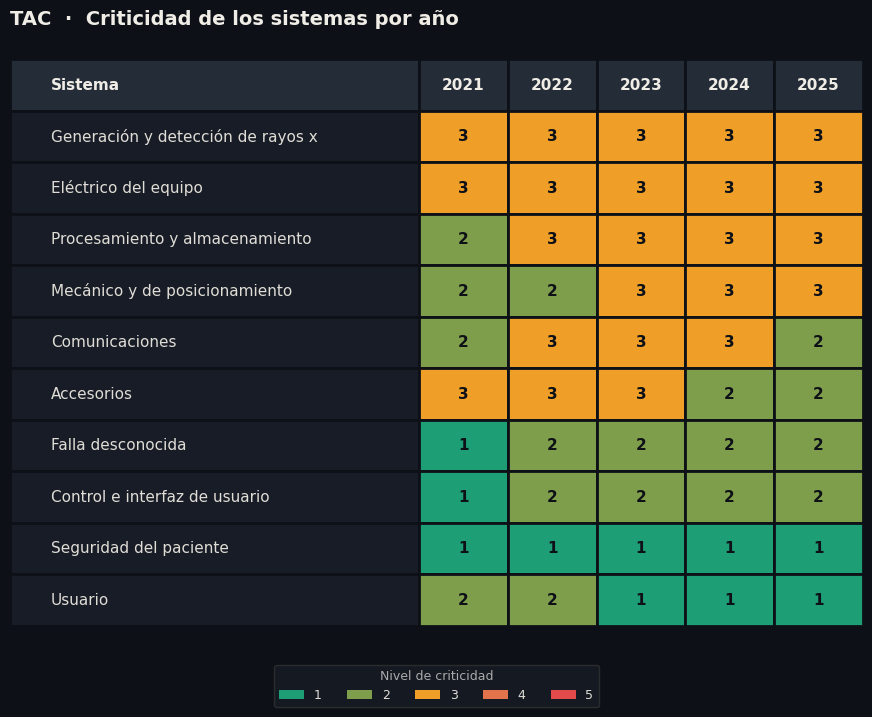

  Generada: criticidad_TAC.png (10 sistemas)


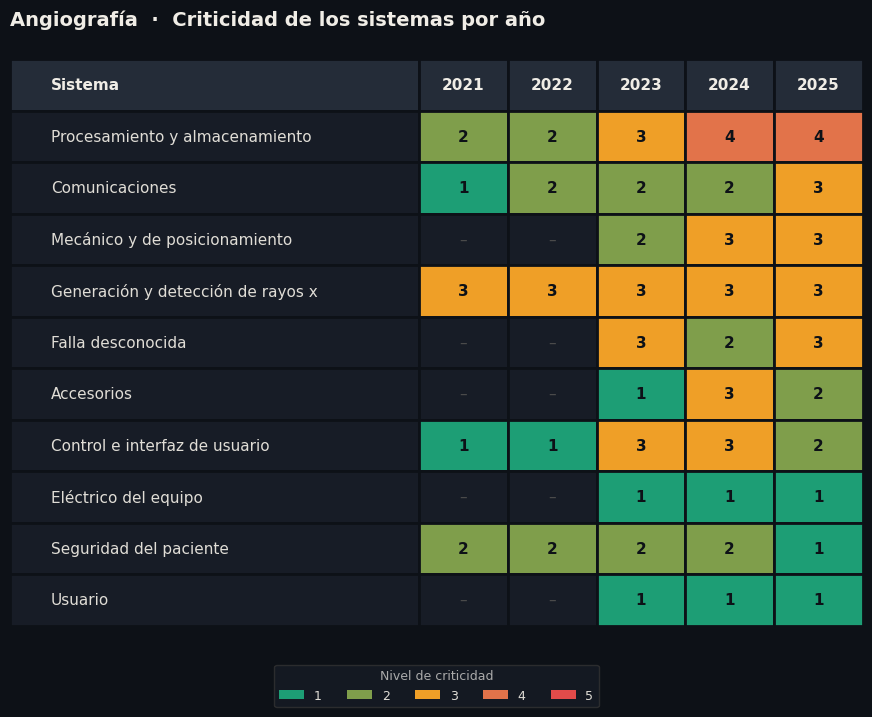

  Generada: criticidad_Angiografía.png (10 sistemas)


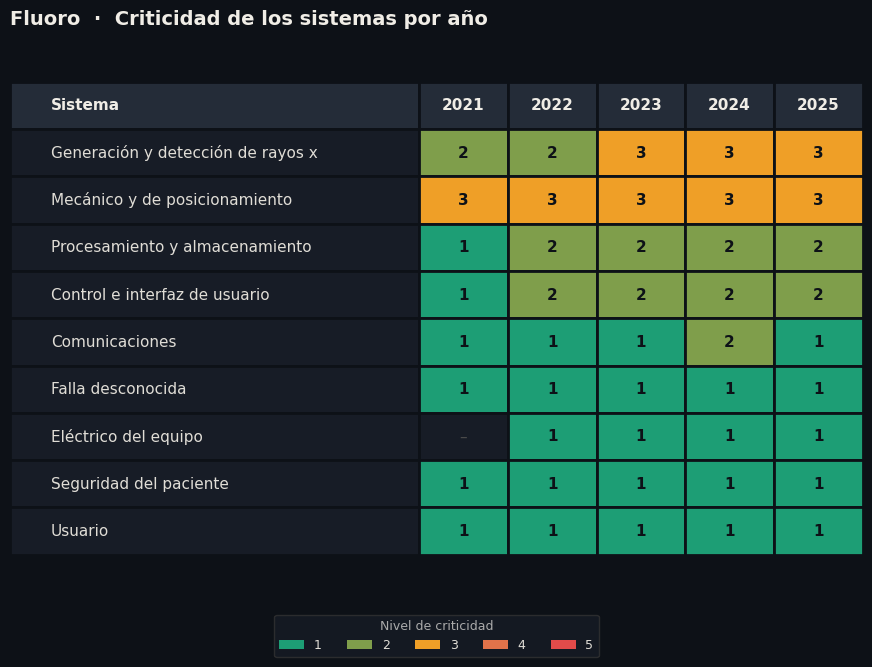

  Generada: criticidad_Fluoro.png (9 sistemas)


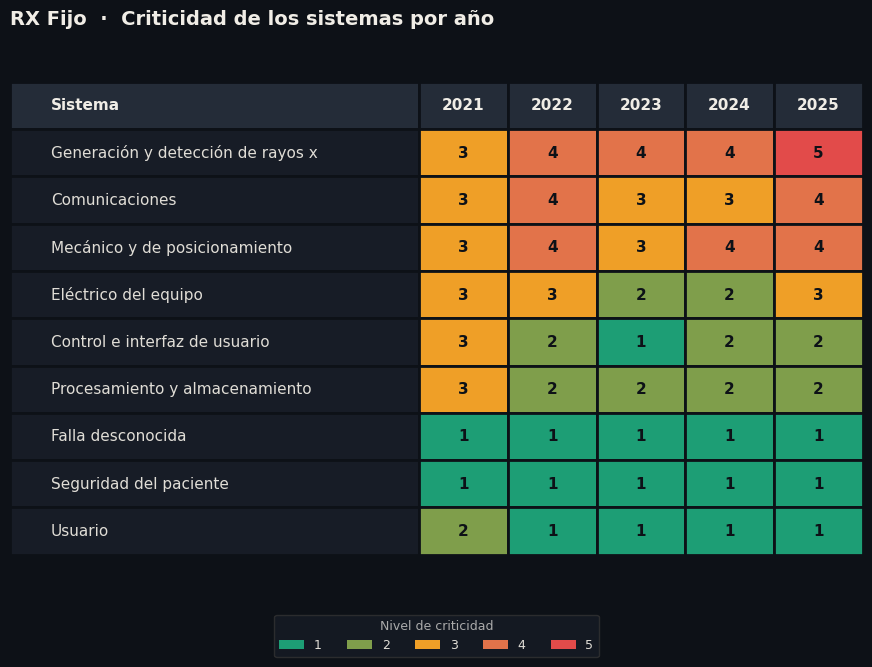

  Generada: criticidad_RX_Fijo.png (9 sistemas)


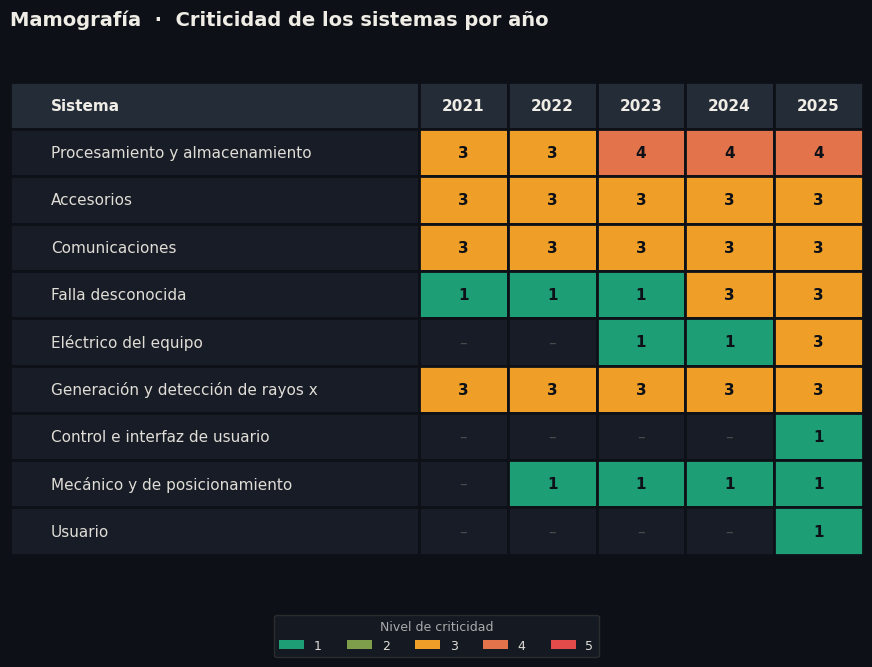

  Generada: criticidad_Mamografía.png (9 sistemas)


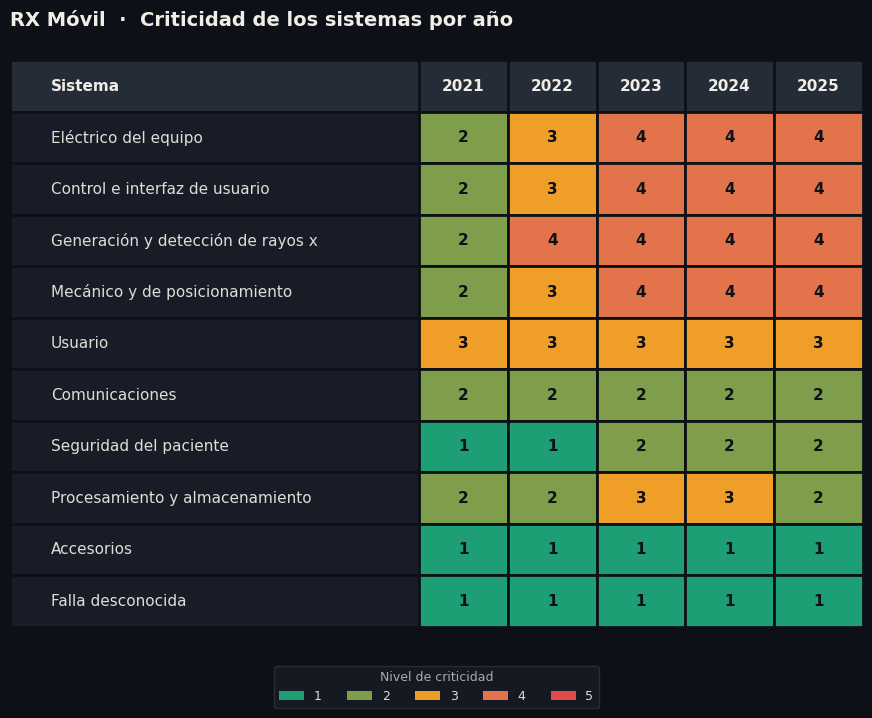

  Generada: criticidad_RX_Móvil.png (10 sistemas)


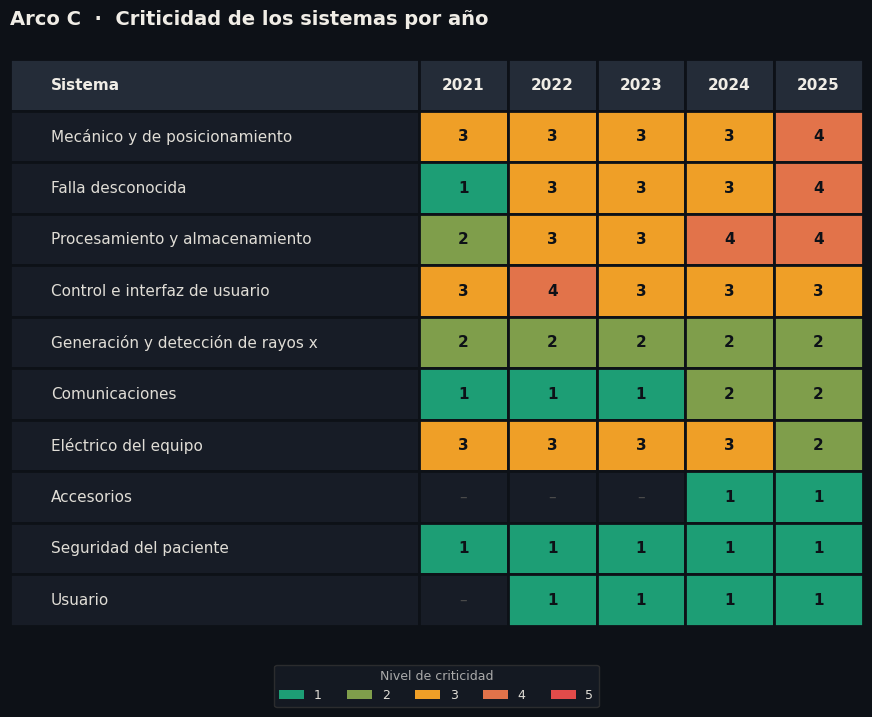

  Generada: criticidad_Arco_C.png (10 sistemas)

Total: 7 tablas (una por equipo).


In [11]:
# ── CELDA 5D — TABLAS DE CRITICIDAD POR SISTEMA Y AÑO — UNA POR EQUIPO ───
# Para cada tipo de equipo: criticidad acumulada por año de sus sistemas.
# Colores por nivel (verde=1 a rojo=5). Muestra la convergencia temporal.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

COL_CRIT = {1: "#1D9E75", 2: "#7F9E4B", 3: "#EF9F27", 4: "#E2734A", 5: "#E24B4A"}
cols_anio = [c for c in tabla_criticidad.columns if c.startswith("crit_")]
anios_lbl = [c.replace("crit_", "") for c in cols_anio]

def capitalizar_sistema(s):
    """Primera letra en mayúscula, respetando el resto del texto."""
    s = str(s).strip()
    return s[0].upper() + s[1:] if s else s

crit_df = tabla_criticidad.reset_index()

for tipo in sorted(crit_df["tipo_equipo"].unique()):
    sub = crit_df[crit_df["tipo_equipo"] == tipo].copy()
    if len(sub) == 0:
        continue

    ultimo = cols_anio[-1]
    sub = sub.sort_values(ultimo, ascending=False, na_position="last")

    headers = ["Sistema"] + anios_lbl
    cell_text = []
    for _, r in sub.iterrows():
        fila = [capitalizar_sistema(r["sistema_general"])]
        fila += [("–" if pd.isna(r[c]) else str(int(round(r[c])))) for c in cols_anio]
        cell_text.append(fila)

    n = len(cell_text)
    fig, ax = plt.subplots(figsize=(11, n * 0.62 + 1.4))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")
    ax.axis("off")

    ancho_anio = 0.52 / len(anios_lbl)
    t = ax.table(cellText=cell_text, colLabels=headers, cellLoc="center", loc="center",
                 colWidths=[0.48] + [ancho_anio] * len(anios_lbl))
    t.auto_set_font_size(False)
    t.set_fontsize(11)

    for (rr, cc), cell in t.get_celld().items():
        cell.set_height(0.088)
        cell.set_edgecolor("#0d1117")     # borde del color del fondo: separación limpia
        cell.set_linewidth(2)
        if rr == 0:
            cell.set_facecolor("#242c38")
            if cc == 0:
                cell.set_text_props(color="#f0ede6", weight="bold", ha="left")
            else:
                cell.set_text_props(color="#f0ede6", weight="bold")
        else:
            val = cell_text[rr - 1][cc]
            if cc >= 1 and val != "–":
                cell.set_facecolor(COL_CRIT.get(int(val), "#141821"))
                cell.set_text_props(color="#0d1117", weight="bold")
            elif cc == 0:
                cell.set_facecolor("#171c26")
                cell.set_text_props(color="#e0ddd6", ha="left")
            else:
                cell.set_facecolor("#171c26")
                cell.set_text_props(color="#4a4a4a")

    nombre_corto = NOMBRES_CORTOS.get(tipo, tipo)
    ax.set_title(f"{nombre_corto}  ·  Criticidad de los sistemas por año",
                 color="#f0ede6", fontsize=14, pad=18, loc="left", fontweight="bold")

    leyenda = [Patch(facecolor=COL_CRIT[nv], label=f"{nv}") for nv in range(1, 6)]
    lg = ax.legend(handles=leyenda, loc="upper center", bbox_to_anchor=(0.5, -0.04),
                   ncol=5, facecolor="#171c26", edgecolor="#333", labelcolor="#e0ddd6",
                   fontsize=9, title="Nivel de criticidad", title_fontsize=9)
    lg.get_title().set_color("#aaaaaa")

    archivo = f"criticidad_{nombre_corto.replace(' ', '_').replace('/', '_')}.png"
    plt.savefig(archivo, dpi=200, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f"  Generada: {archivo} ({n} sistemas)")

print(f"\nTotal: {crit_df['tipo_equipo'].nunique()} tablas (una por equipo).")

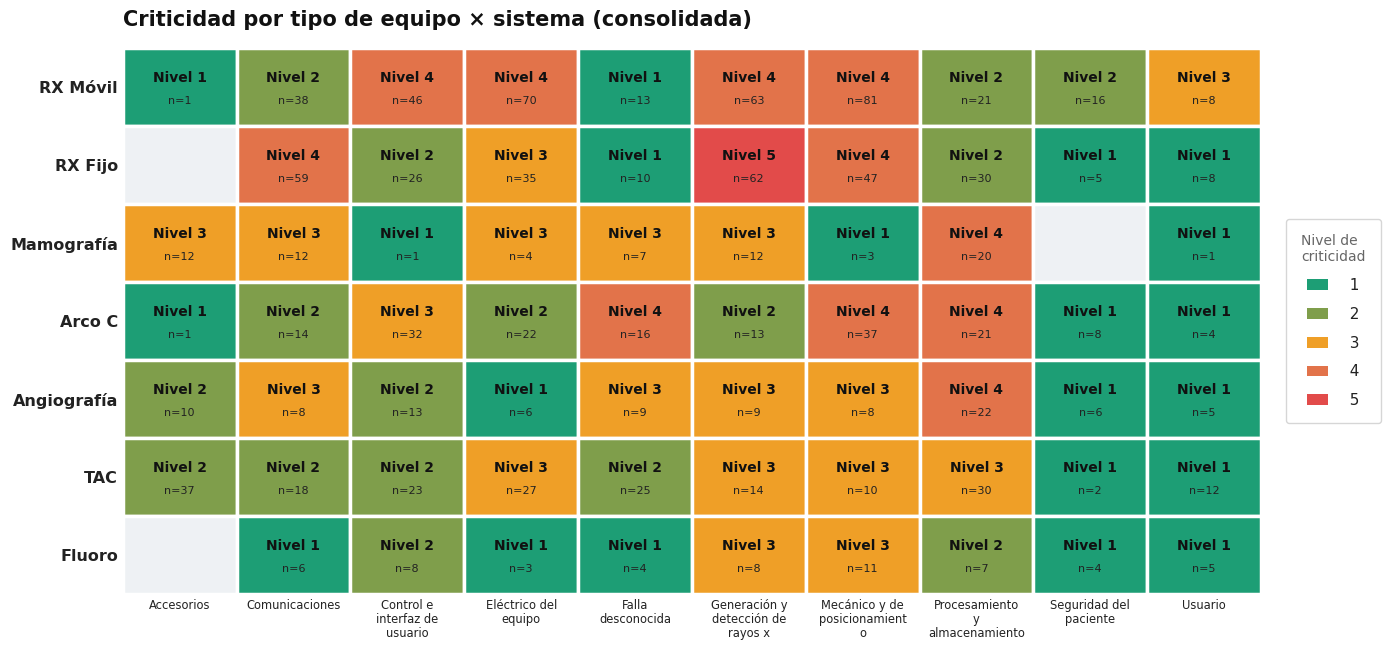

In [12]:
# ── CELDA 5-FIG — MATRIZ GLOBAL DE CRITICIDAD (equipo × sistema) ──
# Vista consolidada nivel 1-5 por tipo_equipo × sistema. Lee de 'base'.
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, textwrap
from matplotlib.patches import Patch

COL_CRIT = {1:"#1D9E75", 2:"#7F9E4B", 3:"#EF9F27", 4:"#E2734A", 5:"#E24B4A"}

M = base.copy()
M["tipo_corto"] = M["tipo_equipo"].map(NOMBRES_CORTOS).fillna(M["tipo_equipo"])
# Solo sistemas físicos: descomentar
# M = M[~M["sistema_general"].isin(["falla desconocida", "usuario"])]

crit = M.pivot(index="tipo_corto", columns="sistema_general", values="criticidad")
nmat = M.pivot(index="tipo_corto", columns="sistema_general", values="total_fallas")
orden = crit.mean(axis=1).sort_values(ascending=False).index
crit, nmat = crit.loc[orden], nmat.loc[orden]
sistemas = list(crit.columns); nr, nc = crit.shape

cap    = lambda s: s[0].upper() + s[1:]
labels = [textwrap.fill(cap(s), 14) for s in sistemas]

fig, ax = plt.subplots(figsize=(14, 6.6))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
for i in range(nr):
    for j in range(nc):
        v = crit.iloc[i, j]
        if pd.isna(v):
            ax.add_patch(plt.Rectangle((j, nr-1-i), 1, 1, facecolor="#EEF1F4",
                         edgecolor="white", lw=2.5)); continue
        ax.add_patch(plt.Rectangle((j, nr-1-i), 1, 1, facecolor=COL_CRIT[int(v)],
                     edgecolor="white", lw=2.5))
        ax.text(j+0.5, nr-1-i+0.62, f"Nivel {int(v)}", ha="center", va="center",
                color="#111", fontsize=10, weight="bold")
        ax.text(j+0.5, nr-1-i+0.32, f"n={int(nmat.iloc[i, j])}", ha="center", va="center",
                color="#222", fontsize=8)

ax.set_xlim(0, nc); ax.set_ylim(0, nr)
ax.set_xticks(np.arange(nc)+0.5)
ax.set_xticklabels(labels, rotation=0, ha="center", color="#222",
                   fontsize=8.3, linespacing=1.1)
ax.set_yticks(np.arange(nr)+0.5)
ax.set_yticklabels(list(crit.index)[::-1], color="#222", fontsize=11.5, weight="bold")
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_title("Criticidad por tipo de equipo × sistema (consolidada)",
             color="#111", fontsize=15, pad=16, loc="left", fontweight="bold")

leg = [Patch(facecolor=COL_CRIT[n], label=f"  {n}") for n in range(1, 6)]
lg = ax.legend(handles=leg, loc="center left", bbox_to_anchor=(1.015, 0.5),
               facecolor="white", edgecolor="#cccccc", labelcolor="#222", fontsize=11,
               title="Nivel de\ncriticidad", title_fontsize=10, handlelength=1.4,
               borderpad=1.0, labelspacing=0.9)
lg.get_title().set_color("#666666")
plt.tight_layout()
plt.savefig("criticidad_global.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

6.  Se construyen cinco features temporales por equipo: edad_dias (días desde la puesta en marcha hasta el fallo), tbf_dias (tiempo entre fallos consecutivos del mismo equipo), horas_parada_acumuladas (horas fuera de servicio acumuladas de fallas anteriores al evento actual), y fallos_30_dias y fallos_90_dias (cantidad de fallos en los 30 y 90 días anteriores a cada evento). Tanto las ventanas de conteo como las horas acumuladas usan exclusivamente información anterior a la fecha del evento, de modo que ninguna variable incorpora datos del evento actual, simultáneos o futuros, evitando fuga temporal. Los nulos en tbf_dias (31) corresponden al primer registro de cada equipo, que no tiene un evento previo contra el cual medir el intervalo.

In [13]:
# ── CELDA 6 — VARIABLES TEMPORALES ────────────────────────────
df["fecha_falla"]            = pd.to_datetime(df["fecha_falla"])
df["fecha_puesta_en_marcha"] = pd.to_datetime(df["fecha_puesta_en_marcha"])

df["edad_dias"] = (df["fecha_falla"] - df["fecha_puesta_en_marcha"]).dt.days

df = df.sort_values(["equipo", "fecha_falla"]).reset_index(drop=True)

df["tbf_dias"] = (
    df.groupby("equipo")["fecha_falla"]
    .diff()
    .dt.days
)

# Horas de parada acumuladas SOLO de fallas anteriores (excluye el evento
# actual): al registrarse la falla, las horas de su reparación aún no se
# conocen. shift(1) evita usar información no disponible en el momento de alerta.
df["horas_parada_acumuladas"] = (
    df.groupby("equipo")["horas_de_parada_num"]
    .cumsum()
    .groupby(df["equipo"])
    .shift(1)
    .fillna(0)
)

def fallos_ultimos_n(grupo, dias=30):
    fechas = pd.to_datetime(grupo["fecha_falla"])
    resultado = []
    for fecha in fechas:
        n = ((fechas < fecha) & (fechas >= fecha - pd.Timedelta(days=dias))).sum()
        resultado.append(n)
    return pd.Series(resultado, index=grupo.index)

df["fallos_30_dias"] = (
    df.groupby("equipo", group_keys=False)[["fecha_falla"]]
    .apply(fallos_ultimos_n)
)

def fallos_ultimos_90(grupo, dias=90):
    fechas = pd.to_datetime(grupo["fecha_falla"])
    resultado = []
    for fecha in fechas:
        n = ((fechas < fecha) & (fechas >= fecha - pd.Timedelta(days=dias))).sum()
        resultado.append(n)
    return pd.Series(resultado, index=grupo.index)

df["fallos_90_dias"] = (
    df.groupby("equipo", group_keys=False)[["fecha_falla"]]
    .apply(fallos_ultimos_90)
)

# ── Resultados ─────────────────────────────────────────────────
print(f"tbf_dias nulos      : {df['tbf_dias'].isna().sum()} (primer evento por equipo)")
print(f"edad_dias nulos     : {df['edad_dias'].isna().sum()}")
print(f"edad_dias negativos : {(df['edad_dias'] < 0).sum()}")

vars_temporales = [
    "edad_dias", "tbf_dias", "horas_parada_acumuladas",
    "fallos_30_dias", "fallos_90_dias",
]
resumen = df[vars_temporales].describe().T.round(2)
resumen = resumen.rename(columns={"50%": "mediana"})

print("\nResumen de variables temporales:")
print(resumen.to_string())

tbf_dias nulos      : 31 (primer evento por equipo)
edad_dias nulos     : 0
edad_dias negativos : 0

Resumen de variables temporales:
                          count     mean      std   min     25%  mediana      75%     max
edad_dias                1230.0  1914.52  1320.72  10.0  773.25   1738.0  2873.50  5447.0
tbf_dias                 1199.0    39.16    61.12   0.0    7.00     20.0    44.00   631.0
horas_parada_acumuladas  1230.0   330.40   484.50   0.0    0.00     81.0   551.75  3627.0
fallos_30_dias           1230.0     1.16     1.38   0.0    0.00      1.0     2.00     8.0
fallos_90_dias           1230.0     3.40     3.03   0.0    1.00      3.0     5.00    16.0


7. Preparación final del dataset: Se calculan las features finales del pipeline. tbf_promedio_equipo se construye usando únicamente los intervalos anteriores a cada evento (mediante desplazamiento temporal), evitando fuga de datos; tendencia_tbf se define como la diferencia logarítmica entre el TBF del intervalo previo y el promedio histórico, por lo que tampoco incorpora el intervalo actual. fallos_acumulados cuenta el número de evento del equipo (calculado sobre el registro completo, antes del filtrado). tasa_fallo_equipo mide el ritmo de fallo en fallas por año, relativo a la edad del equipo. tbf_anterior corresponde al intervalo entre fallas del evento previo (no debe interpretarse como los días transcurridos hasta el evento actual). Se construye df_modelo excluyendo los primeros registros de cada equipo, que no tienen TBF calculable al carecer de un evento previo. La variable tbf_confiable se conserva para análisis pero no entra al modelo.

In [14]:
# ── CELDA 7 — PREPARACIÓN FINAL DEL DATASET ───────────────────

# TBF promedio histórico por equipo (solo fallos anteriores al actual, anti-fuga)
df["tbf_promedio_equipo"] = df.groupby("equipo")["tbf_dias"].transform(
    lambda x: x.shift(1).expanding().mean()
)

# Tendencia del TBF: intervalo previo vs promedio histórico (log-escala)
df["tendencia_tbf"] = (
    np.log1p(df.groupby("equipo")["tbf_dias"].shift(1)) -
    np.log1p(df["tbf_promedio_equipo"])
)

# fallos_acumulados sobre df COMPLETO (antes del filtrado): así el conteo
# refleja el número real de evento del equipo, incluido el primero.
df["fallos_acumulados"] = df.groupby("equipo").cumcount() + 1

# Corrección variantes motivo_tbf
df["motivo_tbf"] = df["motivo_tbf"].replace({
    "Falla simultánea distinto componente"  : "Falla simultáneas distintos componentes",
    "Falla simultánea distinto componente " : "Falla simultáneas distintos componentes",
}).fillna("normal")

# tbf_confiable — para análisis, no entra al modelo
df["tbf_confiable"] = np.where(
    df["motivo_tbf"] == "Falla simultáneas distintos componentes", 0, 1
)

# ── Construir df_modelo ────────────────────────────────────────
df_modelo = df[df["tbf_dias"].notna()].copy()

df_modelo["tbf_dias_log"] = np.log1p(df_modelo["tbf_dias"])

# Imputar nulos en features temporales:
#   tbf_promedio_equipo -> mediana (primer evento sin histórico)
#   tendencia_tbf       -> 0 (sin evento previo, tendencia neutra)
# NOTA: la mediana se calcula sobre todo el conjunto; en un esquema con
# validación temporal estricta debería aprenderse solo del entrenamiento.
df_modelo["tbf_promedio_equipo"] = df_modelo["tbf_promedio_equipo"].fillna(
    df_modelo["tbf_promedio_equipo"].median()
)
df_modelo["tendencia_tbf"] = df_modelo["tendencia_tbf"].fillna(0)

# Tasa de fallo del equipo en fallas por AÑO (más interpretable que por día)
df_modelo["tasa_fallo_equipo"] = (
    df_modelo["fallos_acumulados"] /
    (df_modelo["edad_dias"].replace(0, np.nan) / 365.25)
).fillna(0)

# tbf_anterior: TBF del evento previo del equipo (antes se llamaba, de forma
# imprecisa, 'dias_desde_ultimo_fallo'). Es el intervalo anterior, no los
# días transcurridos hasta el evento actual.
df_modelo["tbf_anterior"] = (
    df_modelo.groupby("equipo")["tbf_dias"]
    .shift(1)
    .fillna(0)
)

# ── Target ─────────────────────────────────────────────────────
TARGET_PERIODO  = "periodo_fallo"

# ── Verificación de columnas reales usadas por los modelos ────
print(f"df total   : {len(df)}")
print(f"df_modelo  : {len(df_modelo)}")

cols_verificar = sorted(set(FEATURES_A))

print(f"\nVerificación de columnas base en df_modelo ({len(cols_verificar)}):")
faltantes = 0
for f in cols_verificar:
    existe = f in df_modelo.columns
    ok     = "OK" if existe else "FALTA"
    nulos  = df_modelo[f].isna().sum() if existe else "N/A"
    if not existe:
        faltantes += 1
    print(f"  [{ok}] {f:<32} nulos: {nulos}")

if faltantes == 0:
    print("\n  Todas las columnas base de esta etapa están presentes.")
else:
    print(f"\n  Faltan {faltantes} columnas inesperadas — revisar celdas anteriores.")

df total   : 1230
df_modelo  : 1199

Verificación de columnas base en df_modelo (11):
  [OK] criticidad_temporal              nulos: 0
  [OK] edad_dias                        nulos: 0
  [OK] fallos_30_dias                   nulos: 0
  [OK] fallos_90_dias                   nulos: 0
  [OK] horas_parada_acumuladas          nulos: 0
  [OK] tasa_fallo_equipo                nulos: 0
  [OK] tbf_anterior                     nulos: 0
  [OK] tbf_dias                         nulos: 0
  [OK] tbf_promedio_equipo              nulos: 0
  [OK] tendencia_tbf                    nulos: 0
  [OK] tipo_equipo                      nulos: 0

  Todas las columnas base de esta etapa están presentes.


# Bloque 2 — Análisis Exploratorio de Datos (EDA)
Antes de construir el modelo predictivo es fundamental entender la estructura y el comportamiento del dataset. El análisis exploratorio permite identificar patrones en las variables, detectar posibles problemas de balanceo entre clases y validar que las features construidas en el pre-procesamiento tienen sentido operacional antes de entregarlas al modelo.
En este bloque se analizan las distribuciones de las variables más relevantes, la relación entre las variables y el target, el balanceo de la clase objetivo del Modelo A, y se aplicó la técnica de reducción de dimensionalidad — UMAP — para visualizar si los datos presentan separabilidad natural entre clases. Los resultados del EDA guiaron decisiones clave del pipeline como la selección de features, el manejo del desbalanceo de clases mediante compute_sample_weight y la caracterización del fenómeno de recurrencia temprana.

8. El análisis del TBF fundamenta el umbral del target. La distribución
presenta un fuerte sesgo a la derecha: la mayoría de las fallas ocurren en
intervalos cortos. La curva de supervivencia muestra que a los 30 días una
mayoría de los equipos ya ha presentado su próxima falla. El panel de balance
evidencia que el umbral de 30 días sitúa el corte entre la mediana empírica
—que produciría clases casi equilibradas— y el horizonte de planificación
operativa requerido por la institución. El desbalance resultante se maneja
mediante ponderación de clases en el entrenamiento.

/tmp/ipykernel_846/1207826551.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])


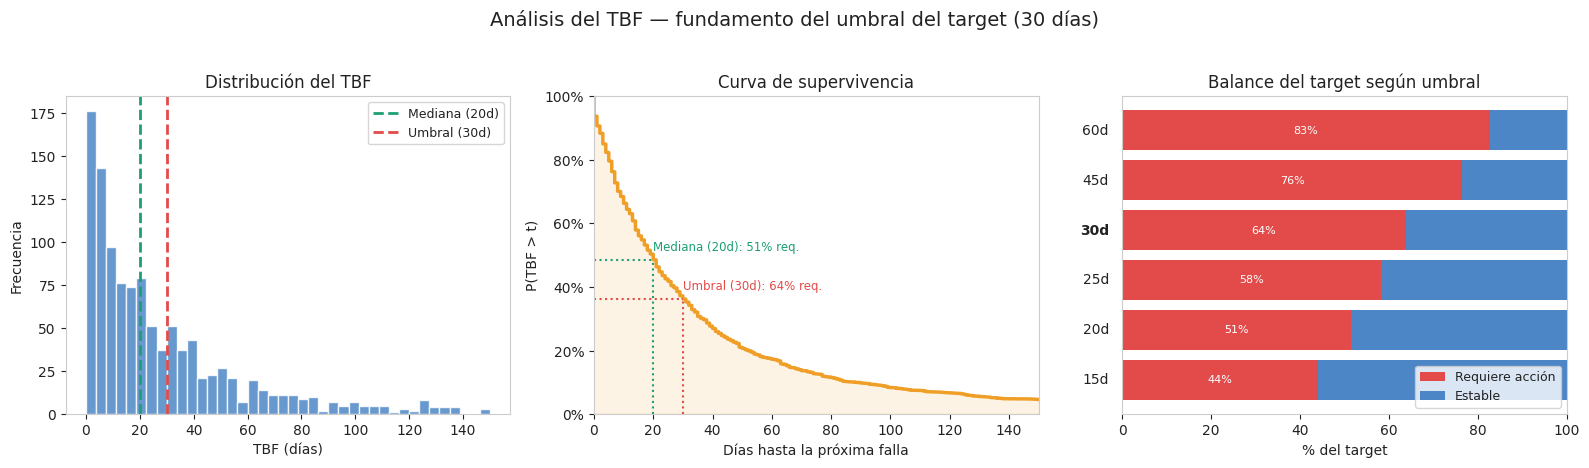

  ANÁLISIS DEL TBF — FUNDAMENTO DEL UMBRAL

  Media    : 37.7 días
  Mediana  : 20 días
  Asimetría: 3.96 (sesgo a la derecha)

  Cuartiles de supervivencia:
    25% ya falló a los 7 días
    50% (mediana)      20 días
    75% ya falló a los 43 días

  Balance con umbral = 30d: 63.8% Requiere acción / 36.2% Estable


In [15]:
# CELDA 8----── ANÁLISIS DE TBF — FUNDAMENTO DEL UMBRAL DEL TARGET ───────
# Analiza el tiempo entre fallas (TBF) para sustentar el umbral del
# target periodo_fallo. Fondo blanco.
import matplotlib.pyplot as plt
import numpy as np

UMBRAL = 30
FG = "#222"      # texto
SP = "#cccccc"   # bordes/ejes

if "tbf_siguiente" not in df_modelo.columns:
    df_modelo["tbf_siguiente"] = df_modelo.groupby("equipo")["tbf_dias"].shift(-1)

tbf = df_modelo["tbf_siguiente"].dropna().values
p25, p50, p75 = np.percentile(tbf, [25, 50, 75])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.patch.set_facecolor("white")

# ── Panel 1: histograma de TBF con mediana y umbral ──────────
ax = axes[0]; ax.set_facecolor("white")
ax.hist(tbf[tbf <= 150], bins=40, color="#4C86C6", alpha=0.85, edgecolor="white")
ax.axvline(p50, color="#1D9E75", linestyle="--", linewidth=2, label=f"Mediana ({p50:.0f}d)")
ax.axvline(UMBRAL, color="#E24B4A", linestyle="--", linewidth=2, label=f"Umbral ({UMBRAL}d)")
ax.set_xlabel("TBF (días)", color=FG)
ax.set_ylabel("Frecuencia", color=FG)
ax.set_title("Distribución del TBF", color=FG, fontsize=12)
ax.tick_params(colors=FG)
ax.legend(facecolor="white", edgecolor=SP, labelcolor=FG, fontsize=9)
for s in ax.spines.values(): s.set_color(SP)

# ── Panel 2: curva de supervivencia ──────────────────────────
ax = axes[1]; ax.set_facecolor("white")
tbf_sorted = np.sort(tbf)
survival = 1 - np.arange(1, len(tbf_sorted) + 1) / len(tbf_sorted)
ax.plot(tbf_sorted, survival, color="#EF9F27", linewidth=2.5)
ax.fill_between(tbf_sorted, survival, color="#EF9F27", alpha=0.12)
for dias, col, lab in [(p50, "#1D9E75", f"Mediana ({p50:.0f}d)"),
                       (UMBRAL, "#E24B4A", f"Umbral ({UMBRAL}d)")]:
    s = (tbf > dias).mean()
    ax.plot([dias, dias], [0, s], color=col, linestyle=":", linewidth=1.5)
    ax.plot([0, dias], [s, s], color=col, linestyle=":", linewidth=1.5)
    ax.annotate(f"{lab}: {(1-s)*100:.0f}% req.", (dias, s + 0.03),
                color=col, fontsize=8.5)
ax.set_xlim(0, 150); ax.set_ylim(0, 1)
ax.set_xlabel("Días hasta la próxima falla", color=FG)
ax.set_ylabel("P(TBF > t)", color=FG)
ax.set_title("Curva de supervivencia", color=FG, fontsize=12)
ax.tick_params(colors=FG)
ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])
for s in ax.spines.values(): s.set_color(SP)

# ── Panel 3: balance del target según el umbral ──────────────
ax = axes[2]; ax.set_facecolor("white")
umbrales = [15, 20, 25, 30, 45, 60]
pct_req = [(tbf <= u).mean() * 100 for u in umbrales]
pct_est = [100 - p for p in pct_req]
y = np.arange(len(umbrales))
ax.barh(y, pct_req, color="#E24B4A", label="Requiere acción")
ax.barh(y, pct_est, left=pct_req, color="#4C86C6", label="Estable")
for i, u in enumerate(umbrales):
    peso = "bold" if u == UMBRAL else "normal"
    ax.text(-3, i, f"{u}d", va="center", ha="right", color=FG,
            fontsize=10, fontweight=peso)
    ax.text(pct_req[i]/2, i, f"{pct_req[i]:.0f}%", va="center", ha="center",
            color="white", fontsize=8)
ax.set_yticks([])
ax.set_xlim(0, 100)
ax.set_xlabel("% del target", color=FG)
ax.set_title("Balance del target según umbral", color=FG, fontsize=12)
ax.tick_params(colors=FG)
ax.legend(facecolor="white", edgecolor=SP, labelcolor=FG, fontsize=9, loc="lower right")
for s in ax.spines.values(): s.set_color(SP)

fig.suptitle("Análisis del TBF — fundamento del umbral del target (30 días)",
             color=FG, fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("analisis_tbf.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# ── Resultados ─────────────────────────────────────────────────
print("=" * 56)
print("  ANÁLISIS DEL TBF — FUNDAMENTO DEL UMBRAL")
print("=" * 56)
print(f"\n  Media    : {tbf.mean():.1f} días")
print(f"  Mediana  : {p50:.0f} días")
print(f"  Asimetría: {df_modelo['tbf_siguiente'].skew():.2f} (sesgo a la derecha)")
print(f"\n  Cuartiles de supervivencia:")
print(f"    25% ya falló a los {p25:.0f} días")
print(f"    50% (mediana)      {p50:.0f} días")
print(f"    75% ya falló a los {p75:.0f} días")
print(f"\n  Balance con umbral = {UMBRAL}d: "
      f"{(tbf<=UMBRAL).mean()*100:.1f}% Requiere acción / "
      f"{(tbf>UMBRAL).mean()*100:.1f}% Estable")

9. Target periodo_fallo: define periodo_fallo como "Requiere acción" si la próxima falla del equipo ocurre en ≤30 días, o "Estable" si ocurre después. Usa el TBF de la falla siguiente (desplazamiento temporal), de modo que el target mira hacia el futuro. El último evento de cada equipo, sin falla posterior observada, se excluye del entrenamiento.

In [16]:
# ── CELDA 9 — TARGET PERIODO_FALLO (BINARIO 30 DÍAS, HACIA ADELANTE) ──
# "Requiere acción" = próxima falla en ≤30 días
# "Estable"         = próxima falla en  >30 días
UMBRAL_DIAS = 30

def clasificar_periodo(tbf):
    if pd.isna(tbf):
        return np.nan
    return "Requiere acción" if tbf <= UMBRAL_DIAS else "Estable"

# Asegurar orden temporal por equipo antes del shift
df_modelo = df_modelo.sort_values(["equipo", "fecha_falla"]).reset_index(drop=True)

# tbf del PRÓXIMO fallo = tiempo desde el fallo actual hasta el siguiente
df_modelo["tbf_siguiente"] = df_modelo.groupby("equipo")["tbf_dias"].shift(-1)

# El target describe si la PRÓXIMA falla requiere acción pronto o no
df_modelo["periodo_fallo"] = df_modelo["tbf_siguiente"].apply(clasificar_periodo)

# ── Resultados ─────────────────────────────────────────────────
total         = df_modelo["periodo_fallo"].notna().sum()
sin_siguiente = df_modelo["tbf_siguiente"].isna().sum()
print(f"Distribución target periodo_fallo — PRÓXIMA falla (n={total}):")
for nombre in ["Requiere acción", "Estable"]:
    n   = (df_modelo["periodo_fallo"] == nombre).sum()
    pct = round(n / total * 100, 1)
    print(f"  {nombre:<20} {n:>5} registros  {pct}%")
print(f"\n  Último evento por equipo (sin 'próxima', se descartan): {sin_siguiente}")
print(f"  Nulos en target: {df_modelo['periodo_fallo'].isna().sum()}")

Distribución target periodo_fallo — PRÓXIMA falla (n=1168):
  Requiere acción        745 registros  63.8%
  Estable                423 registros  36.2%

  Último evento por equipo (sin 'próxima', se descartan): 31
  Nulos en target: 31


9A. documenta la trazabilidad del conjunto de modelado desde el historial depurado hasta la matriz final, registrando el número de observaciones descartadas en cada paso, el número de equipos, los nulos remanentes en las variables de entrada y la distribución de la variable objetivo.



In [17]:
# CELDA 9A — TRAZABILIDAD DEL CONJUNTO DE MODELADO
n_depurado   = len(df)
n_modelo     = len(df_modelo)
n_sin_tbf    = n_depurado - n_modelo
n_sin_target = int(df_modelo[TARGET_PERIODO].isna().sum())
matriz       = df_modelo[FEATURES_A + [TARGET_PERIODO]].dropna()
n_final      = len(matriz)

cierre   = df_modelo["fecha_falla"].max()
ultimos  = df_modelo[df_modelo["tbf_siguiente"].isna()]
seguim   = (cierre - ultimos["fecha_falla"]).dt.days

print("=" * 62)
print("  TRAZABILIDAD DEL CONJUNTO DE MODELADO")
print("=" * 62)
print("  {:<46}{:>8}".format("Historial depurado", n_depurado))
print("  {:<46}{:>8}".format("Sin tiempo entre fallas (primer evento)", -n_sin_tbf))
print("  {:<46}{:>8}".format("Conjunto con tiempo entre fallas", n_modelo))
print("  {:<46}{:>8}".format("Sin objetivo verificable (ultimo evento)", -n_sin_target))
print("  {:<46}{:>8}".format("Matriz final de modelado", n_final))
print("-" * 62)
print("  {:<46}{:>8}".format("Equipos", df["equipo"].nunique()))
print("  {:<46}{:>8}".format(
    "Nulos en variables de entrada",
    int(df_modelo[FEATURES_A].isna().sum().sum())))
print("-" * 62)
print("  Objetivo en la matriz final")
for nombre, n in matriz[TARGET_PERIODO].value_counts().items():
    print("  {:<46}{:>8}  {:>5.1f} %".format(nombre, n, n / n_final * 100))
print("-" * 62)
print("  Seguimiento de los ultimos eventos descartados")
print("  {:<46}{:>8}".format("Con 30 dias o mas antes del cierre",
                             int((seguim >= 30).sum())))
print("  {:<46}{:>8}".format("Con menos de 30 dias",
                             int((seguim < 30).sum())))
print("  {:<46}{:>8}".format("Mediana de dias hasta el cierre",
                             int(seguim.median())))
print("=" * 62)

  TRAZABILIDAD DEL CONJUNTO DE MODELADO
  Historial depurado                                1230
  Sin tiempo entre fallas (primer evento)            -31
  Conjunto con tiempo entre fallas                  1199
  Sin objetivo verificable (ultimo evento)           -31
  Matriz final de modelado                          1168
--------------------------------------------------------------
  Equipos                                             31
  Nulos en variables de entrada                        0
--------------------------------------------------------------
  Objetivo en la matriz final
  Requiere acción                                    745   63.8 %
  Estable                                            423   36.2 %
--------------------------------------------------------------
  Seguimiento de los ultimos eventos descartados
  Con 30 dias o mas antes del cierre                  22
  Con menos de 30 dias                                 9
  Mediana de dias hasta el cierre              

9.b Verificación de censura por cierre del estudio. Confirma que los eventos clasificados como "Estable" cuentan con seguimiento suficiente (≥30 días) hasta la fecha de referencia. El resultado (0 casos dudosos) valida que la estabilidad observada no proviene de truncamiento temporal. Cabe señalar que esta verificación aplica a los eventos con falla posterior observada; los últimos eventos de cada equipo, sin seguimiento, se excluyen previamente (ver limitación de censura).

In [18]:
# CELDA 9B── VERIFICACIÓN DE CENSURA POR CIERRE DEL ESTUDIO ───────────
# Confirma que ningún evento clasificado "Estable" carezca de seguimiento
# suficiente (< horizonte) hasta la fecha de cierre del estudio. De existir,
# serían "falsos Estable" por truncamiento temporal y habría que excluirlos.
fecha_cierre = df_modelo["fecha_falla"].max()

df_cens = df_modelo.copy()
df_cens["dias_hasta_cierre"] = (fecha_cierre - df_cens["fecha_falla"]).dt.days

estables         = df_cens[df_cens["periodo_fallo"] == "Estable"]
estables_dudosos = estables[estables["dias_hasta_cierre"] < UMBRAL_DIAS]

print("Verificación de censura por cierre del estudio")
print(f"  Fecha de cierre (última falla registrada): {fecha_cierre.date()}")
print(f"  Horizonte evaluado                       : {UMBRAL_DIAS} días")
print(f"  Eventos 'Estable'                        : {len(estables)}")
print(f"  'Estable' con seguimiento insuficiente   : {len(estables_dudosos)}")

if len(estables_dudosos) == 0:
    print("\n  Resultado: todos los eventos 'Estable' tienen seguimiento completo.")
    print("  La clasificación de estabilidad no se ve afectada por truncamiento temporal.")
else:
    pct = len(estables_dudosos) / len(estables) * 100
    print(f"\n  Resultado: {len(estables_dudosos)} eventos ({pct:.1f}%) sin seguimiento")
    print("  suficiente. Considerar excluirlos para el horizonte evaluado.")

Verificación de censura por cierre del estudio
  Fecha de cierre (última falla registrada): 2025-10-07
  Horizonte evaluado                       : 30 días
  Eventos 'Estable'                        : 423
  'Estable' con seguimiento insuficiente   : 0

  Resultado: todos los eventos 'Estable' tienen seguimiento completo.
  La clasificación de estabilidad no se ve afectada por truncamiento temporal.


9.C Diagnóstico de viabilidad temporal: verifica que cada año tenga suficientes fallas de ambas clases para constituir folds de validación temporal válidos.

In [19]:
# CELDA 9C ── DIAGNÓSTICO: viabilidad de la validación temporal expansiva ──
df_temp = df_modelo[df_modelo["periodo_fallo"].notna()].copy()
df_temp["anio"] = df_temp["fecha_falla"].dt.year

print("Fallas por año y balance del target (solo con target válido):")
print(f"  {'Año':<6} {'Total':>6} {'Req.acción':>11} {'Estable':>9}")
for anio in sorted(df_temp["anio"].unique()):
    sub = df_temp[df_temp["anio"] == anio]
    n_req = (sub["periodo_fallo"] == "Requiere acción").sum()
    n_est = (sub["periodo_fallo"] == "Estable").sum()
    print(f"  {anio:<6} {len(sub):>6} {n_req:>11} {n_est:>9}")

print("\nTamaño de cada fold expansivo (train acumulado -> valida):")
anios = sorted(df_temp["anio"].unique())
for i in range(1, len(anios)):
    anio_val = anios[i]
    n_train = (df_temp["anio"] < anio_val).sum()
    n_val   = (df_temp["anio"] == anio_val).sum()
    val_req = ((df_temp["anio"] == anio_val) & (df_temp["periodo_fallo"] == "Requiere acción")).sum()
    val_est = ((df_temp["anio"] == anio_val) & (df_temp["periodo_fallo"] == "Estable")).sum()
    viable = "OK" if (val_req >= 10 and val_est >= 10 and n_train >= 50) else "REVISAR (pocos datos)"
    print(f"  Entrena <{anio_val} ({n_train:>4}) -> valida {anio_val} ({n_val:>3}: {val_req}R/{val_est}E)  {viable}")

Fallas por año y balance del target (solo con target válido):
  Año     Total  Req.acción   Estable
  2020      114          67        47
  2021      173         104        69
  2022      188         123        65
  2023      230         144        86
  2024      246         146       100
  2025      217         161        56

Tamaño de cada fold expansivo (train acumulado -> valida):
  Entrena <2021 ( 114) -> valida 2021 (173: 104R/69E)  OK
  Entrena <2022 ( 287) -> valida 2022 (188: 123R/65E)  OK
  Entrena <2023 ( 475) -> valida 2023 (230: 144R/86E)  OK
  Entrena <2024 ( 705) -> valida 2024 (246: 146R/100E)  OK
  Entrena <2025 ( 951) -> valida 2025 (217: 161R/56E)  OK


10. Resumen por tipo de equipo: tabla descriptiva con el comportamiento de cada tipo de equipo (número de equipos, fallas, TBF mediano y promedio, edad real y edad al fallar, horas de parada y porcentaje de TBF no confiable), ordenada por TBF mediano. Caracteriza qué equipos fallan con mayor frecuencia.

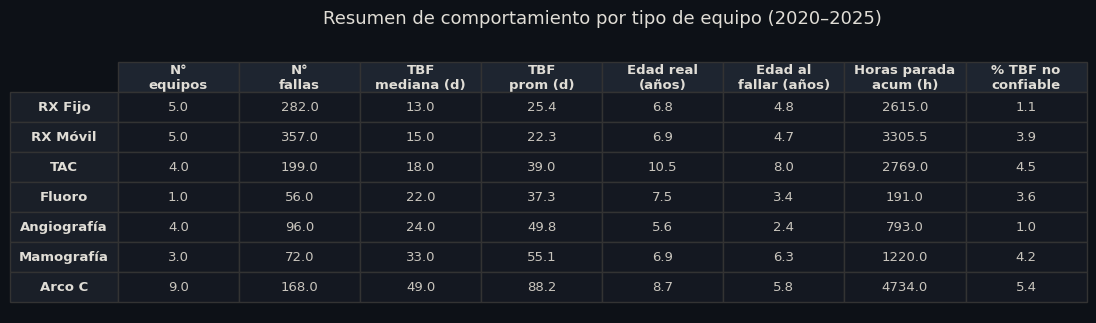

Resumen por tipo de equipo:
             n_equipos  n_fallas  tbf_mediana  tbf_promedio  edad_calendario  edad_al_fallar  horas_acum  pct_no_confiable
tipo_equipo                                                                                                               
RX Fijo              5       282         13.0          25.4              6.8             4.8      2615.0               1.1
RX Móvil             5       357         15.0          22.3              6.9             4.7      3305.5               3.9
TAC                  4       199         18.0          39.0             10.5             8.0      2769.0               4.5
Fluoro               1        56         22.0          37.3              7.5             3.4       191.0               3.6
Angiografía          4        96         24.0          49.8              5.6             2.4       793.0               1.0
Mamografía           3        72         33.0          55.1              6.9             6.3      1220.0       

In [20]:
# ── CELDA 10 — RESUMEN POR TIPO DE EQUIPO ────────────────────
import matplotlib.pyplot as plt

# ── 1. Métricas agregadas por tipo ───────────────────────────
resumen_tipo = df.groupby("tipo_equipo").agg(
    n_equipos        = ("equipo",                  "nunique"),
    n_fallas         = ("id",                      "count"),
    tbf_mediana      = ("tbf_dias",                "median"),
    tbf_promedio     = ("tbf_dias",                "mean"),
    edad_al_fallar   = ("edad_dias",               lambda x: x.mean() / 365),
    horas_acum = ("horas_de_parada_num", "sum"),   # total real de horas de parada
    pct_no_confiable = ("tbf_confiable",           lambda x: (x == 0).mean() * 100),
).round(1)

# ── 2. Edad calendario real (una fecha por equipo, restada de hoy) ──
HOY = pd.Timestamp.now()
edad_cal = (
    df.groupby(["tipo_equipo", "equipo"])["fecha_puesta_en_marcha"].first()
    .reset_index()
    .assign(anios=lambda d: (HOY - d["fecha_puesta_en_marcha"]).dt.days / 365)
    .groupby("tipo_equipo")["anios"].mean().round(1)
)
resumen_tipo["edad_calendario"] = edad_cal

# Orden de columnas: las dos edades juntas
resumen_tipo = resumen_tipo[[
    "n_equipos", "n_fallas", "tbf_mediana", "tbf_promedio",
    "edad_calendario", "edad_al_fallar", "horas_acum", "pct_no_confiable",
]]
resumen_tipo.index = resumen_tipo.index.map(NOMBRES_CORTOS)
resumen_tipo = resumen_tipo.sort_values("tbf_mediana")

# ── 3. Render como figura PNG ────────────────────────────────
COLS = {
    "n_equipos":        "N°\nequipos",
    "n_fallas":         "N°\nfallas",
    "tbf_mediana":      "TBF\nmediana (d)",
    "tbf_promedio":     "TBF\nprom (d)",
    "edad_calendario":  "Edad real\n(años)",
    "edad_al_fallar":   "Edad al\nfallar (años)",
    "horas_acum":       "Horas parada\nacum (h)",
    "pct_no_confiable": "% TBF no\nconfiable",
}
disp = resumen_tipo.rename(columns=COLS)

fig, ax = plt.subplots(figsize=(12.5, 3.4))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")
ax.axis("off")

tabla = ax.table(
    cellText=disp.values, rowLabels=disp.index, colLabels=disp.columns,
    cellLoc="center", rowLoc="center", loc="center",
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1, 1.8)

for (r, c), cell in tabla.get_celld().items():
    cell.set_edgecolor("#333")
    if r == 0:
        cell.set_facecolor("#1e2530")
        cell.set_text_props(color="#e0ddd6", weight="bold")
    elif c == -1:
        cell.set_facecolor("#1a1f28")
        cell.set_text_props(color="#e0ddd6", weight="bold")
    else:
        cell.set_facecolor("#141821")
        cell.set_text_props(color="#c9c5bd")

ax.set_title("Resumen de comportamiento por tipo de equipo (2020–2025)",
             color="#e0ddd6", fontsize=13, pad=20)

plt.savefig("resumen_por_tipo.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Resultados ─────────────────────────────────────────────────
print("Resumen por tipo de equipo:")
print(resumen_tipo.to_string())

11. Variables de entrada del Modelo A: tabla que documenta las 11 features del modelo (10 numéricas + tipo de equipo), con su tipo, descripción e importancia esperada. Todas se calculan con información previa a cada evento.

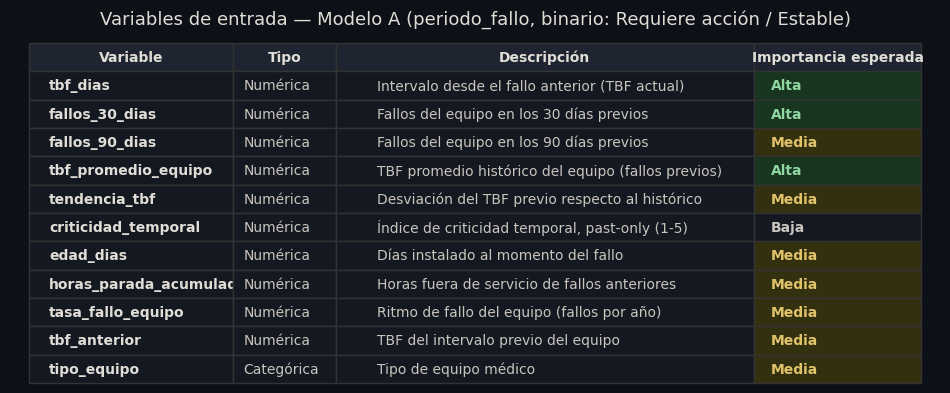

Total variables Modelo A : 11
Numéricas                : 10
Categóricas              : 1
Target                   : periodo_fallo — binario (Requiere acción / Estable)
Nota: la columna 'Importancia esperada' es una hipótesis previa;
la importancia real se verifica con el modelo entrenado (Celda 21).


In [21]:
# ── CELDA 11 — VARIABLES DE ENTRADA MODELO A ──────────────────
import matplotlib.pyplot as plt

variables = pd.DataFrame([
    ["tbf_dias",                "Numérica",   "Intervalo desde el fallo anterior (TBF actual)",     "Alta"],
    ["fallos_30_dias",          "Numérica",   "Fallos del equipo en los 30 días previos",           "Alta"],
    ["fallos_90_dias",          "Numérica",   "Fallos del equipo en los 90 días previos",           "Media"],
    ["tbf_promedio_equipo",     "Numérica",   "TBF promedio histórico del equipo (fallos previos)", "Alta"],
    ["tendencia_tbf",           "Numérica",   "Desviación del TBF previo respecto al histórico",    "Media"],
    ["criticidad_temporal",     "Numérica",   "Índice de criticidad temporal, past-only (1-5)",     "Baja"],
    ["edad_dias",               "Numérica",   "Días instalado al momento del fallo",                "Media"],
    ["horas_parada_acumuladas", "Numérica",   "Horas fuera de servicio de fallos anteriores",       "Media"],
    ["tasa_fallo_equipo",       "Numérica",   "Ritmo de fallo del equipo (fallos por año)",         "Media"],
    ["tbf_anterior",            "Numérica",   "TBF del intervalo previo del equipo",                "Media"],
    ["tipo_equipo",             "Categórica", "Tipo de equipo médico",                              "Media"],
], columns=["Variable", "Tipo", "Descripción", "Importancia esperada"])

fig, ax = plt.subplots(figsize=(12, 4.2))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")
ax.axis("off")

tabla = ax.table(
    cellText=variables.values, colLabels=variables.columns,
    cellLoc="left", loc="center",
    colWidths=[0.22, 0.11, 0.45, 0.18],
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.7)

IMP_COLOR = {"Alta": ("#17351f", "#8fd6a0"), "Media": ("#33300f", "#e0c26a")}
for (r, c), cell in tabla.get_celld().items():
    cell.set_edgecolor("#333")
    if r == 0:
        cell.set_facecolor("#1e2530")
        cell.set_text_props(color="#e0ddd6", weight="bold")
    else:
        val = variables.iloc[r - 1]
        if c == 3:
            bg, fg = IMP_COLOR.get(val["Importancia esperada"], ("#141821", "#c9c5bd"))
            cell.set_facecolor(bg)
            cell.set_text_props(color=fg, weight="bold")
        elif c == 0:
            cell.set_facecolor("#141821")
            cell.set_text_props(color="#e0ddd6", weight="bold")
        else:
            cell.set_facecolor("#141821")
            cell.set_text_props(color="#c9c5bd")

ax.set_title("Variables de entrada — Modelo A (periodo_fallo, binario: Requiere acción / Estable)",
             color="#e0ddd6", fontsize=13, pad=20)

plt.savefig("variables_modelo_a.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Resultados ─────────────────────────────────────────────────
print(f"Total variables Modelo A : {len(variables)}")
print(f"Numéricas                : {(variables['Tipo'] == 'Numérica').sum()}")
print(f"Categóricas              : {(variables['Tipo'] == 'Categórica').sum()}")
print(f"Target                   : {TARGET_PERIODO} — binario (Requiere acción / Estable)")
print("Nota: la columna 'Importancia esperada' es una hipótesis previa;")
print("la importancia real se verifica con el modelo entrenado (Celda 21).")

12. Distribución del target: muestra el balance global del target (64% Requiere acción / 36% Estable) y su proporción por tipo de equipo. Los tipos con mayor frecuencia de fallo (RX Móvil, RX Fijo) concentran más "Requiere acción", reflejando su ritmo de recurrencia.

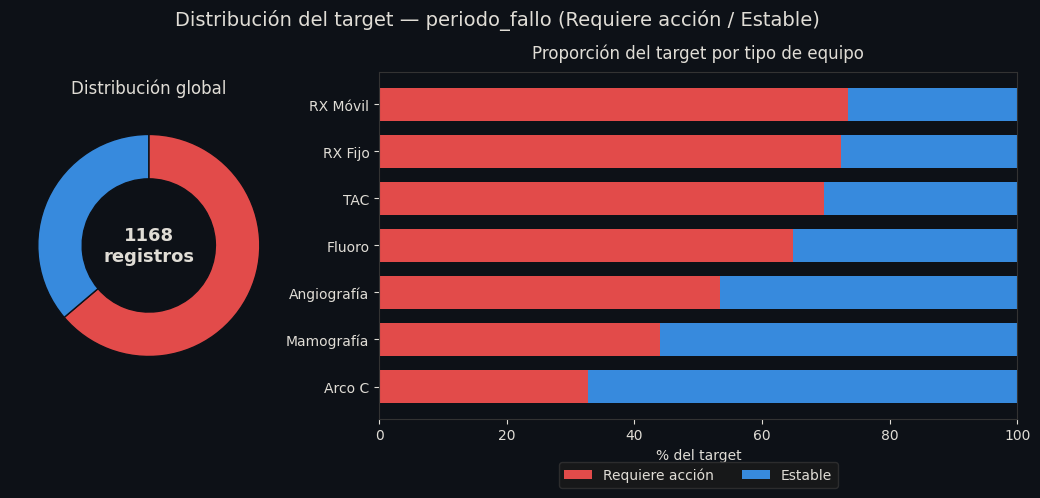

Distribución global (n=1168):
  Requiere acción      745 registros   63.8%
  Estable              423 registros   36.2%

Proporción de 'Requiere acción' por tipo de equipo:
  RX Móvil        73.5%
  RX Fijo         72.4%
  TAC             69.6%
  Fluoro          64.8%
  Angiografía     53.4%
  Mamografía      43.9%
  Arco C          32.7%


In [22]:
# ── CELDA 12 — DISTRIBUCIÓN DEL TARGET PERIODO_FALLO (binario) ──
import matplotlib.pyplot as plt
import numpy as np

if "tipo_corto" not in df_modelo.columns:
    df_modelo["tipo_corto"] = df_modelo["tipo_equipo"].map(NOMBRES_CORTOS)

CLASES = ["Requiere acción", "Estable"]
COL = {"Requiere acción": "#E24B4A", "Estable": "#378ADD"}

# Solo registros con target (excluye los NaN de ultimo evento por equipo)
dft = df_modelo[df_modelo["periodo_fallo"].notna()].copy()

# Global
g = dft["periodo_fallo"].value_counts()
total = len(dft)

# Proporcion por tipo (ordenado por % Requiere acción)
prop = (dft.groupby("tipo_corto")["periodo_fallo"]
        .value_counts(normalize=True).unstack(fill_value=0) * 100)
prop = prop.reindex(columns=CLASES).sort_values("Requiere acción", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5),
                               gridspec_kw={"width_ratios": [1, 2.3]})
fig.patch.set_facecolor("#0d1117")

# ── Panel 1: dona global ─────────────────────────────────────
ax1.set_facecolor("#0d1117")
ax1.pie([g.get(c, 0) for c in CLASES], colors=[COL[c] for c in CLASES],
        startangle=90, counterclock=False,
        wedgeprops=dict(width=0.4, edgecolor="#0d1117"))
ax1.text(0, 0, f"{total}\nregistros", ha="center", va="center",
         color="#e0ddd6", fontsize=13, weight="bold")
ax1.set_title("Distribución global", color="#e0ddd6", fontsize=12, pad=10)

# ── Panel 2: barras 100% apiladas por tipo ───────────────────
ax2.set_facecolor("#0d1117")
y = np.arange(len(prop))
left = np.zeros(len(prop))
for c in CLASES:
    ax2.barh(y, prop[c], left=left, color=COL[c], label=c, height=0.7)
    left += prop[c].values
ax2.set_yticks(y)
ax2.set_yticklabels(prop.index, color="#e0ddd6", fontsize=10)
ax2.set_xlim(0, 100)
ax2.set_xlabel("% del target", color="#e0ddd6")
ax2.tick_params(colors="#e0ddd6")
ax2.set_title("Proporción del target por tipo de equipo",
              color="#e0ddd6", fontsize=12, pad=10)
for s in ax2.spines.values():
    s.set_color("#333")
ax2.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=2,
           facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6", fontsize=10)

fig.suptitle("Distribución del target — periodo_fallo (Requiere acción / Estable)",
             color="#e0ddd6", fontsize=14, y=1.02)
plt.savefig("distribucion_target.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Resultados ─────────────────────────────────────────────────
print(f"Distribución global (n={total}):")
for c in CLASES:
    pct = round(g[c] / total * 100, 1)
    print(f"  {c:<18} {g[c]:>5} registros  {pct:>5}%")
print("\nProporción de 'Requiere acción' por tipo de equipo:")
for tipo in prop.sort_values("Requiere acción", ascending=False).index:
    print(f"  {tipo:<14} {prop.loc[tipo, 'Requiere acción']:>5.1f}%")

13. Patrón de recurrencia por tipo de equipo: muestra el TBF mediano y el porcentaje de fallas recurrentes (≤30 días) por tipo de equipo. Evidencia que unos tipos (RX Móvil, RX Fijo) fallan con mayor frecuencia que otros (Arco C, Mamografía), sustentando el umbral del target y la priorización del checklist.

Patrón de recurrencia por tipo de equipo:
             n_fallas  tbf_mediana  pct_recurrencia_corta
tipo_corto                                               
RX Fijo           277         13.0                   71.8
RX Móvil          352         15.0                   73.3
TAC               195         18.0                   68.2
Fluoro             55         22.0                   65.5
Angiografía        92         24.0                   54.3
Mamografía         69         33.0                   43.5
Arco C            159         49.0                   32.7


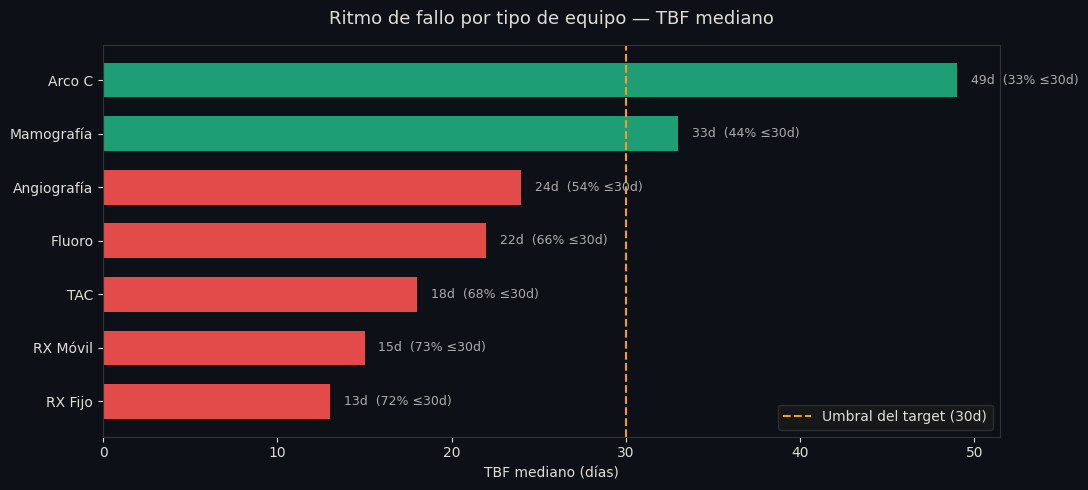

In [23]:
# CELDA 13── PATRÓN DE RECURRENCIA POR TIPO DE EQUIPO ─────────────────
# Ritmo de fallo (TBF) por tipo de equipo. A diferencia del analisis
# por sistema (homogeneo), por tipo si hay diferenciacion: unos tipos
# fallan mas seguido que otros.
import matplotlib.pyplot as plt
import numpy as np

UMBRAL = UMBRAL_DIAS

if "tipo_corto" not in df_modelo.columns:
    df_modelo["tipo_corto"] = df_modelo["tipo_equipo"].map(NOMBRES_CORTOS)

d = df_modelo.dropna(subset=["tbf_dias"])
resumen_tipo_tbf = d.groupby("tipo_corto").agg(
    n_fallas              = ("tbf_dias", "count"),
    tbf_mediana           = ("tbf_dias", "median"),
    pct_recurrencia_corta = ("tbf_dias", lambda x: (x <= UMBRAL).mean() * 100),
).round(1).sort_values("tbf_mediana")

print("Patrón de recurrencia por tipo de equipo:")
print(resumen_tipo_tbf.to_string())

# ── Gráfica ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

colores = ["#E24B4A" if m <= UMBRAL else "#1D9E75" for m in resumen_tipo_tbf["tbf_mediana"]]
y = np.arange(len(resumen_tipo_tbf))
ax.barh(y, resumen_tipo_tbf["tbf_mediana"], color=colores, height=0.65)
ax.axvline(UMBRAL, color="#EF9F27", linestyle="--", linewidth=1.5,
           label=f"Umbral del target ({UMBRAL}d)")

ax.set_yticks(y)
ax.set_yticklabels(resumen_tipo_tbf.index, color="#e0ddd6", fontsize=10)
ax.set_xlabel("TBF mediano (días)", color="#e0ddd6")
ax.set_title("Ritmo de fallo por tipo de equipo — TBF mediano",
             color="#e0ddd6", fontsize=13, pad=15)
ax.tick_params(colors="#e0ddd6")
for s in ax.spines.values():
    s.set_color("#333")

for i, (_, row) in enumerate(resumen_tipo_tbf.iterrows()):
    ax.text(row["tbf_mediana"] + 0.8, i,
            f"{row['tbf_mediana']:.0f}d  ({row['pct_recurrencia_corta']:.0f}% ≤{UMBRAL}d)",
            va="center", color="#aaa", fontsize=9)

ax.legend(facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6", fontsize=10)
plt.tight_layout()
plt.savefig("recurrencia_por_tipo.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Se optó por clasificación binaria en lugar de regresión sobre el TBF por tres razones: la distribución del TBF es severamente asimétrica (4.14) y de alta varianza (0 a 631 días), lo que haría poco fiables las predicciones puntuales de una regresión; la decisión operativa es binaria —intervenir o no dentro de un horizonte—, por lo que predecir el día exacto excede lo que la decisión requiere; y el momento exacto de fallo depende de factores no registrados, haciendo más robusto agrupar en un umbral de riesgo que estimar un valor continuo. Aunque el análisis de supervivencia sería una alternativa para modelar el tiempo hasta el fallo, la clasificación responde de forma más directa e interpretable a la pregunta operativa "¿este equipo requiere acción pronto?".

14. Caracterización de las features numéricas: se analiza la distribución de las variables del Modelo A mediante boxplots y estadísticos (media, mediana, desviación, asimetría y valores atípicos por IQR). Las distribuciones son marcadamente asimétricas y presentan valores extremos que reflejan comportamientos reales de los equipos (intervalos de fallo prolongados, alta confiabilidad), por lo que no se eliminaron. Estas condiciones justifican el uso de un modelo basado en árboles (XGBoost), robusto frente a distribuciones sesgadas y valores atípicos.

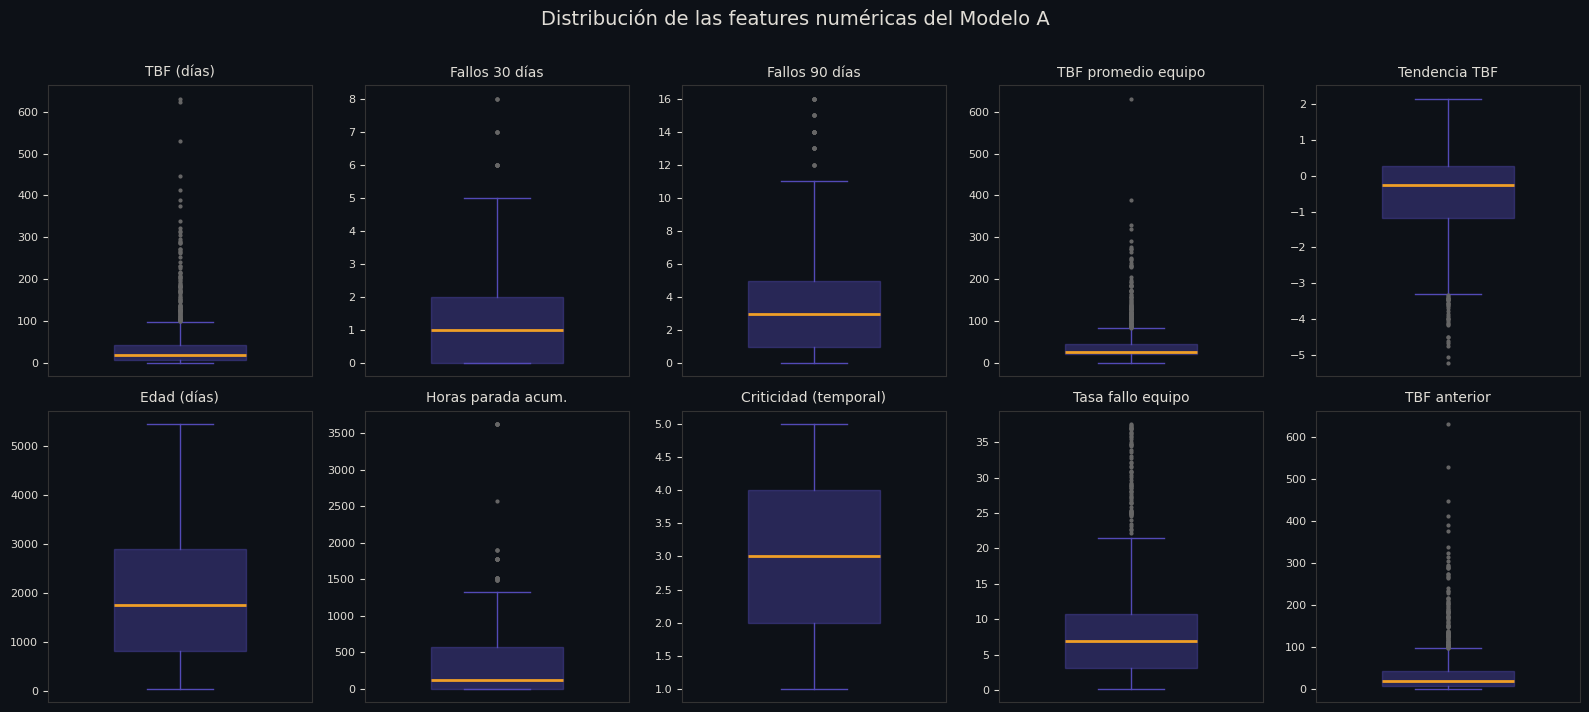

Feature                     Media  Mediana      Std  Asimetría  Outliers IQR
------------------------------------------------------------------------------
  TBF (días)                 39.2     20.0     61.1       4.14      107 (8.9%)
  Fallos 30 días              1.2      1.0      1.4       1.53       15 (1.3%)
  Fallos 90 días              3.5      3.0      3.0       1.55       34 (2.8%)
  TBF promedio equipo        41.7     26.1     45.2       4.50      118 (9.8%)
  Tendencia TBF              -0.5     -0.3      1.2      -0.95       32 (2.7%)
  Edad (días)              1940.5   1758.0   1315.1       0.57        0 (0.0%)
  Horas parada acum.        338.9    118.0    487.8       2.50       40 (3.3%)
  Criticidad (temporal)       2.8      3.0      1.0      -0.21        0 (0.0%)
  Tasa fallo equipo           8.6      7.0      7.2       1.68       69 (5.8%)
  TBF anterior               37.5     19.0     58.0       3.94      108 (9.0%)


In [24]:
# ── CELDA 14 — CARACTERIZACIÓN DE FEATURES NUMÉRICAS ─────────
# Distribución, dispersión y asimetría de las features numéricas del
# Modelo A. Las distribuciones sesgadas y con outliers justifican el uso
# de un modelo robusto a no-normalidad y valores atípicos (XGBoost), que
# los maneja sin transformación previa.
import matplotlib.pyplot as plt
import numpy as np

FEATURES_NUM = {
    "tbf_dias"                : "TBF (días)",
    "fallos_30_dias"          : "Fallos 30 días",
    "fallos_90_dias"          : "Fallos 90 días",
    "tbf_promedio_equipo"     : "TBF promedio equipo",
    "tendencia_tbf"           : "Tendencia TBF",
    "edad_dias"               : "Edad (días)",
    "horas_parada_acumuladas" : "Horas parada acum.",
    "criticidad_temporal"     : "Criticidad (temporal)",
    "tasa_fallo_equipo"       : "Tasa fallo equipo",
    "tbf_anterior"            : "TBF anterior",
}

# ── Boxplots (visualizar distribución y dispersión) ──────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.patch.set_facecolor("#0d1117")
axes = axes.flatten()

for ax, (var, nombre) in zip(axes, FEATURES_NUM.items()):
    ax.set_facecolor("#0d1117")
    serie = df_modelo[var].dropna()
    bp = ax.boxplot(serie, vert=True, patch_artist=True, widths=0.5)
    bp["boxes"][0].set(facecolor="#534AB7", alpha=0.4, edgecolor="#534AB7")
    bp["medians"][0].set(color="#EF9F27", linewidth=2)
    for w in bp["whiskers"]: w.set(color="#534AB7")
    for c in bp["caps"]: c.set(color="#534AB7")
    for f in bp["fliers"]: f.set(marker="o", markersize=2, markerfacecolor="#666", markeredgecolor="#666")
    ax.set_title(nombre, color="#e0ddd6", fontsize=10)
    ax.set_xticks([])
    ax.tick_params(colors="#e0ddd6", labelsize=8)
    for s in ax.spines.values(): s.set_color("#333")

fig.suptitle("Distribución de las features numéricas del Modelo A",
             color="#e0ddd6", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("features_numericas.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Tabla de estadísticos con asimetría e IQR ────────────────
print(f"{'Feature':<24} {'Media':>8} {'Mediana':>8} {'Std':>8} "
      f"{'Asimetría':>10} {'Outliers IQR':>13}")
print("-" * 78)
for var, nombre in FEATURES_NUM.items():
    serie = df_modelo[var].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    # Outliers por IQR (método correcto para datos sesgados)
    out = ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()
    print(f"  {nombre:<22} {serie.mean():>8.1f} {serie.median():>8.1f} "
          f"{serie.std():>8.1f} {serie.skew():>10.2f} "
          f"{out:>8} ({out/len(serie)*100:.1f}%)")

15. Análisis bivariado — variables vs. target. Mediana e intervalo intercuartílico de cada feature según la clase («Requiere acción» / «Estable»), con boxplots de las cuatro más relevantes.

Relación variable ↔ target — mediana [Q1–Q3] por clase
Feature                            Requiere acción                     Estable
--------------------------------------------------------------------------------
TBF (días)                         16.0 [6.0–35.0]            30.0 [10.5–58.5]
Fallos 30 días                       1.0 [0.0–2.0]               0.0 [0.0–1.0]
Fallos 90 días                       3.0 [2.0–5.0]               2.0 [1.0–3.0]
TBF prom. equipo                  24.2 [19.5–33.3]            33.1 [24.3–64.0]
Tendencia TBF                      -0.3 [-1.1–0.2]             -0.2 [-1.2–0.3]
Edad (días)                  1731.0 [829.0–2844.0]       1763.0 [771.5–2896.0]
Horas parada acum.              148.0 [12.0–594.0]            52.0 [0.0–480.0]
Tasa fallo equipo                   8.4 [4.5–12.2]               5.1 [2.2–9.1]
TBF anterior                       16.0 [6.0–37.0]             26.0 [7.5–59.5]


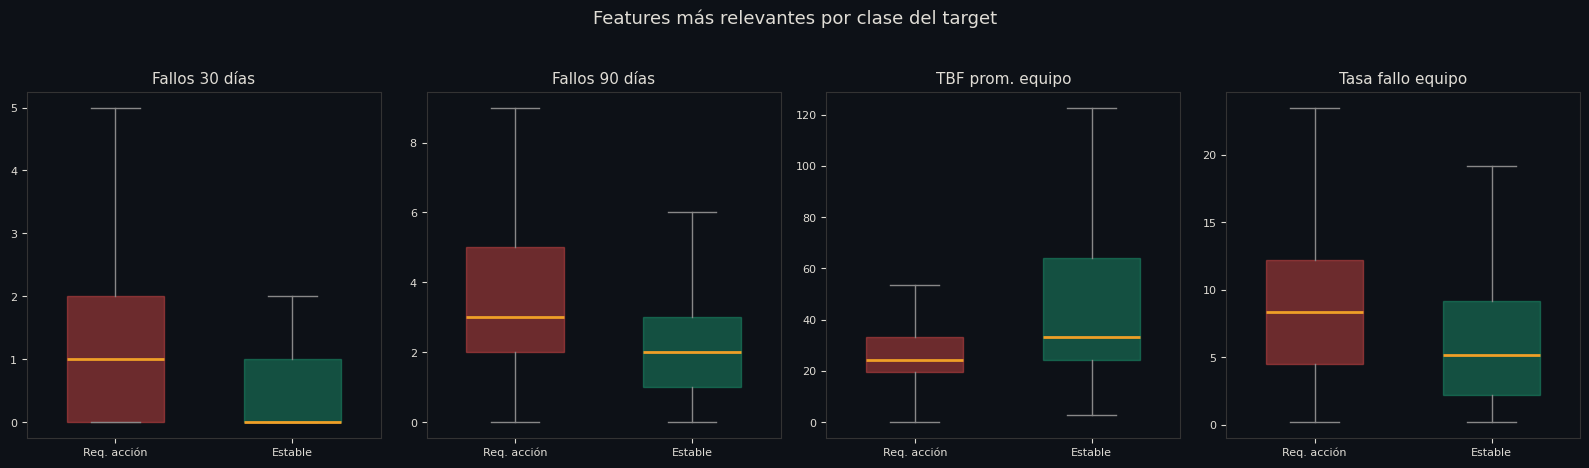

In [25]:
# ── CELDA 15 — RELACIÓN VARIABLE ↔ TARGET (análisis bivariado) ──
# Responde a cómo difieren las features entre
# "Requiere acción" (recurrencia <=30d) y "Estable". Tabla de mediana e
# IQR por clase + 4 boxplots de las variables más relevantes.
import matplotlib.pyplot as plt

features_eda = [
    "tbf_dias", "fallos_30_dias", "fallos_90_dias", "tbf_promedio_equipo",
    "tendencia_tbf", "edad_dias", "horas_parada_acumuladas",
    "tasa_fallo_equipo", "tbf_anterior",
]
NOMBRES_EDA = {
    "tbf_dias": "TBF (días)", "fallos_30_dias": "Fallos 30 días",
    "fallos_90_dias": "Fallos 90 días", "tbf_promedio_equipo": "TBF prom. equipo",
    "tendencia_tbf": "Tendencia TBF", "edad_dias": "Edad (días)",
    "horas_parada_acumuladas": "Horas parada acum.", "tasa_fallo_equipo": "Tasa fallo equipo",
    "tbf_anterior": "TBF anterior",
}

base_eda = df_modelo.dropna(subset=["periodo_fallo"]).copy()

# ── Tabla: mediana [Q1–Q3] por clase ──────────────────────────
print("Relación variable ↔ target — mediana [Q1–Q3] por clase")
print("=" * 80)
print(f"{'Feature':<22}{'Requiere acción':>28}{'Estable':>28}")
print("-" * 80)
for v in features_eda:
    celdas = []
    for clase in ["Requiere acción", "Estable"]:
        s = base_eda.loc[base_eda["periodo_fallo"] == clase, v]
        q1, med, q3 = s.quantile([0.25, 0.5, 0.75])
        celdas.append(f"{med:>7.1f} [{q1:.1f}–{q3:.1f}]")
    print(f"{NOMBRES_EDA[v]:<22}{celdas[0]:>28}{celdas[1]:>28}")

# ── 4 boxplots por clase (variables más relevantes) ───────────
rel = ["fallos_30_dias", "fallos_90_dias", "tbf_promedio_equipo", "tasa_fallo_equipo"]
COL_CLASE = {"Requiere acción": "#E24B4A", "Estable": "#1D9E75"}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.patch.set_facecolor("#0d1117")
for ax, v in zip(axes, rel):
    ax.set_facecolor("#0d1117")
    datos = [base_eda.loc[base_eda["periodo_fallo"] == c, v].dropna()
             for c in ["Requiere acción", "Estable"]]
    bp = ax.boxplot(datos, patch_artist=True, widths=0.55, showfliers=False)
    for box, c in zip(bp["boxes"], ["Requiere acción", "Estable"]):
        box.set(facecolor=COL_CLASE[c], alpha=0.45, edgecolor=COL_CLASE[c])
    for med in bp["medians"]: med.set(color="#EF9F27", linewidth=2)
    for w in bp["whiskers"]: w.set(color="#888")
    for cap in bp["caps"]: cap.set(color="#888")
    ax.set_title(NOMBRES_EDA[v], color="#e0ddd6", fontsize=11)
    ax.set_xticklabels(["Req. acción", "Estable"], color="#e0ddd6", fontsize=9)
    ax.tick_params(colors="#e0ddd6", labelsize=8)
    for s in ax.spines.values(): s.set_color("#333")

fig.suptitle("Features más relevantes por clase del target",
             color="#e0ddd6", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("bivariado_target.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

El análisis bivariado confirma que las variables de frecuencia y ritmo de fallo separan las clases en la dirección esperada: los eventos de «Requiere acción» provienen de equipos con TBF más corto y mayor actividad reciente de fallos. La edad y la tendencia puntual del TBF no discriminan (medianas equivalentes), consistente con su baja importancia en el modelo.

16. Separabilidad del target (Silhouette). Las once features del Modelo A (diez numéricas más tipo_equipo codificada) se estandarizan y se proyectan a 2D con UMAP; sobre esa proyección se calcula el coeficiente de silueta usando el target ("Requiere acción" / "Estable") como etiqueta. El valor prácticamente nulo (≈0.011) indica que, en la proyección de baja dimensión, las clases no forman grupos separables por distancia: se solapan en lugar de agruparse. Esto sugiere que la frontera entre clases no es trivial y que un criterio simple de distancia o agrupamiento no basta para distinguirlas, lo que justifica evaluar modelos capaces de capturar relaciones complejas (no lineales). No constituye, sin embargo, una prueba formal de no separabilidad: el silhouette se mide sobre una proyección 2D y refleja ausencia de agrupamiento por distancia, no la capacidad de un clasificador para separar las clases mediante una frontera no lineal.

Calculando UMAP 2D...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D listo


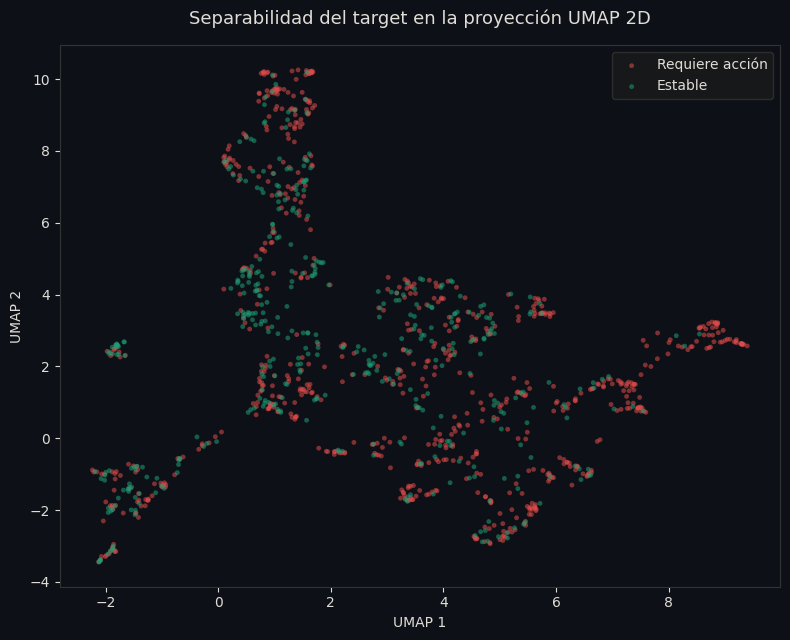


Silhouette del target sobre proyección UMAP 2D: 0.011
Nota: mide agrupamiento por distancia en el plano 2D, no la
capacidad de un clasificador para separar las clases.


In [26]:
# ── CELDA 16 — SEPARABILIDAD DEL TARGET (UMAP 2D) ────────────
# Proyección UMAP 2D del espacio de features del Modelo A, coloreada
# por el target. El silhouette se calcula SOBRE la proyección 2D: mide
# si las clases forman clusters separables por distancia en ese plano,
# NO es una prueba formal de (no) separabilidad en el espacio original.
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score

try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "umap-learn", "-q"])
    import umap

# Features reales del Modelo A (tipo_equipo codificada aparte).
# Usa criticidad_temporal, la misma que entra al modelo.
FEATURES_A_NUM = [
    "tbf_dias", "fallos_30_dias", "tbf_promedio_equipo", "tendencia_tbf",
    "criticidad_temporal", "edad_dias", "horas_parada_acumuladas", "fallos_90_dias",
    "tasa_fallo_equipo", "tbf_anterior",
]

COLORES_PERIODO = {"Requiere acción": "#E24B4A", "Estable": "#1D9E75"}

df_umap = df_modelo.copy()
df_umap["tipo_equipo_enc"] = LabelEncoder().fit_transform(df_umap["tipo_equipo"].astype(str))

VARS = FEATURES_A_NUM + ["tipo_equipo_enc"]
df_umap_a = df_umap[VARS + ["periodo_fallo"]].dropna().copy()

X_scaled = StandardScaler().fit_transform(df_umap_a[VARS].values)

print("Calculando UMAP 2D...")
X_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                 random_state=42, verbose=False).fit_transform(X_scaled)
print("UMAP 2D listo")

# ── Figura: UMAP 2D coloreado por target ─────────────────────
fig, ax = plt.subplots(figsize=(8, 6.5))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

for periodo, color in COLORES_PERIODO.items():
    mask = df_umap_a["periodo_fallo"] == periodo
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=12, c=color,
               alpha=0.55, edgecolors="none", label=periodo)

ax.set_xlabel("UMAP 1", color="#e0ddd6")
ax.set_ylabel("UMAP 2", color="#e0ddd6")
ax.set_title("Separabilidad del target en la proyección UMAP 2D",
             color="#e0ddd6", fontsize=13, pad=15)
ax.tick_params(colors="#e0ddd6")
for s in ax.spines.values():
    s.set_color("#333")
ax.legend(facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6", fontsize=10)
plt.tight_layout()
plt.savefig("separabilidad_umap.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Silhouette del target (sobre la proyección 2D) ───────────
labels = df_umap_a["periodo_fallo"].map({"Requiere acción": 0, "Estable": 1})
sil = silhouette_score(X_2d, labels)

print(f"\nSilhouette del target sobre proyección UMAP 2D: {sil:.3f}")
print("Nota: mide agrupamiento por distancia en el plano 2D, no la")
print("capacidad de un clasificador para separar las clases.")

# Bloque 3 — Modelado y entrenamiento.

Con el dataset limpio, las features construidas y el análisis exploratorio completado, se procede al entrenamiento del modelo predictivo. Este bloque implementa el Modelo A, un clasificador binario que predice la recurrencia temprana de fallas en dos clases: "Requiere acción" (el equipo probablemente volverá a fallar dentro del horizonte de 30 días) y "Estable".

La selección del clasificador no se fija a priori, sino que se fundamenta empíricamente. Primero se establece un baseline con DummyClassifier — un modelo trivial que predice siempre la clase más frecuente sin considerar ninguna feature — como punto de referencia mínimo que cualquier modelo útil debe superar. Luego se comparan, en igualdad de condiciones (mismo split, encoder y ponderación), cuatro modelos: el baseline, un modelo lineal (Regresión Logística) y dos no lineales (Random Forest y XGBoost).La Regresión Logística quedó por debajo de los modelos no lineales, lo que es consistente con una frontera de decisión no linealmente separable — coherente con el coeficiente de silueta prácticamente nulo (≈0.011) obtenido en el análisis de separabilidad del target. Random Forest y XGBoost resultaron estadísticamente equivalentes en desempeño —con Random Forest levemente por delante en recall de la clase crítica—; la elección final de XGBoost se sustenta en su mejor generalización, mayor estabilidad temporal y menor complejidad, priorizadas por tratarse de un modelo destinado a predecir fallas futuras.

El desbalanceo de clases se maneja mediante compute_sample_weight("balanced"), que asigna mayor peso a la clase minoritaria durante el entrenamiento sin modificar la distribución real del dataset — a diferencia de técnicas de sobremuestreo como SMOTE, que generan datos sintéticos.

La evaluación no se limita a una partición aleatoria: el modelo se valida además mediante validación temporal expansiva (walk-forward), que simula el uso real —predecir la recurrencia de cada año con el histórico acumulado previo— y constituye la estimación de desempeño más representativa de las condiciones de operación.

17. Baseline-DummyClassifier. Se establece el piso mínimo de rendimiento usando un DummyClassifier con estrategia most_frequent, que predice siempre la clase más frecuente independientemente de las features. El F1-macro del baseline es bajo porque la clase minoritaria queda con F1 = 0, lo que penaliza el promedio. Todo modelo que aprenda patrones reales debe superar significativamente este valor. El split y el encoder son idénticos a los del Modelo A (Celda 21) para garantizar comparabilidad.

In [27]:
# ── CELDA 17 — BASELINE (DummyClassifier) — SOLO MODELO A ─────
# Baseline del Modelo A: predice siempre la clase más frecuente, con las
# mismas features, filas y split que el Modelo A. Es el piso
# que cualquier modelo útil debe superar.
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import f1_score

# Mismas features y encoding que la Celda 21
df_base_a = df_modelo[FEATURES_A + [TARGET_PERIODO]].dropna().copy()
enc_base_a = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_base_a[FEATURES_A_CAT] = enc_base_a.fit_transform(df_base_a[FEATURES_A_CAT])
df_base_a[TARGET_PERIODO] = df_base_a[TARGET_PERIODO].map(MAPA_PERIODO)

X_a = df_base_a[FEATURES_A].values
y_a = df_base_a[TARGET_PERIODO].values
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.20, random_state=42, stratify=y_a
)

dummy_a      = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_a.fit(X_a_train, y_a_train)
f1_dummy_a   = f1_score(y_a_test, dummy_a.predict(X_a_test), average="macro")
clase_pred_a = clases_a[dummy_a.predict(X_a_test[:1])[0]]

# ── Resultados ─────────────────────────────────────────────────
print("  {:<10} {:<20} {:<25} {:>10}".format("Modelo", "Estrategia", "Clase predicha", "F1-macro"))
print("  " + "-" * 68)
print("  {:<10} {:<20} {:<25} {:>10}".format(
    "Modelo A", "most_frequent", clase_pred_a, round(f1_dummy_a, 3)))
print()
print("  El baseline predice siempre la clase más frecuente con las MISMAS")
print("  features, filas y split que el Modelo A (Celda 21).")
print("  Cualquier modelo útil debe superar ampliamente este valor.")

  Modelo     Estrategia           Clase predicha              F1-macro
  --------------------------------------------------------------------
  Modelo A   most_frequent        Requiere acción                0.389

  El baseline predice siempre la clase más frecuente con las MISMAS
  features, filas y split que el Modelo A (Celda 21).
  Cualquier modelo útil debe superar ampliamente este valor.


### 17A. Comparador lineal — Regresión Logística

Modelo lineal entrenado con la misma metodología que el Modelo A (mismo split, ponderación de clases y métrica), con estandarización previa de las features, que los modelos lineales requieren. Sirve como referencia para contrastar el desempeño de XGBoost frente a una frontera de decisión lineal: si un modelo lineal iguala a los no lineales, no se justificaría la mayor complejidad. Su desempeño inferior aporta evidencia empírica de que el problema no es linealmente separable.

In [28]:
# CELDA 17A── COMPARADOR LINEAL — LOGISTIC REGRESSION ──────────────────
# Modelo lineal con la MISMA metodología que el Modelo A (mismo split,
# mismo sample_weight, misma métrica).
# Usa X_a_train, X_a_test, y_a_train, y_a_test,
# con el mismo split que el Modelo A. La comparación contra XGBoost se hace más adelante.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

# Logistic necesita escalado (los modelos lineales sí lo requieren)
scaler_lr = StandardScaler()
X_a_train_s = scaler_lr.fit_transform(X_a_train)
X_a_test_s  = scaler_lr.transform(X_a_test)

# Mismo sample_weight balanceado que el Modelo A
pesos_lr = compute_sample_weight("balanced", y_a_train)

# Entrenar
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_a_train_s, y_a_train, sample_weight=pesos_lr)

# Evaluar
y_lr_pred       = modelo_lr.predict(X_a_test_s)
y_lr_pred_train = modelo_lr.predict(X_a_train_s)

f1_lr       = f1_score(y_a_test,  y_lr_pred,       average="macro")
f1_lr_train = f1_score(y_a_train, y_lr_pred_train, average="macro")
f1_lr_clase = f1_score(y_a_test,  y_lr_pred,       average=None)
gap_lr      = f1_lr_train - f1_lr

# ── Resultados ─────────────────────────────────────────────────
print("=" * 48)
print("  MODELO LINEAL — LOGISTIC REGRESSION")
print("=" * 48)
print(f"\n  F1-macro TEST  : {f1_lr:.3f}")
print(f"  F1-macro TRAIN : {f1_lr_train:.3f}")
print(f"  Gap (train-test): {gap_lr:+.3f}")
print(f"\n  F1 por clase (test):")
for clase, val in zip(clases_a, f1_lr_clase):
    print(f"    {clase:<18} {val:.3f}")

  MODELO LINEAL — LOGISTIC REGRESSION

  F1-macro TEST  : 0.647
  F1-macro TRAIN : 0.624
  Gap (train-test): -0.023

  F1 por clase (test):
    Requiere acción    0.677
    Estable            0.617


###17B. Comparador no lineal — Random Forest

Modelo no lineal entrenado con la misma metodología que el Modelo A (mismo split, ponderación de clases y métrica), sin estandarización, que los modelos basados en árboles no requieren. Se emplea con parámetros regularizados (profundidad y hojas mínimas acotadas) para una comparación justa frente a XGBoost. Al ser un método no lineal distinto (bagging frente al boosting de XGBoost), permite verificar si la ventaja sobre los modelos lineales es propia de XGBoost o común a los enfoques no lineales, y sirve como contraste directo en la selección final del modelo.

In [29]:
# CELDA 17B── COMPARADOR — RANDOM FOREST ───────────────────────────────
# Random Forest con la MISMA metodología que el Modelo A (mismo split,
# mismo sample_weight, misma métrica). No necesita escalado.
# Usa X_a_train, X_a_test, y_a_train, y_a_test
# con el mismo split que el Modelo A. La comparación contra XGBoost se hace más adelante.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

# Mismo sample_weight balanceado que el Modelo A
pesos_rf = compute_sample_weight("balanced", y_a_train)

# Parámetros conservadores (regularizados, coherente con tu enfoque)
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
modelo_rf.fit(X_a_train, y_a_train, sample_weight=pesos_rf)

# Evaluar
y_rf_pred       = modelo_rf.predict(X_a_test)
y_rf_pred_train = modelo_rf.predict(X_a_train)

f1_rf       = f1_score(y_a_test,  y_rf_pred,       average="macro")
f1_rf_train = f1_score(y_a_train, y_rf_pred_train, average="macro")
f1_rf_clase = f1_score(y_a_test,  y_rf_pred,       average=None)
gap_rf      = f1_rf_train - f1_rf

# ── Resultados ─────────────────────────────────────────────────
print("=" * 48)
print("  RANDOM FOREST")
print("=" * 48)
print(f"\n  F1-macro TEST  : {f1_rf:.3f}")
print(f"  F1-macro TRAIN : {f1_rf_train:.3f}")
print(f"  Gap (train-test): {gap_rf:+.3f}")
print(f"\n  F1 por clase (test):")
for clase, val in zip(clases_a, f1_rf_clase):
    print(f"    {clase:<18} {val:.3f}")
print()
print(classification_report(y_a_test, y_rf_pred, target_names=clases_a, digits=3))

  RANDOM FOREST

  F1-macro TEST  : 0.658
  F1-macro TRAIN : 0.704
  Gap (train-test): +0.047

  F1 por clase (test):
    Requiere acción    0.713
    Estable            0.602

                 precision    recall  f1-score   support

Requiere acción      0.789     0.651     0.713       149
        Estable      0.532     0.694     0.602        85

       accuracy                          0.667       234
      macro avg      0.660     0.673     0.658       234
   weighted avg      0.695     0.667     0.673       234



In [30]:
# CELDA 17C
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, make_scorer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import numpy as np

SEMILLA, N_ITER = 42, 25

PARAM_DIST_A = {
    "max_depth":        [2, 3, 4],
    "learning_rate":    [0.03, 0.05, 0.1],
    "n_estimators":     [150, 200, 300],
    "min_child_weight": [3, 5, 7],
    "reg_lambda":       [1.0, 2.0, 3.0],
}

# ── 1. Split idéntico al del Modelo A ─────────────────────────────────
df_hp = df_modelo[FEATURES_A + [TARGET_PERIODO]].dropna().copy()
enc_hp = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_hp[FEATURES_A_CAT] = enc_hp.fit_transform(df_hp[FEATURES_A_CAT])
df_hp[TARGET_PERIODO] = df_hp[TARGET_PERIODO].map(MAPA_PERIODO)

X_hp_all, y_hp_all = df_hp[FEATURES_A].values, df_hp[TARGET_PERIODO].values
X_hp, _, y_hp, _ = train_test_split(
    X_hp_all, y_hp_all, test_size=0.20, random_state=SEMILLA, stratify=y_hp_all,
)
pesos_hp = compute_sample_weight("balanced", y_hp)

# ── 2. Búsqueda aleatoria ─────────────────────────────────────────────
f1_macro = make_scorer(f1_score, average="macro")
cv_hp = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

base_hp = XGBClassifier(
    subsample=XGB_PARAMS_A["subsample"],
    colsample_bytree=XGB_PARAMS_A["colsample_bytree"],
    reg_alpha=XGB_PARAMS_A["reg_alpha"],
    eval_metric="logloss", random_state=SEMILLA, n_jobs=-1,
)

busqueda_a = RandomizedSearchCV(
    estimator=base_hp, param_distributions=PARAM_DIST_A,
    n_iter=N_ITER, scoring=f1_macro, cv=cv_hp,
    random_state=SEMILLA, n_jobs=-1, refit=False, return_train_score=True,
)
busqueda_a.fit(X_hp, y_hp, sample_weight=pesos_hp)

# ── 3. Configuración vigente bajo el mismo protocolo ──────────────────
def cv_f1_hp(params):
    s = []
    for tr, va in cv_hp.split(X_hp, y_hp):
        m = XGBClassifier(**params)
        m.fit(X_hp[tr], y_hp[tr], sample_weight=pesos_hp[tr])
        s.append(f1_score(y_hp[va], m.predict(X_hp[va]), average="macro"))
    return float(np.mean(s)), float(np.std(s))

f1_vig, sd_vig = cv_f1_hp(XGB_PARAMS_A)
mejores  = busqueda_a.best_params_
f1_mejor = float(busqueda_a.best_score_)
n_comb   = int(np.prod([len(v) for v in PARAM_DIST_A.values()]))

# ── 4. Reporte ────────────────────────────────────────────────────────
print("=" * 68)
print("  BUSQUEDA DE HIPERPARAMETROS - MODELO A")
print("=" * 68)
print("  Metodo     : RandomizedSearchCV ({} de {} combinaciones)".format(N_ITER, n_comb))
print("  Validacion : StratifiedKFold(5, shuffle=True, seed={})".format(SEMILLA))
print("  Metrica    : F1-macro")
print("  Ponderacion: compute_sample_weight('balanced')")
print("  N train    : {}".format(len(y_hp)))
print("-" * 68)
print("  {:<18} {:>10} {:>10}".format("Hiperparametro", "Vigente", "Busqueda"))
print("  " + "-" * 40)
for k in PARAM_DIST_A:
    print("  {:<18} {:>10} {:>10}".format(k, str(XGB_PARAMS_A[k]), str(mejores[k])))
print("-" * 68)
print("  F1-macro CV configuracion vigente : {:.4f} (sd {:.4f})".format(f1_vig, sd_vig))
print("  F1-macro CV mejor de la busqueda  : {:.4f}".format(f1_mejor))
print("-" * 68)
if all(XGB_PARAMS_A[k] == mejores[k] for k in PARAM_DIST_A):
    print("  La busqueda reproduce la configuracion vigente.")
else:
    print("  Diferencia en F1-macro CV: {:+.4f}".format(f1_mejor - f1_vig))
print("=" * 68)

  BUSQUEDA DE HIPERPARAMETROS - MODELO A
  Metodo     : RandomizedSearchCV (25 de 243 combinaciones)
  Validacion : StratifiedKFold(5, shuffle=True, seed=42)
  Metrica    : F1-macro
  Ponderacion: compute_sample_weight('balanced')
  N train    : 934
--------------------------------------------------------------------
  Hiperparametro        Vigente   Busqueda
  ----------------------------------------
  max_depth                   2          2
  learning_rate            0.03       0.03
  n_estimators              150        150
  min_child_weight            5          7
  reg_lambda                1.0        2.0
--------------------------------------------------------------------
  F1-macro CV configuracion vigente : 0.6256 (sd 0.0542)
  F1-macro CV mejor de la busqueda  : 0.6311
--------------------------------------------------------------------
  Diferencia en F1-macro CV: +0.0055


In [31]:
#PRUEBA CELDA 17D── COMPARADOR — CATBOOST ────────────────────────────────────
# CatBoost con la MISMA metodología que el Modelo A (mismo split,
# mismo sample_weight, misma métrica). Usa X_a_train, X_a_test,
# y_a_train, y_a_test de la Celda 18. tipo_equipo entra ya codificada
# por el OrdinalEncoder, igual que la ve XGBoost.
try:
    from catboost import CatBoostClassifier
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "catboost", "-q"])
    from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

pesos_cat = compute_sample_weight("balanced", y_a_train)

modelo_cat = CatBoostClassifier(
    iterations=150,
    depth=2,
    learning_rate=0.03,
    l2_leaf_reg=1.0,
    random_seed=42,
    verbose=0,
)
modelo_cat.fit(X_a_train, y_a_train, sample_weight=pesos_cat)

y_cat_pred       = modelo_cat.predict(X_a_test)
y_cat_pred_train = modelo_cat.predict(X_a_train)

f1_cat       = f1_score(y_a_test,  y_cat_pred,       average="macro")
f1_cat_train = f1_score(y_a_train, y_cat_pred_train, average="macro")
f1_cat_clase = f1_score(y_a_test,  y_cat_pred,       average=None)
gap_cat      = f1_cat_train - f1_cat

print("=" * 48)
print("  CATBOOST")
print("=" * 48)
print(f"\n  F1-macro TEST  : {f1_cat:.3f}")
print(f"  F1-macro TRAIN : {f1_cat_train:.3f}")
print(f"  Gap (train-test): {gap_cat:+.3f}")
print(f"\n  F1 por clase (test):")
for clase, val in zip(clases_a, f1_cat_clase):
    print(f"    {clase:<18} {val:.3f}")
print()
print(classification_report(y_a_test, y_cat_pred, target_names=clases_a, digits=3))

  CATBOOST

  F1-macro TEST  : 0.643
  F1-macro TRAIN : 0.662
  Gap (train-test): +0.020

  F1 por clase (test):
    Requiere acción    0.692
    Estable            0.594

                 precision    recall  f1-score   support

Requiere acción      0.786     0.617     0.692       149
        Estable      0.513     0.706     0.594        85

       accuracy                          0.650       234
      macro avg      0.650     0.662     0.643       234
   weighted avg      0.687     0.650     0.656       234



In [32]:
#PRUEBA ── CELDA 18-CAT — Prueba CatBoost (misma tubería que Modelo A) ──
import subprocess
subprocess.run(["pip", "install", "catboost", "--quiet"], capture_output=True)
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, recall_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

# CatBoost equiparado a XGB_PARAMS_A: mismos cuatro knobs centrales.
# subsample/rsm replican subsample/colsample; min_child_weight no mapea limpio.
CAT_PARAMS_A = dict(
    iterations=150, depth=2, learning_rate=0.03,
    l2_leaf_reg=1.0, subsample=0.7, rsm=0.7,
    bootstrap_type="Bernoulli", random_seed=42, verbose=0,
)

df_c = df_modelo[FEATURES_A + [TARGET_PERIODO]].dropna().copy()
enc_c = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_c[FEATURES_A_CAT] = enc_c.fit_transform(df_c[FEATURES_A_CAT])
df_c[TARGET_PERIODO] = df_c[TARGET_PERIODO].map(MAPA_PERIODO)

X_c, y_c = df_c[FEATURES_A].values, df_c[TARGET_PERIODO].values
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_c, y_c, test_size=0.20, random_state=42, stratify=y_c,
)
pesos_c = compute_sample_weight("balanced", y_c_tr)

modelo_c = CatBoostClassifier(**CAT_PARAMS_A)
modelo_c.fit(X_c_tr, y_c_tr, sample_weight=pesos_c)
col_ra = list(modelo_c.classes_).index(0)

# Umbral óptimo out-of-fold sobre train (idéntico a la Celda 18)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(y_c_tr))
for tr_idx, va_idx in skf.split(X_c_tr, y_c_tr):
    w_tmp = compute_sample_weight("balanced", y_c_tr[tr_idx])
    m_tmp = CatBoostClassifier(**CAT_PARAMS_A)
    m_tmp.fit(X_c_tr[tr_idx], y_c_tr[tr_idx], sample_weight=w_tmp)
    c_tmp = list(m_tmp.classes_).index(0)
    oof[va_idx] = m_tmp.predict_proba(X_c_tr[va_idx])[:, c_tmp]

umbrales = np.linspace(0.30, 0.70, 41)
f1_thr = [f1_score(y_c_tr, np.where(oof >= t, 0, 1), average="macro") for t in umbrales]
mejor_thr = float(umbrales[int(np.argmax(f1_thr))])

p_te = np.where(modelo_c.predict_proba(X_c_te)[:, col_ra] >= mejor_thr, 0, 1)
p_tr = np.where(modelo_c.predict_proba(X_c_tr)[:, col_ra] >= mejor_thr, 0, 1)

f1_te = f1_score(y_c_te, p_te, average="macro")
f1_tr = f1_score(y_c_tr, p_tr, average="macro")
rec_c = recall_score(y_c_te, p_te, pos_label=0)

print("CatBoost | umbral {:.3f}".format(mejor_thr))
print("  F1-macro test  : {:.4f}".format(f1_te))
print("  Recall crítico : {:.4f}".format(rec_c))
print("  Gap train-test : {:.4f}".format(f1_tr - f1_te))

CatBoost | umbral 0.510
  F1-macro test  : 0.6437
  Recall crítico : 0.6107
  Gap train-test : 0.0048


### 18. Modelo A — Periodo de fallo.

Se entrena el Modelo A con XGBoost para clasificar el periodo de fallo de forma **binaria**: "Requiere acción" (el equipo vuelve a fallar dentro de los 30 días siguientes, `tbf_siguiente ≤ 30`) frente a "Estable". Las features de mayor peso corresponden al ritmo reciente de fallos y al historial del equipo (fallos en ventanas recientes, TBF promedio y tasa de fallo), lo que confirma que la actividad reciente de fallos es la señal más predictiva de urgencia. La criticidad empleada es la versión temporal (sin fuga entre años) y se ubica entre las variables de menor importancia, lo que indica que el desempeño no depende de ella. Se aplica `compute_sample_weight("balanced")` para compensar el desbalance del target sin generar datos sintéticos. El punto de operación se fija mediante un umbral de decisión ajustado sobre el conjunto de entrenamiento; este ajuste constituye una calibración del punto de decisión, no una mejora de desempeño respecto al umbral por defecto. Al finalizar se exportan el modelo, el encoder y el mapa de clases para su uso posterior.

Hiperparámetros Modelo A (Celda 1): max_depth = 2 | lr = 0.03 | n_est = 150 | reg_lambda = 1.0
Split Modelo A:
  Train : 934 registros
  Test  : 234 registros
  Clases: 2
  Orden de clases: [0 1] → 'Requiere acción' en col 0
  Umbral óptimo (train OOF, F1-macro): 0.480
  F1-macro corte 0.50   : 0.651
  F1-macro corte 0.48   : 0.651
  Verificación sobreentrenamiento — Modelo A
  F1-macro TRAIN : 0.681
  F1-macro TEST  : 0.651
  Gap train-test : 0.030
  Gap < 0.05: modelo generaliza bien


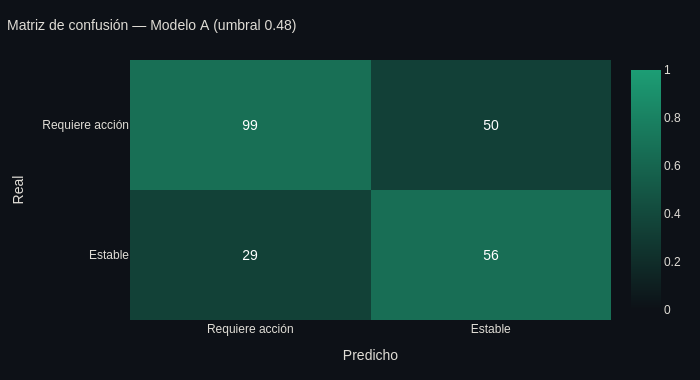

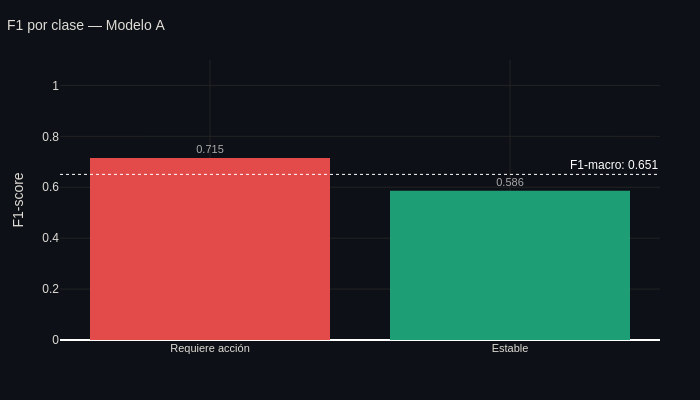

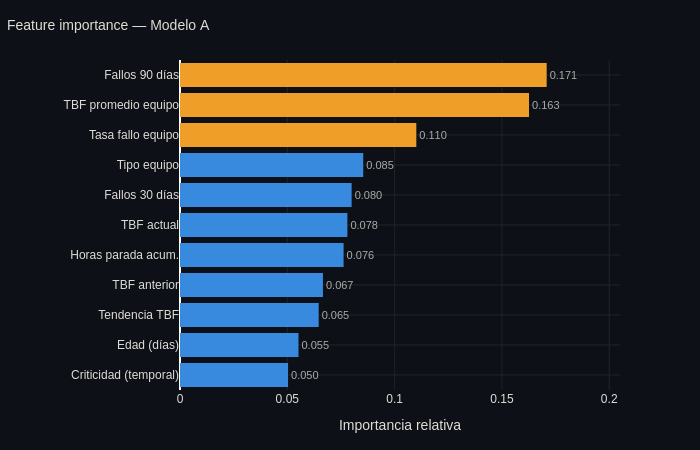

  MODELO A — resultado final
  Umbral de decisión : 0.480
  F1-macro TEST      : 0.651
  F1-macro (0.50 ref): 0.651
  F1-macro TRAIN     : 0.681
  Gap                : 0.030

  F1 por clase:
    Requiere acción        0.715
    Estable                0.586

                 precision    recall  f1-score   support

Requiere acción      0.773     0.664     0.715       149
        Estable      0.528     0.659     0.586        85

       accuracy                          0.662       234
      macro avg      0.651     0.662     0.651       234
   weighted avg      0.684     0.662     0.668       234



In [33]:
# ── CELDA 18 — MODELO A (binario, target hacia adelante + umbral óptimo) ──
import subprocess
subprocess.run(["pip", "install", "kaleido==0.2.1", "--quiet"], capture_output=True)
import kaleido
import plotly.io as pio
pio.renderers.default = "png"
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight
import plotly.graph_objects as go
import joblib, os
import numpy as np

os.makedirs("/content/artefactos", exist_ok=True)

# FEATURES_A, MAPA_PERIODO, clases_a, NOMBRES_A y XGB_PARAMS_A vienen
# de la Celda 1. No se redefinen aquí.
COLORES_3 = COLORES_A

print("Hiperparámetros Modelo A (Celda 1):",
      "max_depth =", XGB_PARAMS_A["max_depth"],
      "| lr =", XGB_PARAMS_A["learning_rate"],
      "| n_est =", XGB_PARAMS_A["n_estimators"],
      "| reg_lambda =", XGB_PARAMS_A["reg_lambda"])

# ── 2. Preparar X e y ─────────────────────────────────────────
df_a = df_modelo[FEATURES_A + [TARGET_PERIODO]].dropna().copy()
enc_a = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_a[FEATURES_A_CAT] = enc_a.fit_transform(df_a[FEATURES_A_CAT])
df_a[TARGET_PERIODO] = df_a[TARGET_PERIODO].map(MAPA_PERIODO)

X_a = df_a[FEATURES_A].values
y_a = df_a[TARGET_PERIODO].values

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.20, random_state=42, stratify=y_a,
)
pesos_a = compute_sample_weight("balanced", y_a_train)

print("Split Modelo A:")
print("  Train : {} registros".format(len(X_a_train)))
print("  Test  : {} registros".format(len(X_a_test)))
print("  Clases: {}".format(len(np.unique(y_a_train))))

# ── 3. Entrenar modelo final ──────────────────────────────────
modelo_a = XGBClassifier(**XGB_PARAMS_A)
modelo_a.fit(X_a_train, y_a_train, sample_weight=pesos_a)

col_ra = list(modelo_a.classes_).index(0)
print("  Orden de clases:", modelo_a.classes_, "→ 'Requiere acción' en col", col_ra)

# ── 3b. Umbral óptimo sobre ENTRENAMIENTO (out-of-fold) ───────
skf_thr   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = np.zeros(len(y_a_train))
for tr_idx, va_idx in skf_thr.split(X_a_train, y_a_train):
    w_tmp = compute_sample_weight("balanced", y_a_train[tr_idx])
    m_tmp = XGBClassifier(**XGB_PARAMS_A)
    m_tmp.fit(X_a_train[tr_idx], y_a_train[tr_idx], sample_weight=w_tmp)
    c_tmp = list(m_tmp.classes_).index(0)
    oof_proba[va_idx] = m_tmp.predict_proba(X_a_train[va_idx])[:, c_tmp]

umbrales = np.linspace(0.30, 0.70, 41)
f1_por_thr = np.array([
    f1_score(y_a_train, np.where(oof_proba >= t, 0, 1), average="macro")
    for t in umbrales
])
mejor_thr = float(umbrales[int(np.argmax(f1_por_thr))])
print("  Umbral óptimo (train OOF, F1-macro): {:.3f}".format(mejor_thr))

# ── 3c. Predicciones finales con el umbral fijo ───────────────
probs_test  = modelo_a.predict_proba(X_a_test)[:, col_ra]
probs_train = modelo_a.predict_proba(X_a_train)[:, col_ra]

y_a_pred       = np.where(probs_test  >= mejor_thr, 0, 1)
y_a_pred_train = np.where(probs_train >= mejor_thr, 0, 1)
y_a_pred_05    = modelo_a.predict(X_a_test)

f1_a       = f1_score(y_a_test,  y_a_pred,       average="macro")
f1_a_05    = f1_score(y_a_test,  y_a_pred_05,    average="macro")
f1_a_train = f1_score(y_a_train, y_a_pred_train, average="macro")
f1_a_clase = f1_score(y_a_test,  y_a_pred,       average=None)
cm_a       = confusion_matrix(y_a_test, y_a_pred)
cm_a_norm  = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)

print("  F1-macro corte 0.50   : {:.3f}".format(f1_a_05))
print("  F1-macro corte {:.2f}   : {:.3f}".format(mejor_thr, f1_a))

# ── 4. Verificación sobreentrenamiento ────────────────────────
gap_a = f1_a_train - f1_a
print("=" * 55)
print("  Verificación sobreentrenamiento — Modelo A")
print("=" * 55)
print("  F1-macro TRAIN : {:.3f}".format(f1_a_train))
print("  F1-macro TEST  : {:.3f}".format(f1_a))
print("  Gap train-test : {:.3f}".format(gap_a))
if gap_a > 0.10:
    print("  Gap > 0.10: sobreentrenamiento")
elif gap_a > 0.05:
    print("  Gap 0.05-0.10: leve, aceptable")
else:
    print("  Gap < 0.05: modelo generaliza bien")

# ── 5. Matriz de confusión ────────────────────────────────────
n = len(clases_a)
fig1 = go.Figure(go.Heatmap(
    z=cm_a_norm, x=clases_a, y=clases_a,
    colorscale=[[0, "#0d1117"], [1, "#1D9E75"]],
    text=[[str(cm_a[i][j]) for j in range(n)] for i in range(n)],
    texttemplate="%{text}", textfont=dict(size=14, color="#ffffff"),
    showscale=True, zmin=0, zmax=1,
))
fig1.update_layout(
    title=dict(text="Matriz de confusión — Modelo A (umbral {:.2f})".format(mejor_thr),
               font=dict(size=14, color="#e0ddd6", family="Arial"), x=0.01),
    xaxis=dict(title="Predicho", tickfont=dict(color="#e0ddd6"), gridcolor="#222222"),
    yaxis=dict(title="Real", tickfont=dict(color="#e0ddd6"),
               gridcolor="#222222", autorange="reversed"),
    paper_bgcolor="#0d1117", plot_bgcolor="#0d1117",
    font=dict(color="#e0ddd6", family="Arial"),
    height=380, margin=dict(t=60, b=60, l=130, r=40),
)
fig1.show()

# ── 6. F1 por clase ───────────────────────────────────────────
fig2 = go.Figure(go.Bar(
    x=clases_a, y=f1_a_clase, marker_color=COLORES_3, marker_line_width=0,
    text=["{:.3f}".format(v) for v in f1_a_clase],
    textposition="outside", textfont=dict(size=11, color="#aaaaaa"),
))
fig2.add_hline(y=f1_a, line_dash="dot", line_color="#ffffff", line_width=1,
    annotation_text="F1-macro: {:.3f}".format(f1_a),
    annotation_font_color="#ffffff", annotation_position="top right")
fig2.update_layout(
    title=dict(text="F1 por clase — Modelo A",
               font=dict(size=14, color="#e0ddd6", family="Arial"), x=0.01),
    xaxis=dict(tickfont=dict(color="#e0ddd6", size=11), gridcolor="#222222"),
    yaxis=dict(gridcolor="#222222", range=[0, 1.1], title="F1-score",
               tickfont=dict(color="#e0ddd6")),
    paper_bgcolor="#0d1117", plot_bgcolor="#0d1117",
    font=dict(color="#e0ddd6", family="Arial"),
    height=400, margin=dict(t=60, b=60, l=60, r=40),
)
fig2.show()

# ── 7. Feature importance ─────────────────────────────────────
imp_a     = modelo_a.feature_importances_
orden_a   = np.argsort(imp_a)[::-1]
names_ord = [NOMBRES_A.get(FEATURES_A[i], FEATURES_A[i]) for i in orden_a]
imp_ord   = imp_a[orden_a]
COLORES_IMP = ["#1D9E75" if v >= 0.20 else "#EF9F27" if v >= 0.10 else "#378ADD"
               for v in imp_ord]
fig3 = go.Figure(go.Bar(
    x=imp_ord, y=names_ord, orientation="h",
    marker_color=COLORES_IMP, marker_line_width=0,
    text=["{:.3f}".format(v) for v in imp_ord],
    textposition="outside", textfont=dict(size=11, color="#aaaaaa"),
))
fig3.update_layout(
    title=dict(text="Feature importance — Modelo A",
               font=dict(size=14, color="#e0ddd6", family="Arial"), x=0.01),
    xaxis=dict(title="Importancia relativa", gridcolor="#222222",
               range=[0, max(imp_ord) * 1.2], tickfont=dict(color="#e0ddd6")),
    yaxis=dict(gridcolor="#222222", tickfont=dict(color="#e0ddd6", size=12),
               autorange="reversed"),
    paper_bgcolor="#0d1117", plot_bgcolor="#0d1117",
    font=dict(color="#e0ddd6", family="Arial"),
    height=450, margin=dict(t=60, b=60, l=180, r=80),
)
fig3.show()

# ── 8. Exportar artefactos ────────────────────────────────────
modelo_a.save_model("/content/artefactos/modelo_a.ubj")
joblib.dump(enc_a,        "/content/artefactos/enc_a.pkl")
joblib.dump(MAPA_PERIODO, "/content/artefactos/mapa_periodo.pkl")
joblib.dump(mejor_thr,    "/content/artefactos/umbral_a.pkl")

# ── 9. Resumen ────────────────────────────────────────────────
print("=" * 55)
print("  MODELO A — resultado final")
print("=" * 55)
print("  Umbral de decisión : {:.3f}".format(mejor_thr))
print("  F1-macro TEST      : {:.3f}".format(f1_a))
print("  F1-macro (0.50 ref): {:.3f}".format(f1_a_05))
print("  F1-macro TRAIN     : {:.3f}".format(f1_a_train))
print("  Gap                : {:.3f}".format(gap_a))
print()
print("  F1 por clase:")
for nombre, val in zip(clases_a, f1_a_clase):
    print("    {:<22} {:.3f}".format(nombre, val))
print()
print(classification_report(y_a_test, y_a_pred, target_names=clases_a, digits=3))

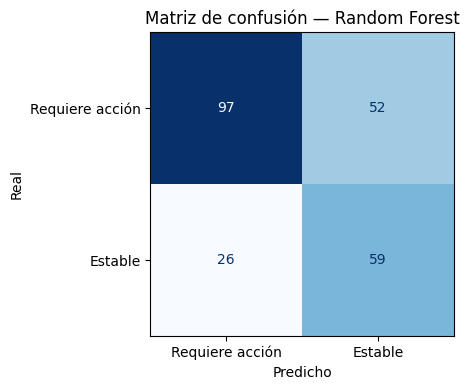

Soporte por clase (y_a_test):
  Requiere acción    149
  Estable            85

F1-macro (RF, test): 0.658

                 precision    recall  f1-score   support

Requiere acción      0.789     0.651     0.713       149
        Estable      0.532     0.694     0.602        85

       accuracy                          0.667       234
      macro avg      0.660     0.673     0.658       234
   weighted avg      0.695     0.667     0.673       234



In [34]:
# ── CELDA 18B — MATRIZ DE CONFUSIÓN — RANDOM FOREST ───────────
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)

ORDEN = [MAPA_PERIODO[c] for c in clases_a]

cm_rf = confusion_matrix(y_a_test, y_rf_pred, labels=ORDEN)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_rf, display_labels=clases_a).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Random Forest")
plt.tight_layout()
plt.savefig("matriz_confusion_rf.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

print("Soporte por clase (y_a_test):")
for c, n in zip(clases_a, cm_rf.sum(axis=1)):
    print(f"  {c:<18} {n}")

print(f"\nF1-macro (RF, test): {f1_score(y_a_test, y_rf_pred, average='macro'):.3f}\n")
print(classification_report(y_a_test, y_rf_pred,
                            labels=ORDEN, target_names=clases_a, digits=3))

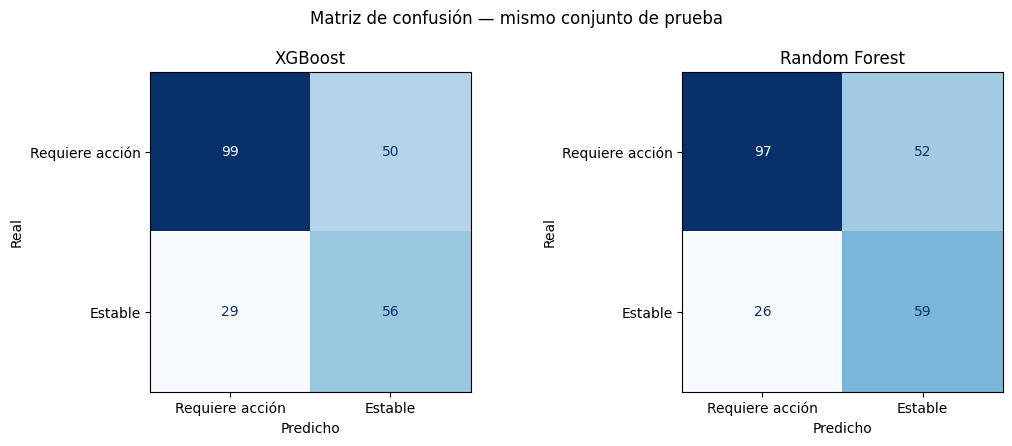

Clase 'Requiere acción' — casos reales: 149
  XGBoost        detectados 99/149  recall = 0.664  F1-macro = 0.651
  Random Forest  detectados 97/149  recall = 0.651  F1-macro = 0.658

Acuerdo entre modelos: 91.9%


In [35]:
# ── CELDA 18C — COMPARATIVA DE MATRICES DE CONFUSIÓN ──────────
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

ORDEN    = [MAPA_PERIODO[c] for c in clases_a]
IDX_CRIT = clases_a.index("Requiere acción")

cm_xgb = confusion_matrix(y_a_test, y_a_pred,  labels=ORDEN)
cm_rf  = confusion_matrix(y_a_test, y_rf_pred, labels=ORDEN)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, nombre in [(axes[0], cm_xgb, "XGBoost"),
                       (axes[1], cm_rf,  "Random Forest")]:
    ConfusionMatrixDisplay(cm, display_labels=clases_a).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(nombre)
fig.suptitle("Matriz de confusión — mismo conjunto de prueba")
plt.tight_layout()
plt.savefig("matriz_confusion_comparativa.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

n_crit = cm_xgb[IDX_CRIT].sum()
print(f"Clase '{clases_a[IDX_CRIT]}' — casos reales: {n_crit}")
for nombre, cm, y_pred in [("XGBoost", cm_xgb, y_a_pred),
                           ("Random Forest", cm_rf, y_rf_pred)]:
    tp = cm[IDX_CRIT, IDX_CRIT]
    print(f"  {nombre:<14} detectados {tp}/{n_crit}  "
          f"recall = {tp / n_crit:.3f}  "
          f"F1-macro = {f1_score(y_a_test, y_pred, average='macro'):.3f}")

print(f"\nAcuerdo entre modelos: {(y_rf_pred == y_a_pred).mean()*100:.1f}%")

### 19. Comparativa de modelos — selección del Modelo A

Compara los cuatro modelos (baseline, Regresión Logística, Random Forest y
XGBoost) sobre el mismo conjunto de prueba y a umbral por defecto, para una
comparación justa. Todos los modelos con aprendizaje real superan ampliamente
el baseline. La Regresión Logística queda por debajo de los no lineales,
aunque por un margen reducido, lo que es consistente con una frontera de
decisión no linealmente separable. Random Forest y XGBoost quedan en empate
técnico, con una diferencia inferior al margen de ruido definido para un
conjunto de prueba de este tamaño. Esta celda no resuelve la elección: la
establece como un empate que se dirime en la validación temporal y en los
criterios de generalización, estabilidad y parsimonia.

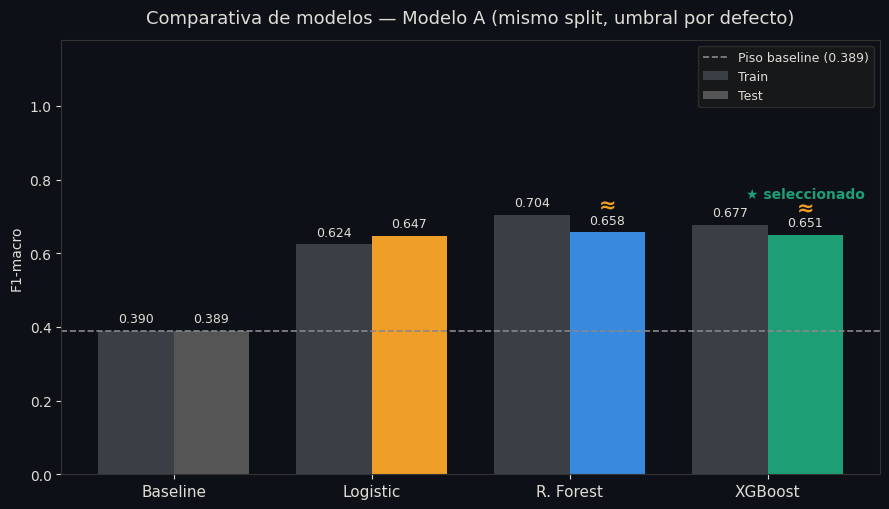

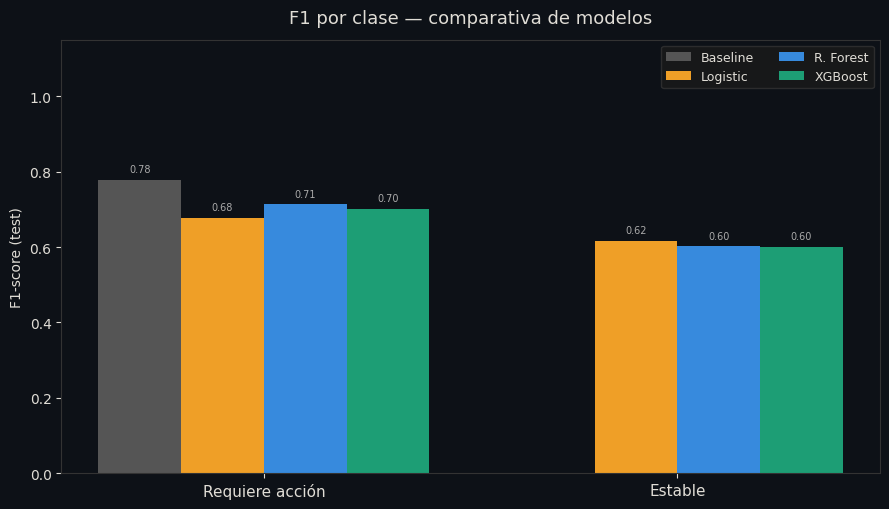

  COMPARATIVA DE MODELOS — MODELO A (test, umbral por defecto)
  Modelo      F1 train  F1 test      Gap  Rec.Crít.   F1 por clase
  ----------------------------------------------------------------------
  R. Forest      0.704    0.658   +0.047      0.651   Requiere acc=0.71  Estable=0.60  ≈
  XGBoost        0.677    0.651   +0.027      0.631   Requiere acc=0.70  Estable=0.60  ★
  Logistic       0.624    0.647   -0.023      0.577   Requiere acc=0.68  Estable=0.62
  Baseline       0.390    0.389   +0.001      1.000   Requiere acc=0.78  Estable=0.00
  ----------------------------------------------------------------------
  Regla de selección:
    empate técnico en F1-macro entre R. Forest, XGBoost (Δ ≤ 0.010); se elige por menor gap train-test (mejor generalización)
  Modelo seleccionado: XGBoost
    F1-macro test : 0.651
    Recall 'Requiere acción' : 0.631
    Gap train-test: +0.027  (menor |gap| = mejor generalización)
  El modelo seleccionado pasa a validación temporal expansiva, que


In [36]:
# ── CELDA 19 — COMPARATIVA DE LOS 4 MODELOS — SELECCIÓN DEL GANADOR ──
# Compara baseline, Logistic Regression, Random Forest y XGBoost en
# IGUALDAD de condiciones (mismo split, mismo test, umbral por defecto).
# Regla de selección:
#   1) Primaria   : F1-macro en test.
#   2) Si dos o más modelos quedan dentro de EMPATE_MARGEN => empate técnico
#      (diferencia no distinguible del ruido en un test de este tamaño).
#   3) Secundaria : en caso de empate, gana el MAYOR recall en la clase
#      crítica "Requiere acción" (prioridad operacional: no dejar pasar
#      equipos que van a fallar). El gap train-test se reporta como apoyo.
# La validación temporal posterior confirma/desempata esta elección.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, recall_score

EMPATE_MARGEN = 0.010
CLASE_CRITICA = "Requiere acción"
LABEL_CRITICA = MAPA_PERIODO[CLASE_CRITICA]      # = 0

# ── 1. Predicciones en igualdad de condiciones (umbral por defecto) ──
maj = np.bincount(y_a_train).argmax()

pred_test = {
    "Baseline":  np.full_like(y_a_test,  maj),
    "Logistic":  modelo_lr.predict(X_a_test_s),
    "R. Forest": modelo_rf.predict(X_a_test),
    "XGBoost":   modelo_a.predict(X_a_test),
}
pred_train = {
    "Baseline":  np.full_like(y_a_train, maj),
    "Logistic":  modelo_lr.predict(X_a_train_s),
    "R. Forest": modelo_rf.predict(X_a_train),
    "XGBoost":   modelo_a.predict(X_a_train),
}

modelos  = list(pred_test.keys())
f1_test  = {m: f1_score(y_a_test,  pred_test[m],  average="macro") for m in modelos}
f1_train = {m: f1_score(y_a_train, pred_train[m], average="macro") for m in modelos}
f1_clase = {m: f1_score(y_a_test,  pred_test[m],  average=None)    for m in modelos}
gap      = {m: f1_train[m] - f1_test[m] for m in modelos}
rec_crit = {m: recall_score(y_a_test, pred_test[m], pos_label=LABEL_CRITICA,
                            zero_division=0) for m in modelos}

# ── 2. Selección con manejo de empate técnico ────────────────────────
mejor_f1   = max(f1_test.values())
empatados  = [m for m in modelos if mejor_f1 - f1_test[m] <= EMPATE_MARGEN]

if len(empatados) == 1:
    seleccionado = empatados[0]
    motivo = "mayor F1-macro (diferencia sobre el resto > {:.3f})".format(EMPATE_MARGEN)
    hay_empate = False
else:
    # Empate técnico en F1-macro: se decide por MENOR gap train-test
    # (mejor generalización), criterio prioritario para un modelo que debe
    # predecir fallas futuras. La estabilidad temporal se confirma en la
    # validación expansiva posterior.
    seleccionado = min(empatados, key=lambda m: gap[m])
    hay_empate = True
    motivo = ("empate técnico en F1-macro entre {} (Δ ≤ {:.3f}); "
              "se elige por menor gap train-test (mejor generalización)"
              .format(", ".join(empatados), EMPATE_MARGEN))

COLOR_MOD = {"Baseline": "#555555", "Logistic": "#EF9F27",
             "R. Forest": "#378ADD", "XGBoost": "#1D9E75"}

# ── 3. Figura 1: F1-macro TRAIN vs TEST por modelo ───────────────────
x = np.arange(len(modelos)); ancho = 0.38
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#0d1117")

b1 = ax.bar(x - ancho/2, [f1_train[m] for m in modelos], ancho,
            label="Train", color="#3a3f46", linewidth=0)
b2 = ax.bar(x + ancho/2, [f1_test[m]  for m in modelos], ancho,
            label="Test", color=[COLOR_MOD[m] for m in modelos], linewidth=0)

ax.axhline(f1_test["Baseline"], color="#888888", linestyle="--", linewidth=1.2,
           label="Piso baseline ({:.3f})".format(f1_test["Baseline"]))

for barras in (b1, b2):
    for bar in barras:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                "{:.3f}".format(h), ha="center", va="bottom",
                color="#e0ddd6", fontsize=9)

# marca el empate técnico y el seleccionado
if hay_empate:
    for m in empatados:
        ax.text(modelos.index(m) + ancho/2, f1_test[m] + 0.055, "≈",
                ha="center", color="#EF9F27", fontsize=15, fontweight="bold")
si = modelos.index(seleccionado)
ax.text(si + ancho/2, f1_test[seleccionado] + 0.10, "★ seleccionado",
        ha="center", color="#1D9E75", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(modelos, color="#e0ddd6", fontsize=11)
ax.set_ylabel("F1-macro", color="#e0ddd6")
ax.set_ylim(0, 1.18)
ax.set_title("Comparativa de modelos — Modelo A (mismo split, umbral por defecto)",
             color="#e0ddd6", fontsize=13, pad=12)
ax.tick_params(colors="#e0ddd6")
for s in ax.spines.values(): s.set_color("#333")
ax.legend(facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6", fontsize=9)
plt.tight_layout()
plt.savefig("comparativa_4_modelos_a.png", dpi=200,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── 4. Figura 2: F1 por clase (test) de los 4 modelos ────────────────
xc = np.arange(len(clases_a)); n_mod = len(modelos); ancho2 = 0.2
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#0d1117")

for j, m in enumerate(modelos):
    offset = (j - (n_mod - 1)/2) * ancho2
    barras = ax.bar(xc + offset, f1_clase[m], ancho2,
                    label=m, color=COLOR_MOD[m], linewidth=0)
    for bar in barras:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                    "{:.2f}".format(h), ha="center", va="bottom",
                    color="#aaaaaa", fontsize=7)

ax.set_xticks(xc); ax.set_xticklabels(clases_a, color="#e0ddd6", fontsize=11)
ax.set_ylabel("F1-score (test)", color="#e0ddd6")
ax.set_ylim(0, 1.15)
ax.set_title("F1 por clase — comparativa de modelos",
             color="#e0ddd6", fontsize=13, pad=12)
ax.tick_params(colors="#e0ddd6")
for s in ax.spines.values(): s.set_color("#333")
ax.legend(facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6",
          fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("comparativa_4_modelos_clase_a.png", dpi=200,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── 5. Tabla resumen y veredicto ─────────────────────────────────────
print("=" * 72)
print("  COMPARATIVA DE MODELOS — MODELO A (test, umbral por defecto)")
print("=" * 72)
print("  {:<11} {:>8} {:>8} {:>8} {:>10}   {}".format(
      "Modelo", "F1 train", "F1 test", "Gap", "Rec.Crít.", "F1 por clase"))
print("  " + "-" * 70)
for m in sorted(modelos, key=lambda k: f1_test[k], reverse=True):
    porclase = "  ".join("{}={:.2f}".format(c[:12], v)
                         for c, v in zip(clases_a, f1_clase[m]))
    marca = "  ★" if m == seleccionado else ("  ≈" if m in empatados else "")
    print("  {:<11} {:>8.3f} {:>8.3f} {:>+8.3f} {:>10.3f}   {}{}".format(
          m, f1_train[m], f1_test[m], gap[m], rec_crit[m], porclase, marca))
print("  " + "-" * 70)
print("  Regla de selección:")
print("    " + motivo)
print("  Modelo seleccionado: {}".format(seleccionado))
print("    F1-macro test : {:.3f}".format(f1_test[seleccionado]))
print("    Recall '{}' : {:.3f}".format(CLASE_CRITICA, rec_crit[seleccionado]))
print("    Gap train-test: {:+.3f}  (menor |gap| = mejor generalización)".format(
      gap[seleccionado]))
print("=" * 72)
print("  El modelo seleccionado pasa a validación temporal expansiva, que")
print("  confirma la elección bajo condiciones de uso real (predecir el")
print("  futuro con el pasado) y sirve de desempate definitivo.")

### 20. Validación temporal expansiva

Evalúa el modelo respetando el orden temporal (walk-forward): en cada fold se
entrena con los años acumulados previos y se valida en el año siguiente, con
el codificador ajustado únicamente sobre el conjunto de entrenamiento para
evitar fuga de información. Simula el uso real —predecir el fallo de cada año
con el histórico disponible hasta ese momento— por lo que constituye la
estimación de desempeño más representativa de las condiciones de operación.

Se aplica a Random Forest y XGBoost para resolver el empate observado en el
split aleatorio. Ambos resultan técnicamente equivalentes en las métricas
agregadas, con Random Forest levemente por delante en F1-macro y en recall de
la clase crítica, dentro del margen de ruido de muestreo. El desempate se
apoya entonces en la estabilidad entre periodos: XGBoost presenta una menor
desviación del F1-macro año a año, criterio prioritario para un modelo
destinado a anticipar fallas futuras.

Nota metodológica: no se aplica purga temporal entre entrenamiento y
validación; el posible solape de etiquetas en el límite de año se declara
como limitación.

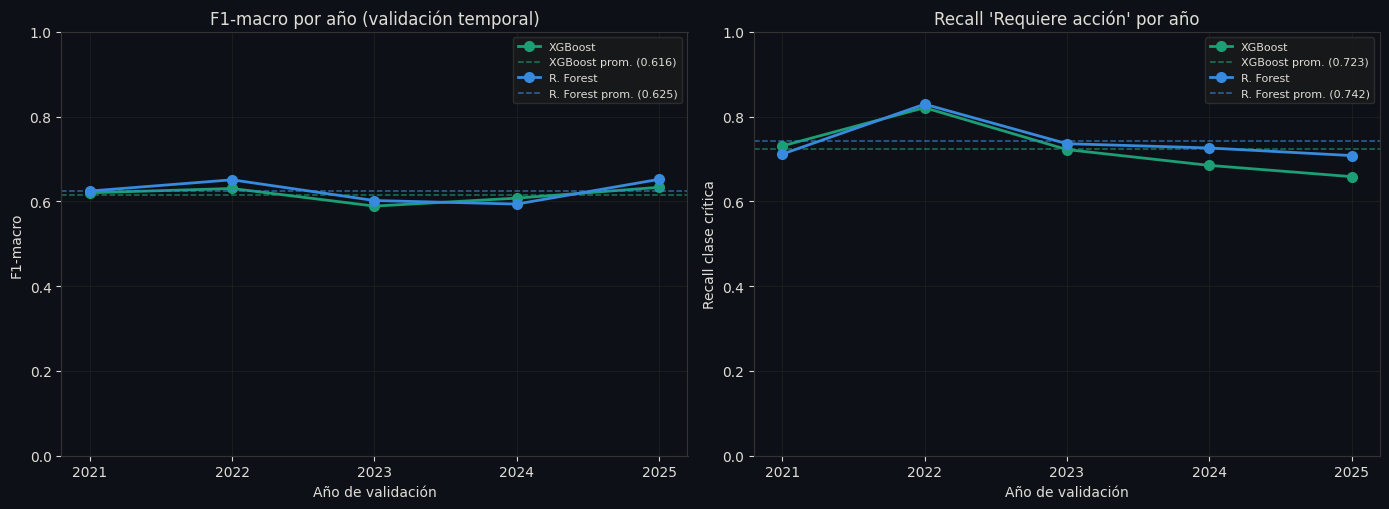

  VALIDACIÓN TEMPORAL EXPANSIVA — XGBoost vs RANDOM FOREST

  ── XGBoost ──
 Valida  N_train  N_val  F1_macro  Recall_Req  Precision_Req  Bal_acc
   2021      114    173     0.620       0.731          0.691    0.619
   2022      287    188     0.630       0.821          0.732    0.626
   2023      475    230     0.589       0.722          0.689    0.588
   2024      705    246     0.608       0.685          0.680    0.607
   2025      951    217     0.633       0.658          0.862    0.677

  ── R. Forest ──
 Valida  N_train  N_val  F1_macro  Recall_Req  Precision_Req  Bal_acc
   2021      114    173     0.624       0.712          0.698    0.624
   2022      287    188     0.651       0.829          0.745    0.645
   2023      475    230     0.602       0.736          0.697    0.601
   2024      705    246     0.594       0.726          0.662    0.593
   2025      951    217     0.652       0.708          0.857    0.684

  RESUMEN AGREGADO (promedio sobre folds)
           F1_mean  F1

In [37]:
# CELDA 20── VALIDACIÓN TEMPORAL EXPANSIVA — XGBoost vs RANDOM FOREST ──────────
# Caracteriza el desempeño de ambos modelos bajo condiciones de uso real y
# su estabilidad entre periodos. Walk-forward: entrena con los años
# anteriores acumulados y valida en el año siguiente (predecir el futuro con
# el pasado). Ambos modelos se entrenan en CADA fold sobre exactamente los
# mismos datos, con el encoder ajustado SOLO en train (anti-fuga).
#
# Lectura: los dos modelos empatan técnicamente en el split aleatorio
# (Celda 22) y también en la validación temporal (F1 y recall dentro del
# ruido de muestreo). Random Forest presenta un recall marginalmente
# superior, pero XGBoost es más estable entre periodos (menor F1_std) y
# generaliza mejor (menor gap train-test, Celda 22). Por ello se mantiene
# XGBoost como modelo seleccionado: la elección se sustenta en estabilidad
# y generalización, no en superioridad de recall.
#
# Nota metodológica: no se aplica purga temporal entre train y validación;
# el posible solape de etiquetas en el límite de año se declara como
# limitación (ver sección de limitaciones).
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import f1_score, recall_score, precision_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LABEL_CRITICA = MAPA_PERIODO["Requiere acción"]          # = 0
MODELOS_VT    = ["XGBoost", "R. Forest"]
COLOR_VT      = {"XGBoost": "#1D9E75", "R. Forest": "#378ADD"}

def nuevo_modelo_vt(nombre):
    """Devuelve un estimador NUEVO por fold (sin reusar el ya ajustado)."""
    if nombre == "XGBoost":
        return XGBClassifier(**XGB_PARAMS_A)
    return RandomForestClassifier(
        n_estimators=200, max_depth=5, min_samples_leaf=5,
        max_features="sqrt", random_state=42, n_jobs=-1,
    )

# ── 1. Datos con fecha (conservando fecha_falla para los folds) ──────
df_vt = df_modelo[FEATURES_A + [TARGET_PERIODO, "fecha_falla"]].dropna().copy()
df_vt["anio"] = df_vt["fecha_falla"].dt.year
df_vt[TARGET_PERIODO] = df_vt[TARGET_PERIODO].map(MAPA_PERIODO)
anios = sorted(df_vt["anio"].unique())

# ── 2. Loop de folds expansivos (ambos modelos por fold) ─────────────
resultados = []
for i in range(1, len(anios)):
    anio_val = anios[i]
    train = df_vt[df_vt["anio"] <  anio_val].copy()
    valid = df_vt[df_vt["anio"] == anio_val].copy()
    if len(valid) == 0 or train[TARGET_PERIODO].nunique() < 2:
        continue

    # Encoder ajustado SOLO con train (anti-fuga)
    enc_vt = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    train[FEATURES_A_CAT] = enc_vt.fit_transform(train[FEATURES_A_CAT])
    valid[FEATURES_A_CAT] = enc_vt.transform(valid[FEATURES_A_CAT])

    X_tr, y_tr = train[FEATURES_A].values, train[TARGET_PERIODO].values
    X_va, y_va = valid[FEATURES_A].values, valid[TARGET_PERIODO].values
    w_tr = compute_sample_weight("balanced", y_tr)

    for nombre in MODELOS_VT:
        m = nuevo_modelo_vt(nombre)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        y_pred = m.predict(X_va)
        resultados.append({
            "Modelo":        nombre,
            "Valida":        anio_val,
            "N_train":       len(train),
            "N_val":         len(valid),
            "F1_macro":      f1_score(y_va, y_pred, average="macro"),
            "Recall_Req":    recall_score(y_va, y_pred, pos_label=LABEL_CRITICA, zero_division=0),
            "Precision_Req": precision_score(y_va, y_pred, pos_label=LABEL_CRITICA, zero_division=0),
            "Bal_acc":       balanced_accuracy_score(y_va, y_pred),
        })

df_res = pd.DataFrame(resultados)

# ── 3. Gráfica: F1-macro y Recall crítico por fold (ambos modelos) ───
piv_f1  = df_res.pivot(index="Valida", columns="Modelo", values="F1_macro")
piv_rec = df_res.pivot(index="Valida", columns="Modelo", values="Recall_Req")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))
fig.patch.set_facecolor("#0d1117")

for ax, piv, titulo, ylab in [
    (ax1, piv_f1,  "F1-macro por año (validación temporal)", "F1-macro"),
    (ax2, piv_rec, "Recall 'Requiere acción' por año",       "Recall clase crítica"),
]:
    ax.set_facecolor("#0d1117")
    for nombre in MODELOS_VT:
        if nombre in piv.columns:
            ax.plot(piv.index, piv[nombre], marker="o", linewidth=2,
                    markersize=7, color=COLOR_VT[nombre], label=nombre)
            ax.axhline(piv[nombre].mean(), color=COLOR_VT[nombre],
                       linestyle="--", linewidth=1.1, alpha=0.7,
                       label="{} prom. ({:.3f})".format(nombre, piv[nombre].mean()))
    ax.set_xlabel("Año de validación", color="#e0ddd6")
    ax.set_ylabel(ylab, color="#e0ddd6")
    ax.set_title(titulo, color="#e0ddd6", fontsize=12)
    ax.tick_params(colors="#e0ddd6")
    ax.set_ylim(0, 1)
    ax.set_xticks(piv.index)
    ax.grid(True, color="#222222", linewidth=0.5)
    for s in ax.spines.values():
        s.set_color("#333")
    ax.legend(facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6", fontsize=8)

plt.tight_layout()
plt.savefig("validacion_temporal_comparativa.png", dpi=200,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── 4. Resultados por fold y resumen agregado ────────────────────────
print("=" * 68)
print("  VALIDACIÓN TEMPORAL EXPANSIVA — XGBoost vs RANDOM FOREST")
print("=" * 68)
for nombre in MODELOS_VT:
    sub = df_res[df_res["Modelo"] == nombre]
    print("\n  ── {} ──".format(nombre))
    print(sub.drop(columns="Modelo").round(3).to_string(index=False))

resumen = (df_res.groupby("Modelo")
           .agg(F1_mean=("F1_macro", "mean"),   F1_std=("F1_macro", "std"),
                Recall_mean=("Recall_Req", "mean"),
                Prec_mean=("Precision_Req", "mean"),
                Balacc_mean=("Bal_acc", "mean"))
           .reindex(MODELOS_VT).round(3))

print("\n" + "=" * 68)
print("  RESUMEN AGREGADO (promedio sobre folds)")
print("=" * 68)
print(resumen.to_string())

# ── 5. Lectura del desempate temporal ────────────────────────────────
lider_f1    = resumen["F1_mean"].idxmax()
lider_rec   = resumen["Recall_mean"].idxmax()
mas_estable = resumen["F1_std"].idxmin()
print("=" * 68)
print("  Líder en F1-macro temporal   : {} ({:.3f})".format(
      lider_f1,  resumen.loc[lider_f1,  "F1_mean"]))
print("  Líder en Recall crítico      : {} ({:.3f})".format(
      lider_rec, resumen.loc[lider_rec, "Recall_mean"]))
print("  Más estable (menor F1_std)   : {} ({:.3f})".format(
      mas_estable, resumen.loc[mas_estable, "F1_std"]))
print("-" * 68)
print("  Diferencias en F1 y recall dentro del ruido de muestreo (< 0.02).")
print("  Random Forest muestra un recall levemente superior, pero XGBoost es")
print("  más estable entre periodos (menor F1_std) y generaliza mejor (menor")
print("  gap train-test, Celda 22). Se mantiene XGBoost como modelo")
print("  seleccionado, priorizando estabilidad y generalizacion sobre una")
print("  diferencia marginal de recall.")
print("=" * 68)

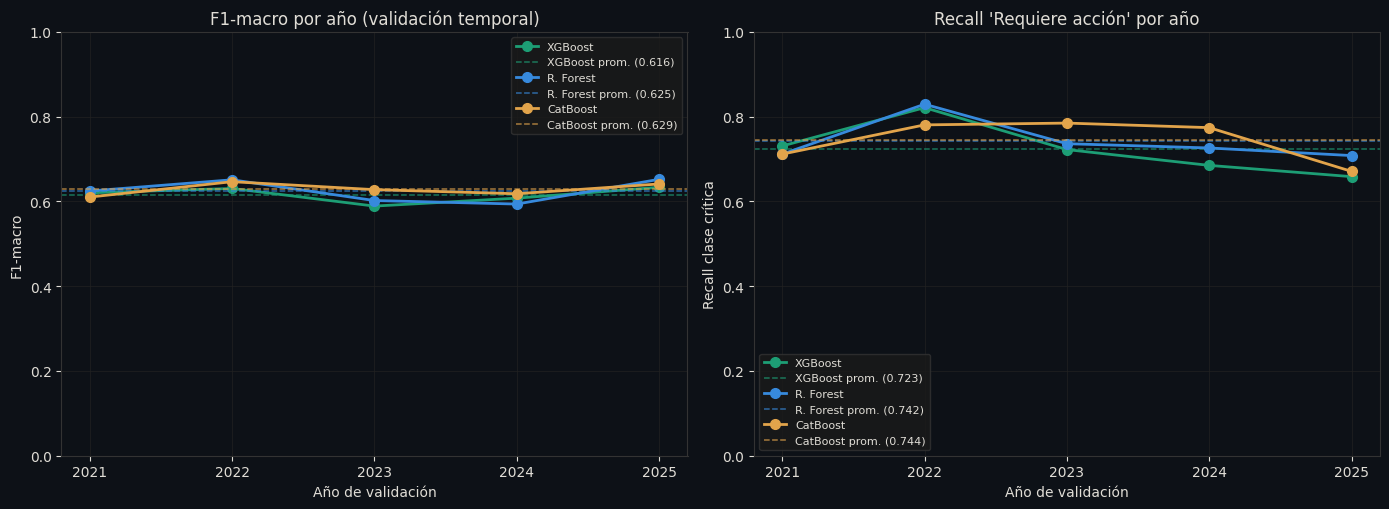

  VALIDACIÓN TEMPORAL EXPANSIVA — XGBoost, R. Forest, CatBoost

  ── XGBoost ──
 Valida  N_train  N_val  F1_macro  Recall_Req  Precision_Req  Bal_acc
   2021      114    173     0.620       0.731          0.691    0.619
   2022      287    188     0.630       0.821          0.732    0.626
   2023      475    230     0.589       0.722          0.689    0.588
   2024      705    246     0.608       0.685          0.680    0.607
   2025      951    217     0.633       0.658          0.862    0.677

  ── R. Forest ──
 Valida  N_train  N_val  F1_macro  Recall_Req  Precision_Req  Bal_acc
   2021      114    173     0.624       0.712          0.698    0.624
   2022      287    188     0.651       0.829          0.745    0.645
   2023      475    230     0.602       0.736          0.697    0.601
   2024      705    246     0.594       0.726          0.662    0.593
   2025      951    217     0.652       0.708          0.857    0.684

  ── CatBoost ──
 Valida  N_train  N_val  F1_macro  Recall_R

In [38]:
# PRUEBA CELDA 20 ── VALIDACIÓN TEMPORAL EXPANSIVA — XGBoost, Random Forest, CatBoost ──
# Caracteriza el desempeño de los modelos bajo condiciones de uso real y su
# estabilidad entre periodos. Walk-forward: entrena con los años anteriores
# acumulados y valida en el año siguiente (predecir el futuro con el pasado).
# Todos los modelos se entrenan en CADA fold sobre exactamente los mismos
# datos, con el encoder ajustado SOLO en train (anti-fuga).
#
# Nota metodológica: no se aplica purga temporal entre train y validación;
# el posible solape de etiquetas en el límite de año se declara como
# limitación (ver sección de limitaciones).
import subprocess
subprocess.run(["pip", "install", "catboost", "--quiet"], capture_output=True)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import f1_score, recall_score, precision_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LABEL_CRITICA = MAPA_PERIODO["Requiere acción"]          # = 0
MODELOS_VT    = ["XGBoost", "R. Forest", "CatBoost"]
COLOR_VT      = {"XGBoost": "#1D9E75", "R. Forest": "#378ADD", "CatBoost": "#E2A44B"}

CAT_PARAMS_A = dict(
    iterations=150, depth=2, learning_rate=0.03,
    l2_leaf_reg=1.0, subsample=0.7, rsm=0.7,
    bootstrap_type="Bernoulli", random_seed=42, verbose=0,
)

def nuevo_modelo_vt(nombre):
    """Devuelve un estimador NUEVO por fold (sin reusar el ya ajustado)."""
    if nombre == "XGBoost":
        return XGBClassifier(**XGB_PARAMS_A)
    if nombre == "CatBoost":
        return CatBoostClassifier(**CAT_PARAMS_A)
    return RandomForestClassifier(
        n_estimators=200, max_depth=5, min_samples_leaf=5,
        max_features="sqrt", random_state=42, n_jobs=-1,
    )

# ── 1. Datos con fecha (conservando fecha_falla para los folds) ──────
df_vt = df_modelo[FEATURES_A + [TARGET_PERIODO, "fecha_falla"]].dropna().copy()
df_vt["anio"] = df_vt["fecha_falla"].dt.year
df_vt[TARGET_PERIODO] = df_vt[TARGET_PERIODO].map(MAPA_PERIODO)
anios = sorted(df_vt["anio"].unique())

# ── 2. Loop de folds expansivos (todos los modelos por fold) ─────────
resultados = []
for i in range(1, len(anios)):
    anio_val = anios[i]
    train = df_vt[df_vt["anio"] <  anio_val].copy()
    valid = df_vt[df_vt["anio"] == anio_val].copy()
    if len(valid) == 0 or train[TARGET_PERIODO].nunique() < 2:
        continue

    # Encoder ajustado SOLO con train (anti-fuga)
    enc_vt = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    train[FEATURES_A_CAT] = enc_vt.fit_transform(train[FEATURES_A_CAT])
    valid[FEATURES_A_CAT] = enc_vt.transform(valid[FEATURES_A_CAT])

    X_tr, y_tr = train[FEATURES_A].values, train[TARGET_PERIODO].values
    X_va, y_va = valid[FEATURES_A].values, valid[TARGET_PERIODO].values
    w_tr = compute_sample_weight("balanced", y_tr)

    for nombre in MODELOS_VT:
        m = nuevo_modelo_vt(nombre)
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        y_pred = np.asarray(m.predict(X_va)).ravel().astype(int)
        resultados.append({
            "Modelo":        nombre,
            "Valida":        anio_val,
            "N_train":       len(train),
            "N_val":         len(valid),
            "F1_macro":      f1_score(y_va, y_pred, average="macro"),
            "Recall_Req":    recall_score(y_va, y_pred, pos_label=LABEL_CRITICA, zero_division=0),
            "Precision_Req": precision_score(y_va, y_pred, pos_label=LABEL_CRITICA, zero_division=0),
            "Bal_acc":       balanced_accuracy_score(y_va, y_pred),
        })

df_res = pd.DataFrame(resultados)

# ── 3. Gráfica: F1-macro y Recall crítico por fold (todos los modelos) ─
piv_f1  = df_res.pivot(index="Valida", columns="Modelo", values="F1_macro")
piv_rec = df_res.pivot(index="Valida", columns="Modelo", values="Recall_Req")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))
fig.patch.set_facecolor("#0d1117")

for ax, piv, titulo, ylab in [
    (ax1, piv_f1,  "F1-macro por año (validación temporal)", "F1-macro"),
    (ax2, piv_rec, "Recall 'Requiere acción' por año",       "Recall clase crítica"),
]:
    ax.set_facecolor("#0d1117")
    for nombre in MODELOS_VT:
        if nombre in piv.columns:
            ax.plot(piv.index, piv[nombre], marker="o", linewidth=2,
                    markersize=7, color=COLOR_VT[nombre], label=nombre)
            ax.axhline(piv[nombre].mean(), color=COLOR_VT[nombre],
                       linestyle="--", linewidth=1.1, alpha=0.7,
                       label="{} prom. ({:.3f})".format(nombre, piv[nombre].mean()))
    ax.set_xlabel("Año de validación", color="#e0ddd6")
    ax.set_ylabel(ylab, color="#e0ddd6")
    ax.set_title(titulo, color="#e0ddd6", fontsize=12)
    ax.tick_params(colors="#e0ddd6")
    ax.set_ylim(0, 1)
    ax.set_xticks(piv.index)
    ax.grid(True, color="#222222", linewidth=0.5)
    for s in ax.spines.values():
        s.set_color("#333")
    ax.legend(facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6", fontsize=8)

plt.tight_layout()
plt.savefig("validacion_temporal_comparativa.png", dpi=200,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── 4. Resultados por fold y resumen agregado ────────────────────────
print("=" * 68)
print("  VALIDACIÓN TEMPORAL EXPANSIVA — {}".format(", ".join(MODELOS_VT)))
print("=" * 68)
for nombre in MODELOS_VT:
    sub = df_res[df_res["Modelo"] == nombre]
    print("\n  ── {} ──".format(nombre))
    print(sub.drop(columns="Modelo").round(3).to_string(index=False))

resumen = (df_res.groupby("Modelo")
           .agg(F1_mean=("F1_macro", "mean"),   F1_std=("F1_macro", "std"),
                Recall_mean=("Recall_Req", "mean"),
                Prec_mean=("Precision_Req", "mean"),
                Balacc_mean=("Bal_acc", "mean"))
           .reindex(MODELOS_VT).round(3))

print("\n" + "=" * 68)
print("  RESUMEN AGREGADO (promedio sobre folds)")
print("=" * 68)
print(resumen.to_string())

# ── 5. Líderes por criterio (derivados de los datos, sin narrativa fija) ─
print("=" * 68)
print("  Líder en F1-macro temporal   : {} ({:.3f})".format(
      resumen["F1_mean"].idxmax(),  resumen["F1_mean"].max()))
print("  Líder en Recall crítico      : {} ({:.3f})".format(
      resumen["Recall_mean"].idxmax(), resumen["Recall_mean"].max()))
print("  Más estable (menor F1_std)   : {} ({:.3f})".format(
      resumen["F1_std"].idxmin(), resumen["F1_std"].min()))
print("  Rango de F1-macro entre modelos : {:.3f}".format(
      resumen["F1_mean"].max() - resumen["F1_mean"].min()))
print("=" * 68)

### 21. Selección del Modelo A: fundamentación del uso de XGBoost

El clasificador del Modelo A se seleccionó mediante un procedimiento en dos etapas —comparación en igualdad de condiciones y validación temporal— en lugar de fijarlo a priori, con el fin de justificar la elección con evidencia empírica.

**Etapa 1 — Comparación en el conjunto de prueba (split aleatorio).** Se entrenaron cuatro modelos sobre exactamente el mismo split, encoder y ponderación de clases (`sample_weight="balanced"`), evaluados a umbral por defecto para una comparación justa: un baseline (`DummyClassifier`, estrategia `most_frequent`), un modelo lineal (Regresión Logística) y dos modelos no lineales (Random Forest y XGBoost). El baseline estableció el piso de desempeño (F1-macro = 0.389), que todos los modelos con aprendizaje real superaron. La Regresión Logística (F1-macro = 0.647) quedó por debajo de los modelos no lineales, lo que aporta evidencia empírica de que la frontera de decisión del problema no es linealmente separable —coherente con el coeficiente de silueta prácticamente nulo (≈0.011) observado en el análisis de separabilidad—. Random Forest (0.658) y XGBoost (0.651) resultaron en empate técnico: su diferencia (0.007) es inferior al margen atribuible al ruido de muestreo en un conjunto de prueba de este tamaño, por lo que no constituye una ventaja real de ninguno.

**Etapa 2 — Validación temporal expansiva.** Para evaluar ambos modelos bajo condiciones de uso real, se sometieron a validación temporal *walk-forward* (entrenar con los años acumulados previos y validar en el año siguiente), con el codificador ajustado únicamente sobre el conjunto de entrenamiento en cada fold para evitar fuga de información. El resultado fue una equivalencia estadística en las métricas agregadas: F1-macro de 0.616 (XGBoost) frente a 0.625 (Random Forest), y recall de la clase crítica "Requiere acción" de 0.723 frente a 0.742. Random Forest presentó un desempeño marginalmente superior en ambas métricas, pero dentro del ruido de muestreo, mientras que XGBoost mostró mayor estabilidad entre periodos (menor desviación año a año). Esta equivalencia confirma que ningún modelo domina de forma inequívoca y que la decisión no debe basarse en una única partición aleatoria.

**Criterio de selección final.** Dado que ambos modelos son estadísticamente equivalentes en desempeño —con Random Forest levemente por delante en recall temporal—, la elección de XGBoost se fundamenta en criterios de robustez y aptitud para el despliegue, priorizados por tratarse de un modelo destinado a predecir fallas futuras en operación:

1. **Mejor generalización.** En el conjunto de prueba, XGBoost presentó una brecha train–test menor (+0.027) frente a la de Random Forest (+0.047), lo que indica menor sobreajuste.
2. **Mayor estabilidad temporal.** Menor desviación del F1-macro entre folds (0.018 frente a 0.027), es decir, desempeño más consistente año a año.
3. **Mayor parsimonia.** El modelo opera con `max_depth = 2` frente a la profundidad 5 de Random Forest, ofreciendo un modelo más simple y regularizado a desempeño equivalente (principio de parsimonia).
4. **Coherencia operativa.** XGBoost se integra de forma consistente con el resto del pipeline (exportación de artefactos, umbral y capa descriptiva).

En síntesis, XGBoost no se selecciona por rendir más que Random Forest —Random Forest incluso presenta un recall ligeramente superior en la validación temporal—, sino por ofrecer un desempeño equivalente con mejor generalización, mayor estabilidad entre periodos y menor complejidad, características prioritarias para un modelo cuyo objetivo es anticipar fallas futuras, donde el sobreajuste compromete la fiabilidad operativa.

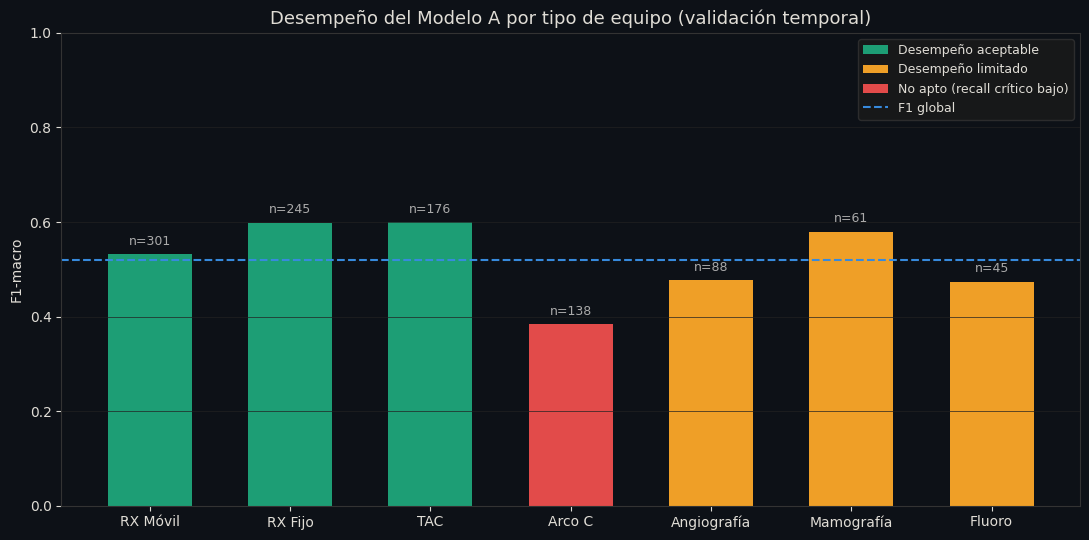

  DESEMPEÑO POR TIPO DE EQUIPO — VALIDACIÓN TEMPORAL AGREGADA
     Equipo  N_eval  F1_macro  Recall_Req  Precis_Req  FN  %Req    Muestra Desempeno
   RX Móvil     301     0.532       0.901       0.755  22  74.0 suficiente aceptable
    RX Fijo     245     0.598       0.838       0.777  29  73.0 suficiente aceptable
        TAC     176     0.599       0.654       0.806  44  72.0 suficiente aceptable
     Arco C     138     0.384       0.000       0.000  47  34.0 suficiente   no apto
Angiografía      88     0.477       0.596       0.519  19  53.0 suficiente  limitado
 Mamografía      61     0.579       0.481       0.542  14  44.0   reducida  limitado
     Fluoro      45     0.474       0.793       0.639   6  64.0   reducida  limitado
  N_eval  = casos evaluados (suma de todos los folds temporales)
  FN      = falsos negativos (Requiere acción clasificado como Estable)
  Suficiencia muestral: n >= 80 casos evaluados
  Desempeño apto: recall 'Requiere acción' >= 0.50 y F1-macro >= 0.50

  

In [39]:
# CELDA 21── DESEMPEÑO POR TIPO DE EQUIPO — VALIDACIÓN TEMPORAL ───────
# F1 por tipo de equipo agregando las predicciones de todos los folds
# temporales (más robusto que un solo test). Distingue DOS ejes: la
# suficiencia muestral (casos disponibles) y el desempeño predictivo
# (recall de la clase crítica). Un tipo puede tener muestra suficiente y
# aun así no ser apto: la fiabilidad se evalúa por desempeño, no por
# tamaño de muestra. El checklist opera por tipo.
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

UMBRAL_MUESTRA  = 80     # suficiencia muestral: mínimo de casos evaluados
RECALL_MIN_APTO = 0.50   # desempeño mínimo aceptable en la clase crítica

# Datos con fecha y tipo (conservar tipo_equipo original para agrupar)
df_pe = df_modelo[FEATURES_A + [TARGET_PERIODO, "fecha_falla", "tipo_equipo"]].dropna(
    subset=FEATURES_A + [TARGET_PERIODO]).copy()
df_pe["anio"] = df_pe["fecha_falla"].dt.year
df_pe["_y"] = df_pe[TARGET_PERIODO].map(MAPA_PERIODO)
anios = sorted(df_pe["anio"].unique())

# ── Acumular predicciones de todos los folds, guardando el tipo ──
predicciones = []
for i in range(1, len(anios)):
    av = anios[i]
    tr = df_pe[df_pe["anio"] <  av].copy()
    va = df_pe[df_pe["anio"] == av].copy()
    if tr["_y"].nunique() < 2:
        continue

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    tr_enc = tr.copy(); va_enc = va.copy()
    tr_enc[FEATURES_A_CAT] = enc.fit_transform(tr[FEATURES_A_CAT])
    va_enc[FEATURES_A_CAT] = enc.transform(va[FEATURES_A_CAT])

    w = compute_sample_weight("balanced", tr_enc["_y"].values)
    m = XGBClassifier(**XGB_PARAMS_A)
    m.fit(tr_enc[FEATURES_A].values, tr_enc["_y"].values, sample_weight=w)

    va = va.copy()
    va["_pred"] = m.predict(va_enc[FEATURES_A].values)
    predicciones.append(va[["tipo_equipo", "_y", "_pred"]])

pred_all = pd.concat(predicciones, ignore_index=True)

# Asegurar que no haya columnas duplicadas y que tipo_equipo sea Serie
pred_all = pred_all.loc[:, ~pred_all.columns.duplicated()]

# ── F1 y métricas por tipo de equipo ─────────────────────────
filas = []
tipos_unicos = pd.unique(pred_all["tipo_equipo"])   # pd.unique evita el problema
for tipo in sorted(tipos_unicos):
    sub = pred_all[pred_all["tipo_equipo"] == tipo]
    n = len(sub)
    nombre = NOMBRES_CORTOS.get(tipo, tipo)
    pct_req = (sub["_y"] == 0).mean() * 100

    if sub["_y"].nunique() < 2:
        filas.append({"Equipo": nombre, "N_eval": n, "F1_macro": np.nan,
                      "Recall_Req": np.nan, "Precis_Req": np.nan, "FN": np.nan,
                      "%Req": round(pct_req, 0),
                      "Muestra": "suficiente" if n >= UMBRAL_MUESTRA else "reducida",
                      "Desempeno": "no evaluable"})
        continue

    f1  = f1_score(sub["_y"], sub["_pred"], average="macro")
    rec = recall_score(sub["_y"], sub["_pred"], pos_label=0, zero_division=0)
    pre = precision_score(sub["_y"], sub["_pred"], pos_label=0, zero_division=0)
    cm  = confusion_matrix(sub["_y"], sub["_pred"], labels=[0, 1])
    fn  = cm[0, 1]

    filas.append({
        "Equipo": nombre, "N_eval": n, "F1_macro": round(f1, 3),
        "Recall_Req": round(rec, 3), "Precis_Req": round(pre, 3), "FN": int(fn),
        "%Req": round(pct_req, 0),
        "Muestra":   "suficiente" if n >= UMBRAL_MUESTRA else "reducida",
        "Desempeno": ("aceptable" if rec >= RECALL_MIN_APTO and f1 >= 0.50
                      else "limitado" if rec >= 0.30 else "no apto"),
    })

df_pe_res = pd.DataFrame(filas).sort_values("N_eval", ascending=False)

# ── Gráfica: F1 por equipo (barras, color por DESEMPEÑO) ──────
fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")
plot_df = df_pe_res.dropna(subset=["F1_macro"])
COL_DES = {"aceptable": "#1D9E75", "limitado": "#EF9F27",
           "no apto": "#E24B4A", "no evaluable": "#666666"}
colores = [COL_DES.get(d, "#666666") for d in plot_df["Desempeno"]]
barras = ax.bar(plot_df["Equipo"], plot_df["F1_macro"], color=colores, width=0.6)
for b, n in zip(barras, plot_df["N_eval"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"n={n}",
            ha="center", color="#aaaaaa", fontsize=9)
ax.axhline(df_pe_res["F1_macro"].mean(), color="#378ADD", linestyle="--",
           linewidth=1.5, label=f"F1 global ({df_pe_res['F1_macro'].mean():.3f})")
ax.set_ylabel("F1-macro", color="#e0ddd6")
ax.set_title("Desempeño del Modelo A por tipo de equipo (validación temporal)",
             color="#e0ddd6", fontsize=13)
ax.tick_params(colors="#e0ddd6")
ax.set_ylim(0, 1)
from matplotlib.patches import Patch
leyenda = [Patch(facecolor="#1D9E75", label="Desempeño aceptable"),
           Patch(facecolor="#EF9F27", label="Desempeño limitado"),
           Patch(facecolor="#E24B4A", label="No apto (recall crítico bajo)")]
ax.legend(handles=leyenda + [plt.Line2D([0],[0], color="#378ADD", linestyle="--",
          label="F1 global")], facecolor="#1a1a1a", edgecolor="#333",
          labelcolor="#e0ddd6", fontsize=9)
for s in ax.spines.values():
    s.set_color("#333")
ax.grid(True, axis="y", color="#222222", linewidth=0.5)
plt.tight_layout()
plt.savefig("desempeno_por_tipo.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Tabla ────────────────────────────────────────────────────
print("=" * 72)
print("  DESEMPEÑO POR TIPO DE EQUIPO — VALIDACIÓN TEMPORAL AGREGADA")
print("=" * 72)
print(df_pe_res.to_string(index=False))
print("=" * 72)
print(f"  N_eval  = casos evaluados (suma de todos los folds temporales)")
print(f"  FN      = falsos negativos (Requiere acción clasificado como Estable)")
print(f"  Suficiencia muestral: n >= {UMBRAL_MUESTRA} casos evaluados")
print(f"  Desempeño apto: recall 'Requiere acción' >= {RECALL_MIN_APTO:.2f} y F1-macro >= 0.50")
print(f"\n  Muestra y desempeño son ejes INDEPENDIENTES: un tipo con muestra")
print(f"  suficiente puede aun así ser 'no apto' (p. ej. recall crítico bajo).")
print(f"  El modelo es fiable solo en los tipos con desempeño aceptable; en el")
print(f"  resto la priorización se apoya en el análisis histórico (matriz).")

El desempeño del Modelo A no es homogéneo entre tipos de equipo. Al separar la suficiencia muestral del desempeño predictivo se distinguen tres situaciones. En los equipos con mayor volumen de datos —RX Móvil (n=301, recall=0.90), RX Fijo (n=245, recall=0.84) y TAC (n=176, recall=0.65)— el modelo alcanza un desempeño aceptable. El arco en C constituye el caso crítico: pese a contar con muestra suficiente (n=138), su recall de la clase crítica es 0.000, por lo que se clasifica como no apto; su baja tasa de recurrencia (34%, la menor de todos los tipos) dificulta que el modelo aprenda a identificar la clase minoritaria. Finalmente, tipos como Fluoro presentan un recall razonable (0.79) pero muestra reducida (n=45), por lo que su desempeño se considera limitado por falta de datos, no por incapacidad del modelo. Esta distinción delimita el alcance del componente predictivo: es fiable en los tipos con desempeño aceptable, mientras que en el resto la priorización se apoya en el análisis histórico de la matriz.

## 22. Sensibilidad del horizonte temporal
El horizonte de 30 días se sustenta en dos criterios convergentes. Empíricamente, el análisis de sensibilidad —que evaluó 15, 30, 45, 60 y 90 días mediante validación temporal— confirma que los 30 días ofrecen un desempeño competitivo y estable, sin degradación frente a horizontes mayores. Operativamente, 30 días constituye una ventana accionable para el hospital: suficiente para planear la intervención de mantenimiento (repuestos, programación, vigilancia reforzada) y a la vez lo bastante ajustada para que la predicción sea específica y útil. La elección no responde únicamente a la métrica máxima, sino al equilibrio entre desempeño estadístico y utilidad operativa.

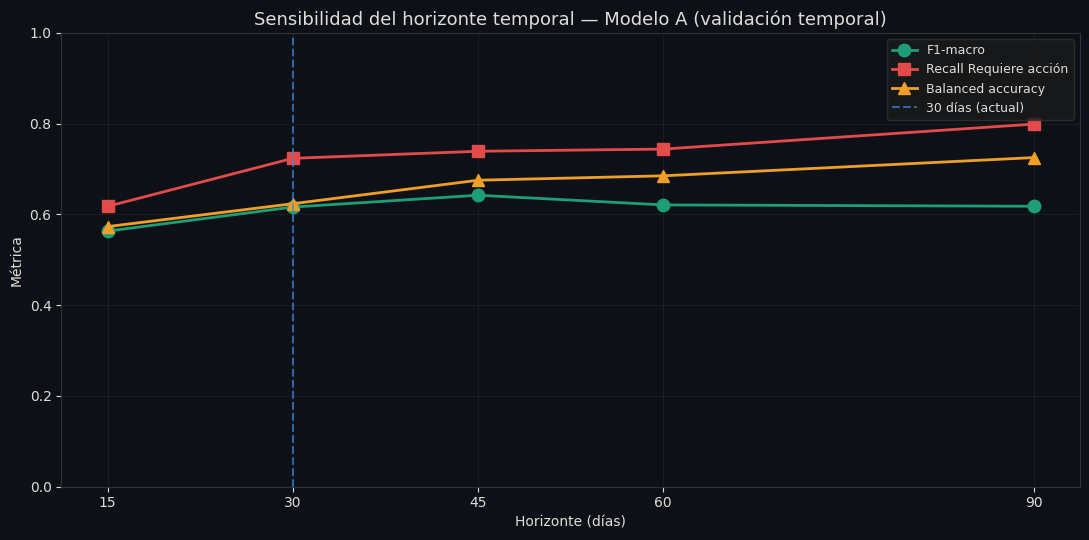

  SENSIBILIDAD DEL HORIZONTE — MODELO A (validación temporal, umbral 0.50)
 Horizonte  %Requiere  %Estable  F1_macro  Recall_Req  Precis_Req  Bal_acc  Desv_F1  Excluidos
        15       43.9      56.1     0.563       0.618       0.512    0.573    0.054          0
        30       63.8      36.2     0.616       0.723       0.731    0.624    0.016          0
        45       76.4      23.6     0.642       0.739       0.861    0.675    0.055          0
        60       82.7      17.3     0.621       0.744       0.907    0.685    0.063          0
        90       90.2       9.8     0.618       0.799       0.955    0.725    0.062          0
  Criterio de selección (no solo F1 máximo):
  - F1-macro competitivo y estable (baja desviación entre folds)
  - Recall alto de 'Requiere acción' (detectar recurrencias)
  - Balance de clases no extremo (evitar que una domine)
  - Horizonte con tiempo operativo suficiente para el hospital


In [40]:
# CELDA 22── SENSIBILIDAD DEL HORIZONTE TEMPORAL — MODELO A ───────────
# Reconstruye el target para 15/30/45/60/90 días y evalúa cada horizonte
# con validación temporal (umbral fijo 0.50). Sustenta la elección del
# horizonte de 30 días o identifica uno más apropiado.
# Primero se decide el horizonte; el umbral se optimiza después.
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             balanced_accuracy_score)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HORIZONTES = [15, 30, 45, 60, 90]
fecha_cierre = df_modelo["fecha_falla"].max()

# Base: necesita tbf_siguiente (tiempo a la próxima falla) y features
df_sh = df_modelo[FEATURES_A + ["tbf_siguiente", "fecha_falla"]].dropna(
    subset=FEATURES_A + ["tbf_siguiente"]).copy()
df_sh["anio"] = df_sh["fecha_falla"].dt.year
df_sh["dias_hasta_cierre"] = (fecha_cierre - df_sh["fecha_falla"]).dt.days
anios = sorted(df_sh["anio"].unique())

resultados_h = []
for H in HORIZONTES:
    # Target para este horizonte: 0 = Requiere acción (próxima ≤ H), 1 = Estable
    dfh = df_sh.copy()
    dfh["y"] = np.where(dfh["tbf_siguiente"] <= H, 0, 1)

    # Censura: un "Estable" (1) necesita al menos H días de seguimiento.
    # Si no los tiene (cerca del cierre), se excluye para este horizonte.
    censura = (dfh["y"] == 1) & (dfh["dias_hasta_cierre"] < H)
    dfh = dfh[~censura].copy()
    n_excluidos = censura.sum()

    # Validación temporal expansiva
    f1s, recalls, precs, bals = [], [], [], []
    for i in range(1, len(anios)):
        av = anios[i]
        tr = dfh[dfh["anio"] <  av].copy()
        va = dfh[dfh["anio"] == av].copy()
        if tr["y"].nunique() < 2 or va["y"].nunique() < 2 or len(va) < 10:
            continue

        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        tr[FEATURES_A_CAT] = enc.fit_transform(tr[FEATURES_A_CAT])
        va[FEATURES_A_CAT] = enc.transform(va[FEATURES_A_CAT])

        Xtr, ytr = tr[FEATURES_A].values, tr["y"].values
        Xva, yva = va[FEATURES_A].values, va["y"].values
        w = compute_sample_weight("balanced", ytr)

        m = XGBClassifier(**XGB_PARAMS_A)
        m.fit(Xtr, ytr, sample_weight=w)
        yp = m.predict(Xva)   # umbral 0.50 (predict por defecto)

        f1s.append(f1_score(yva, yp, average="macro"))
        recalls.append(recall_score(yva, yp, pos_label=0))
        precs.append(precision_score(yva, yp, pos_label=0, zero_division=0))
        bals.append(balanced_accuracy_score(yva, yp))

    pct_req = (dfh["y"] == 0).mean() * 100
    resultados_h.append({
        "Horizonte":   H,
        "%Requiere":   round(pct_req, 1),
        "%Estable":    round(100 - pct_req, 1),
        "F1_macro":    np.mean(f1s),
        "Recall_Req":  np.mean(recalls),
        "Precis_Req":  np.mean(precs),
        "Bal_acc":     np.mean(bals),
        "Desv_F1":     np.std(f1s),
        "Excluidos":   n_excluidos,
    })

df_h = pd.DataFrame(resultados_h)

# ── Gráfica: métricas por horizonte ──────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")
ax.plot(df_h["Horizonte"], df_h["F1_macro"], marker="o", color="#1D9E75",
        linewidth=2, markersize=9, label="F1-macro")
ax.plot(df_h["Horizonte"], df_h["Recall_Req"], marker="s", color="#E24B4A",
        linewidth=2, markersize=8, label="Recall Requiere acción")
ax.plot(df_h["Horizonte"], df_h["Bal_acc"], marker="^", color="#EF9F27",
        linewidth=2, markersize=8, label="Balanced accuracy")
# Marcar 30 días
ax.axvline(30, color="#378ADD", linestyle="--", linewidth=1.5, alpha=0.7,
           label="30 días (actual)")
ax.set_xlabel("Horizonte (días)", color="#e0ddd6")
ax.set_ylabel("Métrica", color="#e0ddd6")
ax.set_title("Sensibilidad del horizonte temporal — Modelo A (validación temporal)",
             color="#e0ddd6", fontsize=13)
ax.tick_params(colors="#e0ddd6")
ax.set_xticks(HORIZONTES)
ax.set_ylim(0, 1)
ax.legend(facecolor="#1a1a1a", edgecolor="#333", labelcolor="#e0ddd6", fontsize=9)
for s in ax.spines.values():
    s.set_color("#333")
ax.grid(True, color="#222222", linewidth=0.5)
plt.tight_layout()
plt.savefig("sensibilidad_horizonte.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Tabla de resultados ──────────────────────────────────────
print("=" * 70)
print("  SENSIBILIDAD DEL HORIZONTE — MODELO A (validación temporal, umbral 0.50)")
print("=" * 70)
print(df_h.round(3).to_string(index=False))
print("=" * 70)
print("  Criterio de selección (no solo F1 máximo):")
print("  - F1-macro competitivo y estable (baja desviación entre folds)")
print("  - Recall alto de 'Requiere acción' (detectar recurrencias)")
print("  - Balance de clases no extremo (evitar que una domine)")
print("  - Horizonte con tiempo operativo suficiente para el hospital")

# Bloque 4. Validación del modelo.

Con el modelo A entrenado, este bloque evalúa su capacidad de
generalización y justifica las decisiones metodológicas tomadas
durante el entrenamiento.

23. Validación cruzada — estabilidad frente al muestreo. Se aplica
validación cruzada estratificada de 5 folds sobre el conjunto completo del
Modelo A, con el `sample_weight` balanceado recalculado en cada fold y
evaluación a umbral por defecto (0.50), para verificar que el desempeño no
depende de la partición aleatoria particular. El F1-macro medio es 0.628
(desviación 0.042) y difiere en 0.023 del conjunto de prueba (0.651), por
debajo del margen aceptable de 0.05.

Nota metodológica: esta validación cruzada usa particiones aleatorias, por lo
que mide estabilidad frente al muestreo y no estima el desempeño en
operación. Esa estimación corresponde a la validación temporal expansiva.

In [41]:
# ── CELDA 23 — VALIDACIÓN CRUZADA — MODELO A ──────────────────
# Validación cruzada estratificada (5-fold): mide la ESTABILIDAD del
# desempeño del Modelo A (XGBoost) frente a distintas particiones
# aleatorias de los datos.
# Nota metodológica: esta CV usa shuffle para evaluar robustez al muestreo,
# NO para estimar el desempeño en operación. La estimación de desempeño en
# uso real es la validación temporal expansiva (walk-forward). Ambas son
# complementarias y miden cosas distintas.
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_con_pesos(X, y, n_clases):
    """CV estratificada replicando la metodología real del Modelo A:
    sample_weight 'balanced' recalculado en cada fold de entrenamiento."""
    scores, f1_clases = [], []
    for tr_idx, te_idx in skf.split(X, y):
        w = compute_sample_weight("balanced", y[tr_idx])
        m = XGBClassifier(**XGB_PARAMS_A)          # parámetros del Modelo A
        m.fit(X[tr_idx], y[tr_idx], sample_weight=w)
        y_pred = m.predict(X[te_idx])
        scores.append(f1_score(y[te_idx], y_pred, average="macro"))
        f1_clases.append(f1_score(y[te_idx], y_pred, average=None,
                                  labels=np.arange(n_clases)))
    return np.array(scores), np.vstack(f1_clases).mean(axis=0)

# ══════════════════════════════════════════════════════════════
# VALIDACIÓN CRUZADA — MODELO A
# ══════════════════════════════════════════════════════════════
scores_a, f1_a_clase_cv = cv_con_pesos(X_a, y_a, len(clases_a))

print("=" * 55)
print("  Validación cruzada 5-fold — Modelo A (con sample_weight)")
print("=" * 55)
print("  F1-macro por fold:")
for i, s in enumerate(scores_a):
    print("    Fold {}  {:.3f}  {}".format(i+1, s, "█" * int(s * 30)))
print()
print("  F1-macro CV medio : {:.3f}".format(scores_a.mean()))
print("  Desviación std    : {:.3f}".format(scores_a.std()))
print("  F1-macro test     : {:.3f}".format(f1_a))
print("  Diferencia CV-test: {:.3f}".format(abs(scores_a.mean() - f1_a)))
if abs(scores_a.mean() - f1_a) < 0.05:
    print("  ✓ Diferencia < 0.05 → el desempeño no depende del split particular")
else:
    print("  ⚠ Diferencia > 0.05 → revisar posible sobreajuste al split")
print()
print("  Nota: CV evaluada con corte 0.50 (F1-macro base del modelo).")
print("        El umbral óptimo es un ajuste del punto de operación (Celda 21).")
print("        El desempeño en uso real se reporta en la validación temporal.")
print()
print("  F1 por clase (promedio 5 folds):")
for nombre, val in zip(clases_a, f1_a_clase_cv):
    print("    {:<22} {:.3f}".format(nombre, val))

# ── Resumen ────────────────────────────────────────────────────
print()
print("=" * 55)
print("  Resumen — Modelo A")
print("=" * 55)
print("  {:<14} {:>10} {:>12} {:>10}".format(
    "Modelo", "F1 test", "F1 CV medio", "Std CV"))
print("  " + "-" * 46)
print("  {:<14} {:>10.3f} {:>12.3f} {:>10.3f}".format(
    "Modelo A", f1_a, scores_a.mean(), scores_a.std()))

  Validación cruzada 5-fold — Modelo A (con sample_weight)
  F1-macro por fold:
    Fold 1  0.694  ████████████████████
    Fold 2  0.620  ██████████████████
    Fold 3  0.625  ██████████████████
    Fold 4  0.638  ███████████████████
    Fold 5  0.561  ████████████████

  F1-macro CV medio : 0.628
  Desviación std    : 0.042
  F1-macro test     : 0.651
  Diferencia CV-test: 0.023
  ✓ Diferencia < 0.05 → el desempeño no depende del split particular

  Nota: CV evaluada con corte 0.50 (F1-macro base del modelo).
        El umbral óptimo es un ajuste del punto de operación (Celda 21).
        El desempeño en uso real se reporta en la validación temporal.

  F1 por clase (promedio 5 folds):
    Requiere acción        0.693
    Estable                0.562

  Resumen — Modelo A
  Modelo            F1 test  F1 CV medio     Std CV
  ----------------------------------------------
  Modelo A            0.651        0.628      0.042


### 24. Experimento de estrategias de balanceo

Se comparan tres estrategias para tratar el desbalance de clases del Modelo A, todas bajo protocolo idéntico (mismo split, mismo clasificador y umbral 0.50) para aislar el efecto de la estrategia: ponderación por costo con `compute_sample_weight("balanced")` —el método adoptado—, SMOTENC total (iguala las clases a la mayoritaria) y SMOTENC parcial (sube la clase minoritaria a una fracción de la mayoritaria). Se evalúan en F1-macro y en la brecha train–test (gap) como indicador de sobreajuste. El objetivo es verificar si el sobremuestreo sintético aporta una mejora de desempeño que justifique generar datos artificiales, o si la ponderación por costo —que no altera la distribución real— resulta suficiente. La comparación considera tanto el desempeño como el sobreajuste, dado que las técnicas de sobremuestreo pueden inflar el ajuste al memorizar puntos sintéticos. Adicionalmente, se contempla un criterio de dominio: interpolar variables entre órdenes de mantenimiento de equipos distintos genera registros que no corresponden a eventos reales, lo que hace cuestionable el sobremuestreo en este contexto. Se adopta `compute_sample_weight("balanced")`, que equilibra las clases sin generar datos artificiales y preserva la distribución real de fallas del período 2020–2025.


In [42]:
# ── CELDA 24 — EXPERIMENTO: ESTRATEGIAS DE BALANCEO DE CLASES ─────────
# Compara TRES estrategias mutuamente excluyentes para el desbalanceo del
# Modelo A, todas bajo protocolo idéntico (mismo split, mismo XGBoost,
# mismo umbral 0.50) para que la única diferencia sea la estrategia:
#   1) Ponderación por costo: sample_weight="balanced" (método adoptado).
#   2) SMOTENC total: sobremuestreo sintético hasta igualar clases.
#   3) SMOTENC parcial: sobremuestreo hasta el 60% de la clase mayoritaria.
# No se combinan SMOTE + sample_weight (sería doble corrección del mismo
# desbalanceo). Se reporta el resultado sea cual sea; la conclusión NO está
# predeterminada. Evaluación a umbral por defecto (0.50) para comparación
# justa: la optimización de umbral es un paso posterior, propio del modelo
# finalmente adoptado (Celda 21).
try:
    from imblearn.over_sampling import SMOTENC
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTENC

from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import numpy as np

idx_cat_a = [FEATURES_A.index(c) for c in FEATURES_A_CAT]

def entrenar_evaluar(X_tr, y_tr, X_te, y_te, sample_weight=None, smote=None):
    """Entrena XGBoost bajo una estrategia de balanceo y evalúa a 0.50."""
    if smote is not None:
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
        w = None                       # SMOTE ya balancea; no se añaden pesos
    else:
        w = compute_sample_weight("balanced", y_tr) if sample_weight else None
    m = XGBClassifier(**XGB_PARAMS_A)
    m.fit(X_tr, y_tr, sample_weight=w)
    f1_te = f1_score(y_te, m.predict(X_te), average="macro")
    f1_tr = f1_score(y_tr, m.predict(X_tr), average="macro")
    f1_cl = f1_score(y_te, m.predict(X_te), average=None)
    return {"f1_test": f1_te, "f1_train": f1_tr,
            "gap": f1_tr - f1_te, "f1_clase": f1_cl}

def estrategia_parcial(y_tr, factor=0.60):
    clases_idx, conteos = np.unique(y_tr, return_counts=True)
    objetivo = int(max(conteos) * factor)
    return {int(c): max(n, objetivo) for c, n in zip(clases_idx, conteos)}

# ── Las tres estrategias, protocolo idéntico ─────────────────────────
res = {
    "sample_weight": entrenar_evaluar(
        X_a_train, y_a_train, X_a_test, y_a_test, sample_weight=True),
    "SMOTENC total": entrenar_evaluar(
        X_a_train, y_a_train, X_a_test, y_a_test,
        smote=SMOTENC(categorical_features=idx_cat_a,
                      random_state=42, k_neighbors=5)),
    "SMOTENC parcial (60%)": entrenar_evaluar(
        X_a_train, y_a_train, X_a_test, y_a_test,
        smote=SMOTENC(categorical_features=idx_cat_a,
                      sampling_strategy=estrategia_parcial(y_a_train),
                      random_state=42, k_neighbors=5)),
}

# ── Tabla comparativa ────────────────────────────────────────────────
print("=" * 68)
print("  ESTRATEGIAS DE BALANCEO — MODELO A (umbral 0.50, mismo split)")
print("=" * 68)
print("  {:<24} {:>10} {:>10}".format("Estrategia", "F1 test", "Gap"))
print("  " + "-" * 46)
for nombre, r in res.items():
    print("  {:<24} {:>10.3f} {:>10.3f}".format(nombre, r["f1_test"], r["gap"]))
print()
print("  F1 por clase:")
print("  {:<24} {:>12} {:>12}".format("Estrategia", *clases_a))
print("  " + "-" * 50)
for nombre, r in res.items():
    print("  {:<24} {:>12.3f} {:>12.3f}".format(nombre, *r["f1_clase"]))

# ── Veredicto dinámico (sin conclusión predeterminada) ───────────────
ref      = res["sample_weight"]["f1_test"]
mejor    = max(res, key=lambda k: res[k]["f1_test"])
mejor_f1 = res[mejor]["f1_test"]
margen   = mejor_f1 - ref

print()
print("=" * 68)
print("  RESULTADO")
print("=" * 68)
print("  Estrategia adoptada (sample_weight) : F1 = {:.3f}".format(ref))
print("  Mejor estrategia del experimento    : {} (F1 = {:.3f})".format(mejor, mejor_f1))
if mejor == "sample_weight":
    print("  → Ninguna variante de sobremuestreo sintético supera a la")
    print("    ponderación por costo. Se mantiene sample_weight.")
elif margen < 0.01:
    print("  → La mejor variante SMOTE supera a sample_weight por un margen")
    print("    despreciable ({:+.3f}, dentro del ruido). Se mantiene".format(margen))
    print("    sample_weight por simplicidad (no genera datos sintéticos).")
else:
    print("  → SMOTE supera a sample_weight por {:+.3f}. Revisar si el".format(margen))
    print("    incremento justifica el uso de datos sintéticos frente a la")
    print("    ponderación por costo, considerando el gap de sobreajuste.")
print()
print("  Nota: cada estrategia se evalúa en su forma natural (SMOTE balancea")
print("  por construcción; no se combina con sample_weight). Interpolar entre")
print("  órdenes de mantenimiento de equipos distintos es conceptualmente")
print("  cuestionable, por lo que la evidencia numérica se lee junto a ese")
print("  criterio de dominio.")

  ESTRATEGIAS DE BALANCEO — MODELO A (umbral 0.50, mismo split)
  Estrategia                  F1 test        Gap
  ----------------------------------------------
  sample_weight                 0.651      0.027
  SMOTENC total                 0.657      0.067
  SMOTENC parcial (60%)         0.657     -0.009

  F1 por clase:
  Estrategia               Requiere acción      Estable
  --------------------------------------------------
  sample_weight                   0.701        0.600
  SMOTENC total                   0.715        0.598
  SMOTENC parcial (60%)           0.780        0.533

  RESULTADO
  Estrategia adoptada (sample_weight) : F1 = 0.651
  Mejor estrategia del experimento    : SMOTENC total (F1 = 0.657)
  → La mejor variante SMOTE supera a sample_weight por un margen
    despreciable (+0.006, dentro del ruido). Se mantiene
    sample_weight por simplicidad (no genera datos sintéticos).

  Nota: cada estrategia se evalúa en su forma natural (SMOTE balancea
  por construcción

Se evaluaron tres estrategias de balanceo bajo protocolo idéntico. Las tres alcanzaron un F1-macro equivalente (diferencias dentro del ruido de muestreo), lo que indica que el sobremuestreo sintético no aporta una mejora relevante de desempeño sobre la ponderación por costo. La diferencia decisiva está en la brecha train–test: el sobremuestreo sintético total la incrementa notablemente frente a la ponderación por costo, evidencia de mayor sobreajuste por la memorización de puntos sintéticos. Por tanto, se adoptó compute_sample_weight("balanced"), que equilibra las clases sin generar datos artificiales ni introducir sobreajuste, y preserva la distribución real de fallas del período 2020–2025.

# Bloque 5. Descriptivo para la construcción de protocolos

In [43]:
# ── CELDA D0 — CONFIGURACION DE LA CAPA DESCRIPTIVA ───────────
# Fuente unica de verdad: poblacion, columna de sistema y umbral.
import pandas as pd
import numpy as np

# Poblacion base. df_modelo comparte poblacion con el checklist y ambos
# modelos (excluye el primer evento de cada equipo, sin tbf_dias). Cambiar
# a df para trabajar el historial completo, a costa de NO reconciliar 1:1
# con el checklist.
DF_DESC = df_modelo

# Columna de sistema. Se usa sistema_general (11 clases), que conserva el
# detalle de los sistemas reales sin reagrupar minoritarios en 'otro'.
COL_SISTEMA = "sistema_general"

# Umbral de urgencia descriptiva (hacia atras, mismo criterio que Celda 26/27).
UMBRAL_ACCION_DIAS = 30

# Valores no informativos en columnas de componente (identico al checklist).
INVALIDOS = ["sin dato", "no aplica", "nan", "NaN", "-", "", "n/a", "na", "none"]

if "tipo_corto" not in DF_DESC.columns:
    DF_DESC["tipo_corto"] = DF_DESC["tipo_equipo"].map(NOMBRES_CORTOS)

print("Poblacion descriptiva")
print("  df (historial completo)       :", len(df))
print("  df_modelo (con tbf_dias)      :", len(df_modelo))
print("  Excluidos (1er evento/equipo) :", len(df) - len(df_modelo))
print("  DF_DESC en uso                :", len(DF_DESC))
print("  COL_SISTEMA                   :", COL_SISTEMA)

Poblacion descriptiva
  df (historial completo)       : 1230
  df_modelo (con tbf_dias)      : 1199
  Excluidos (1er evento/equipo) : 31
  DF_DESC en uso                : 1199
  COL_SISTEMA                   : sistema_general


In [44]:
# ── CELDA D1 — FRECUENCIA DE FALLAS POR SISTEMA ──────────────
frec_sist = (
    DF_DESC[COL_SISTEMA].value_counts()
    .rename_axis("sistema").reset_index(name="n_fallas")
)
frec_sist["pct"]           = (frec_sist["n_fallas"] / frec_sist["n_fallas"].sum() * 100).round(1)
frec_sist["pct_acumulado"] = frec_sist["pct"].cumsum().round(1)

horas_sist = (
    DF_DESC.groupby(COL_SISTEMA)["horas_de_parada_num"]
    .agg(horas_total="sum", horas_prom="mean").round(1)
    .reset_index().rename(columns={COL_SISTEMA: "sistema"})
)
frec_sist = frec_sist.merge(horas_sist, on="sistema", how="left")

# Desglose por tipo de equipo (objeto para graficar despues)
frec_sist_tipo = (
    DF_DESC.groupby(["tipo_corto", COL_SISTEMA]).size()
    .reset_index(name="n_fallas").rename(columns={COL_SISTEMA: "sistema"})
)

print("Frecuencia de sistemas (global):", frec_sist.shape)
print(frec_sist.to_string(index=False))

Frecuencia de sistemas (global): (11, 6)
                          sistema  n_fallas  pct  pct_acumulado  horas_total  horas_prom
    mecánico y de posicionamiento       192 16.0           16.0       3339.0        17.4
generación y detección de rayos x       178 14.8           30.8       4166.0        23.4
             eléctrico del equipo       163 13.6           44.4       1578.0         9.7
                   comunicaciones       151 12.6           57.0       1146.0         7.6
   procesamiento y almacenamiento       149 12.4           69.4       2962.0        19.9
    control e interfaz de usuario       142 11.8           81.2        614.5         4.3
                falla desconocida        82  6.8           88.0       1244.0        15.2
                       accesorios        61  5.1           93.1        254.0         4.2
                          usuario        42  3.5           96.6         49.0         1.2
           seguridad del paciente        38  3.2           99.8      

In [45]:
# ── CELDA D2----D-NORM — NORMALIZACION DE 'componente' ─────────────
import unicodedata, re

def _normaliza_texto(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()  # quita tildes
    s = re.sub(r"\s+", " ", s)                                               # colapsa espacios
    return s

# Equivalencias que la normalizacion de tildes NO captura (typos y sinonimos).
# Revisar y ampliar a medida que aparezcan mas variantes en el Pareto.
CORRECCIONES_COMPONENTE = {
    "sotfware del equipo"           : "software del equipo",
    "conxion consola - equipo"      : "conexion consola - equipo",
    "boton de parada de emergancia" : "boton de parada de emergencia",
    "articio en la imagen"          : "artificio en la imagen",
    "plataforma clinica"            : "plataforma clinica (pacs)",
    "tubo rx"                       : "tubo de rayos x",
}

def normaliza_componente(s):
    base = _normaliza_texto(s)
    return CORRECCIONES_COMPONENTE.get(base, base)

for _df in (df, df_modelo):
    for col in ("componente", "componente_cambiado"):
        if col in _df.columns:
            raw = col + "_raw"
            if raw not in _df.columns:
                _df[raw] = _df[col]                    # respaldo del original
            _df[col] = _df[col].map(normaliza_componente)

antes   = df_modelo["componente_raw"].nunique()
despues = df_modelo["componente"].nunique()
print("componente — unicos antes  :", antes)
print("componente — unicos despues:", despues)
print("reduccion por normalizacion:", antes - despues)

componente — unicos antes  : 230
componente — unicos despues: 222
reduccion por normalizacion: 8


In [46]:
# ── CELDA D3 — PARETO DE COMPONENTES ─────────────────────────
# Usa la columna cruda 'componente' (NO componente_agrupado, que es
# una etiqueta de sistema).
base_comp = DF_DESC.copy()
base_comp["componente"] = base_comp["componente"].astype(str).str.strip()
base_comp = base_comp[~base_comp["componente"].isin(INVALIDOS)]

# Pareto global
pareto_comp = (
    base_comp.groupby("componente")
    .agg(n_fallas=("id", "count"),
         horas_prom=("horas_de_parada_num", "mean"),
         horas_total=("horas_de_parada_num", "sum"))
    .reset_index().sort_values("n_fallas", ascending=False)
)
pareto_comp["pct"]           = pareto_comp["n_fallas"] / pareto_comp["n_fallas"].sum() * 100
pareto_comp["pct_acumulado"] = pareto_comp["pct"].cumsum().round(1)
pareto_comp["pct"]           = pareto_comp["pct"].round(1)
pareto_comp[["horas_prom", "horas_total"]] = pareto_comp[["horas_prom", "horas_total"]].round(1)

# Pareto por tipo_equipo x sistema (ranking dentro de cada grupo)
pareto_ts = (
    base_comp.groupby(["tipo_corto", COL_SISTEMA, "componente"])
    .agg(n_fallas=("id", "count"),
         horas_prom=("horas_de_parada_num", "mean"))
    .reset_index().rename(columns={COL_SISTEMA: "sistema"})
)
tot_ts = pareto_ts.groupby(["tipo_corto", "sistema"])["n_fallas"].transform("sum")
pareto_ts["pct_en_sistema"] = (pareto_ts["n_fallas"] / tot_ts * 100).round(1)
pareto_ts = pareto_ts.sort_values(
    ["tipo_corto", "sistema", "n_fallas", "componente"],
    ascending=[True, True, False, True]
)
pareto_ts["rank"]       = pareto_ts.groupby(["tipo_corto", "sistema"]).cumcount() + 1
pareto_ts["horas_prom"] = pareto_ts["horas_prom"].round(1)

print("Pareto global de componentes :", pareto_comp.shape)
print("Pareto por tipo x sistema    :", pareto_ts.shape)
print(pareto_comp.to_string(index=False))

Pareto global de componentes : (221, 6)
Pareto por tipo x sistema    : (316, 7)
                                                 componente  n_fallas  horas_prom  horas_total  pct  pct_acumulado
                                 software propio del equipo        81         0.6         45.0  7.2            7.2
                                                   detector        64         9.3        598.0  5.7           12.8
                                  plataforma clinica (pacs)        58         4.6        264.0  5.1           17.9
                                                hand switch        41         0.6         26.0  3.6           21.6
                                         carcasa del equipo        30         0.1          4.0  2.7           24.2
                                      protocolos del equipo        28         0.0          0.0  2.5           26.7
                                          falla desconocida        28         0.0          0.0  2.5           29.2


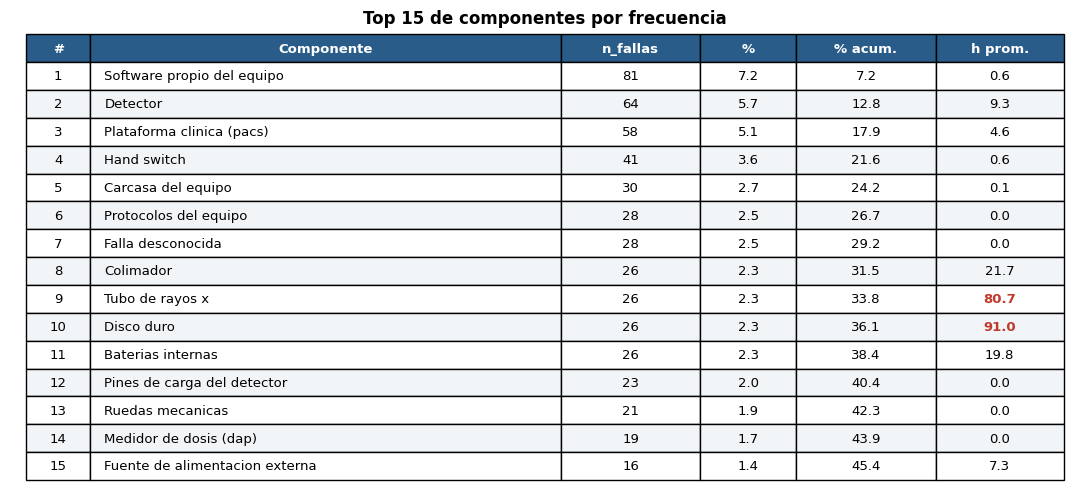

In [47]:
# ── CELDA D3-TABLA — TOP 15 DE COMPONENTES ──────────────────────
# Tabla de las 15 cabeceras por frecuencia. Lee de pareto_comp (Celda D3).
import matplotlib.pyplot as plt

TOP  = 15
AZUL = "#2A5C8A"; ROJO = "#C0392B"

pc   = pareto_comp.reset_index(drop=True).head(TOP)
cols = ["#", "Componente", "n_fallas", "%", "% acum.", "h prom."]
data = [[str(i+1), r["componente"].capitalize(), str(int(r["n_fallas"])),
         f"{r['pct']:.1f}", f"{r['pct_acumulado']:.1f}", f"{r['horas_prom']:.1f}"]
        for i, r in pc.iterrows()]

widths = [0.06, 0.44, 0.13, 0.09, 0.13, 0.12]   # 'Componente' es la más ancha

fig, ax = plt.subplots(figsize=(11, 5)); ax.axis("off")
t = ax.table(cellText=data, colLabels=cols, cellLoc="center", loc="center")
t.auto_set_font_size(False); t.set_fontsize(9.5); t.scale(1, 1.5)

for j, w in enumerate(widths):                  # anchos de columna
    for i in range(TOP+1):
        t[i, j].set_width(w)

for j in range(len(cols)):                      # encabezado
    t[0, j].set_facecolor(AZUL); t[0, j].set_text_props(color="white", weight="bold")

for i in range(1, TOP+1):
    cell = t[i, 1]; cell.set_text_props(ha="left"); cell.PAD = 0.03   # nombre a la izq.
    if i % 2 == 0:
        for j in range(len(cols)): t[i, j].set_facecolor("#F2F5F8")
    if float(data[i-1][5]) > 50:                # resalta downtime alto
        t[i, 5].set_text_props(color=ROJO, weight="bold")

ax.set_title("Top 15 de componentes por frecuencia", fontsize=12, pad=14, weight="bold")
plt.tight_layout()
plt.savefig("tabla_top15_componentes.png", dpi=150, bbox_inches="tight")
plt.show()

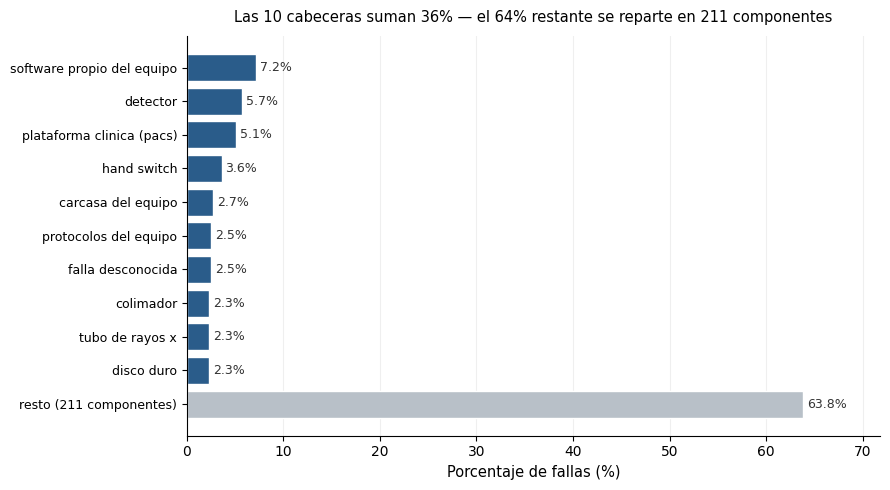

In [48]:
# ── CELDA D3-FIG-A — CABECERAS vs. RESTO (dispersión) ────────────
# Las 10 cabeceras con nombre + una barra "resto" que agrega los demás.
# La barra gris (la más larga) es el argumento visual de que las fallas
# están dispersas. Lee de pareto_comp (Celda D3). Reproducible.
import matplotlib.pyplot as plt
import numpy as np

TOP  = 10
AZUL = "#2A5C8A"; GRIS = "#B8C0C8"

pc        = pareto_comp.reset_index(drop=True)
top       = pc.head(TOP)
resto_pct = round(100 - top["pct"].sum(), 1)
resto_n   = len(pc) - TOP
top_cum   = round(top["pct"].sum(), 0)

etiquetas = list(top["componente"]) + [f"resto ({resto_n} componentes)"]
valores   = list(top["pct"])        + [resto_pct]
colores   = [AZUL]*TOP              + [GRIS]
y         = np.arange(len(etiquetas))[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y, valores, color=colores, edgecolor="white")
for yi, v in zip(y, valores):
    ax.text(v + 0.4, yi, f"{v:.1f}%", va="center", fontsize=9, color="#333")

ax.set_yticks(y); ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_xlabel("Porcentaje de fallas (%)", fontsize=10.5)
ax.set_xlim(0, resto_pct + 8)
ax.set_title(f"Las {TOP} cabeceras suman {top_cum:.0f}% — el {resto_pct:.0f}% restante "
             f"se reparte en {resto_n} componentes", fontsize=10.5, pad=10)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.grid(axis="x", alpha=0.2); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("componentes_cabeceras_resto.png", dpi=150, bbox_inches="tight")
plt.show()

El heatmap responde: "cuando este sistema falla en este tipo de equipo, ¿qué tan probable es que vuelva a fallar pronto?

Consolidado sistema × urgencia (recurrencia hacia adelante): (67, 6)
 tipo_corto                           sistema  Estable  Requiere acción  total  pct_recurrencia
        TAC            seguridad del paciente        0                1      1            100.0
     Fluoro                 falla desconocida        0                3      3            100.0
     Arco C                        accesorios        0                1      1            100.0
   RX Móvil                        accesorios        0                1      1            100.0
    RX Fijo                 falla desconocida        1                9     10             90.0
        TAC    procesamiento y almacenamiento        3               27     30             90.0
        TAC                           usuario        2               10     12             83.3
   RX Móvil                 falla desconocida        2               10     12             83.3
    RX Fijo              eléctrico del equipo        6             

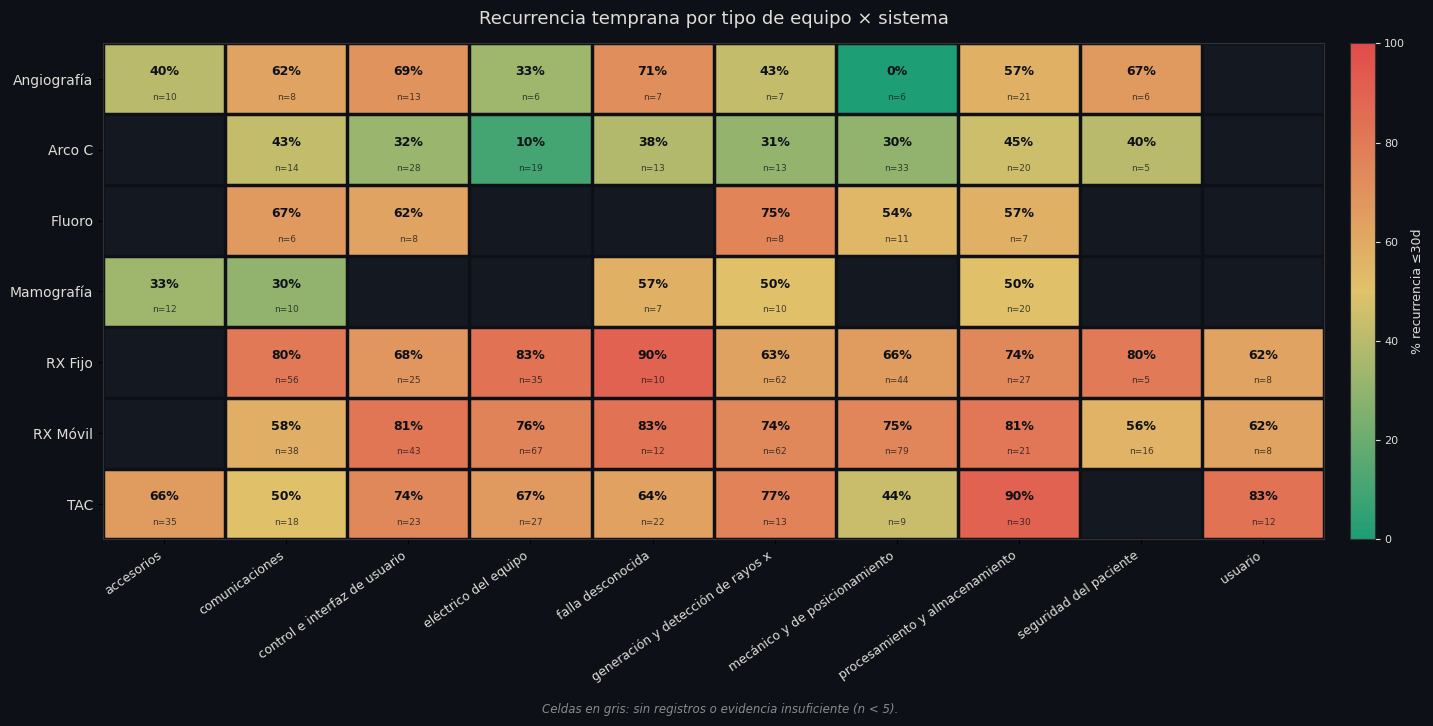

In [49]:
# ── CELDA D4 — CONSOLIDADO SISTEMA × URGENCIA + HEATMAP ───────
# Recurrencia temprana (hacia adelante, tbf_siguiente <= 30d) por tipo de
# equipo y sistema. Histórico puro (no usa el modelo). Conserva el
# PORCENTAJE de recurrencia como dato principal; la etiqueta binaria es
# solo apoyo. Incluye el heatmap tipo × sistema al final.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

base_u = DF_DESC.dropna(subset=["tbf_siguiente", COL_SISTEMA]).copy()
base_u["_urgencia"] = np.where(
    base_u["tbf_siguiente"] <= UMBRAL_ACCION_DIAS, "Requiere acción", "Estable"
)
consol = (
    base_u.groupby(["tipo_corto", COL_SISTEMA, "_urgencia"])
    .agg(n_casos=("id", "count"), horas_prom=("horas_reales", "mean"))
    .reset_index().rename(columns={COL_SISTEMA: "sistema", "_urgencia": "urgencia"})
)
pivot_u = consol.pivot_table(
    index=["tipo_corto", "sistema"], columns="urgencia",
    values="n_casos", aggfunc="sum", fill_value=0
).reset_index()
for col in ["Requiere acción", "Estable"]:
    if col not in pivot_u.columns:
        pivot_u[col] = 0
pivot_u["total"] = pivot_u["Requiere acción"] + pivot_u["Estable"]
pivot_u["pct_recurrencia"] = (pivot_u["Requiere acción"] / pivot_u["total"] * 100).round(1)
pivot_u = pivot_u.sort_values("pct_recurrencia", ascending=False)
print("Consolidado sistema × urgencia (recurrencia hacia adelante):", pivot_u.shape)
print(pivot_u.to_string(index=False))

# ── Heatmap tipo × sistema coloreado por % recurrencia ────────
# Solo se colorean celdas con evidencia suficiente (n >= N_MIN); las de
# menos casos y la categoría 'otro' se excluyen para no mostrar urgencia
# sin respaldo.
N_MIN = 5   # evidencia mínima por celda

pu  = pivot_u[pivot_u["sistema"] != "otro"].copy()
mat = pu.pivot_table(index="tipo_corto", columns="sistema", values="pct_recurrencia")
tot = pu.pivot_table(index="tipo_corto", columns="sistema", values="total")

mat = mat.where(tot >= N_MIN)
tot = tot.where(tot >= N_MIN)
mat = mat.dropna(axis=0, how="all").dropna(axis=1, how="all")
tot = tot.reindex(index=mat.index, columns=mat.columns)

cmap = LinearSegmentedColormap.from_list("recur", ["#1D9E75", "#E0C26A", "#E24B4A"])
cmap.set_bad("#141821")
M = np.ma.masked_invalid(mat.values)

fig, ax = plt.subplots(figsize=(1.15 * mat.shape[1] + 3, 0.72 * mat.shape[0] + 2))
fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#0d1117")
im = ax.imshow(M, cmap=cmap, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(mat.shape[1])); ax.set_yticks(range(mat.shape[0]))
ax.set_xticklabels(mat.columns, rotation=35, ha="right", color="#e0ddd6", fontsize=9)
ax.set_yticklabels(mat.index, color="#e0ddd6", fontsize=10)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if not np.isnan(v):
            n = tot.values[i, j]
            ax.text(j, i - 0.10, f"{v:.0f}%", ha="center", va="center",
                    color="#0d1117", fontsize=9, fontweight="bold")
            ax.text(j, i + 0.26, f"n={int(n)}", ha="center", va="center",
                    color="#0d1117", fontsize=6.5, alpha=0.75)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("% recurrencia ≤30d", color="#e0ddd6", fontsize=9)
cbar.ax.tick_params(colors="#e0ddd6", labelsize=8); cbar.outline.set_edgecolor("#333")

ax.set_title("Recurrencia temprana por tipo de equipo × sistema",
             color="#e0ddd6", fontsize=13, pad=14)
for s in ax.spines.values(): s.set_color("#333")
ax.set_xticks(np.arange(-.5, mat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, mat.shape[0], 1), minor=True)
ax.grid(which="minor", color="#0d1117", linewidth=2.5); ax.tick_params(which="minor", length=0)

fig.text(0.5, -0.02, f"Celdas en gris: sin registros o evidencia insuficiente (n < {N_MIN}).",
         ha="center", color="#8a8a8a", fontsize=8.5, style="italic")

plt.tight_layout()
plt.savefig("consolidado_urgencia_heatmap.png", dpi=200,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

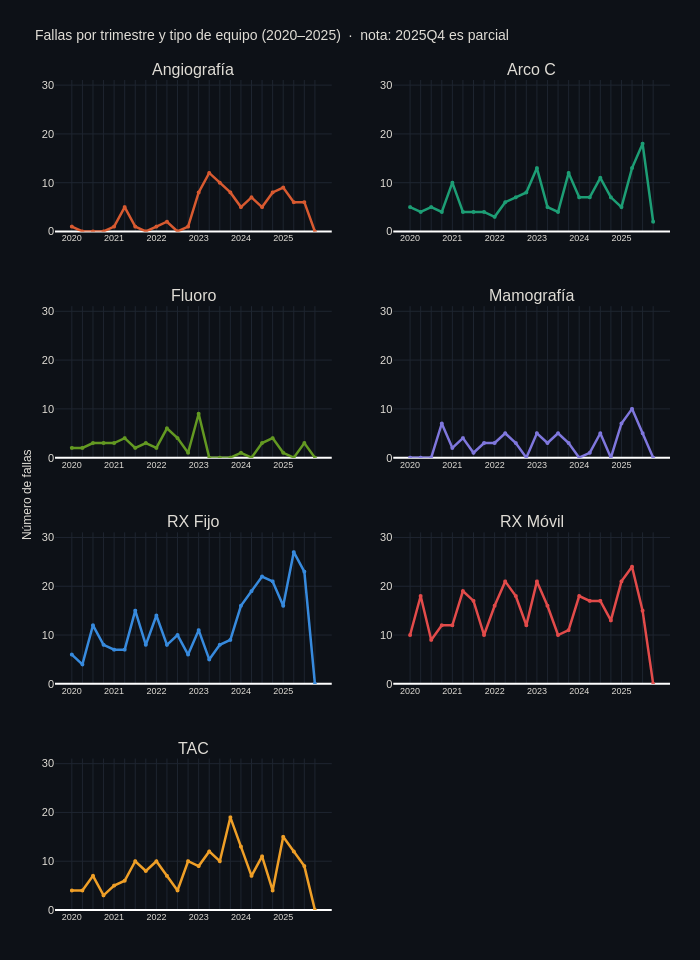

In [50]:
#---CELDA D5 ── SERIE TEMPORAL DE FALLAS POR TIPO — UN PANEL POR TIPO ────
# Fallas por trimestre, un panel por tipo, con ejes legibles.
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

dft = df.copy()
if "tipo_corto" not in dft.columns:
    dft["tipo_corto"] = dft["tipo_equipo"].map(NOMBRES_CORTOS)
dft["fecha_falla"] = pd.to_datetime(dft["fecha_falla"])
dft["trimestre"] = dft["fecha_falla"].dt.to_period("Q").astype(str)

serie = dft.groupby(["trimestre", "tipo_corto"]).size().reset_index(name="n_fallas")
trimestres = sorted(serie["trimestre"].unique())

# Detectar si el ultimo trimestre es parcial (los datos no llegan a su fin)
fmax = dft["fecha_falla"].max()
ult_trim_fin = pd.Period(trimestres[-1], "Q").end_time
ultimo_parcial = fmax < (ult_trim_fin - pd.Timedelta(days=15))

# Etiquetas X: solo una por anio (los Q1), resto vacio -> eje legible
ticktext = [t.replace("Q1", "") if t.endswith("Q1") else "" for t in trimestres]

ymax = serie["n_fallas"].max() * 1.15

COLORES_TIPO = {
    "TAC": "#EF9F27", "RX Fijo": "#378ADD", "RX Móvil": "#E24B4A",
    "Arco C": "#1D9E75", "Mamografía": "#7F77DD", "Angiografía": "#D85A30",
    "Fluoro": "#639922",
}

tipos = sorted(serie["tipo_corto"].dropna().unique())
cols = 2
rows = int(np.ceil(len(tipos) / cols))

fig = make_subplots(
    rows=rows, cols=cols, subplot_titles=tipos,
    vertical_spacing=0.09, horizontal_spacing=0.10,
)

for i, tipo in enumerate(tipos):
    r, c = i // cols + 1, i % cols + 1
    sub = (serie[serie["tipo_corto"] == tipo]
           .set_index("trimestre").reindex(trimestres, fill_value=0))
    color = COLORES_TIPO.get(tipo, "#888888")
    fig.add_trace(go.Scatter(
        x=trimestres, y=sub["n_fallas"], mode="lines+markers",
        line=dict(color=color, width=2.5, shape="linear"),
        marker=dict(size=4, color=color),
        showlegend=False,
        hovertemplate=f"{tipo}<br>%{{x}}: %{{y}} fallas<extra></extra>",
    ), row=r, col=c)
    fig.update_yaxes(range=[0, ymax], gridcolor="#1e2530",
                     dtick=10, row=r, col=c, title_text="")
    fig.update_xaxes(
        tickmode="array", tickvals=trimestres, ticktext=ticktext,
        gridcolor="#1e2530", row=r, col=c, tickfont=dict(size=9),
    )

titulo = "Fallas por trimestre y tipo de equipo (2020–2025)"
if ultimo_parcial:
    titulo += f"  ·  nota: {trimestres[-1]} es parcial"

fig.update_layout(
    title=dict(text=titulo, font=dict(size=14)),
    paper_bgcolor="#0d1117", plot_bgcolor="#0d1117",
    font=dict(color="#e0ddd6", family="Arial", size=11),
    height=rows * 240, margin=dict(t=80, b=50, l=55, r=30),
)
# Etiqueta Y global
fig.add_annotation(text="Número de fallas", textangle=-90,
                   xref="paper", yref="paper", x=-0.06, y=0.5,
                   showarrow=False, font=dict(size=12, color="#e0ddd6"))
fig.show()

# Bloque 6. Construcción de protocolos de mantenimiento

Con el fenómeno de recurrencia temprana caracterizado y su predictibilidad
demostrada por el Modelo A, este bloque traduce ese fenómeno en una base de
priorización. La matriz histórica no cruza predicciones individuales del
modelo: localiza la recurrencia observada (`tbf_siguiente <= 30 días`, el
mismo horizonte del Modelo A) en cada tipo de equipo y sistema, y la
complementa con frecuencia de fallas, componentes frecuentes y reemplazados,
horas de parada y calidad de la evidencia. El resultado orienta qué sistemas
y componentes considerar al construir las listas de chequeo, que se elaboran
posteriormente con los manuales, los criterios de aceptación y el criterio de
ingeniería clínica.

In [51]:
# ─────────────────────────────────────────────────────────────
# CELDA 25 — MATRIZ HISTÓRICA DE PRIORIZACIÓN (por tipo de equipo × sistema)
# ─────────────────────────────────────────────────────────────
# Producto descriptivo que prioriza QUÉ inspeccionar, con base en el
# historial de fallas. NO es el checklist operativo (ese se construye aparte
# con criterio de ingeniería clínica). Cada fila = un sistema de un tipo de
# equipo, con evidencia histórica para la toma de decisiones.
import pandas as pd
import numpy as np
from IPython.display import display, HTML

COL_SISTEMA        = "sistema_general"
UMBRAL_ACCION_DIAS = 30
INVALIDOS = ["sin dato", "no aplica", "nan", "NaN", "-", "", "n/a", "na", "none"]

# Reglas de evidencia (evaluador)
EV_ALTA_FALLAS, EV_ALTA_COMP, EV_ALTA_PCT = 30, 5, 25      # Alta: ≥30 y comp≥5 y ≥25%
EV_MEDIA_FALLAS = 10                                       # Media: 10-29 fallas
COMP_DOMIN_MIN_N, COMP_DOMIN_MIN_PCT = 5, 25               # componente dominante

if "tipo_corto" not in df_modelo.columns:
    df_modelo["tipo_corto"] = df_modelo["tipo_equipo"].map(NOMBRES_CORTOS)

# ══════════════════════════════════════════════════════════════
# 1. RECURRENCIA por sistema (hacia adelante, con porcentaje)
# ══════════════════════════════════════════════════════════════
base_r = df_modelo.dropna(subset=["tbf_siguiente", COL_SISTEMA]).copy()
base_r["_req"] = (base_r["tbf_siguiente"] <= UMBRAL_ACCION_DIAS).astype(int)

recurr = (
    base_r.groupby(["tipo_corto", COL_SISTEMA])
    .agg(n_recurr=("id", "count"), n_accion=("_req", "sum"))
    .reset_index()
)
recurr["pct_recurrencia"] = (recurr["n_accion"] / recurr["n_recurr"] * 100).round(1)
recurr = recurr.rename(columns={COL_SISTEMA: "sistema_general"})

# ══════════════════════════════════════════════════════════════
# 2. FRECUENCIA total y COBERTURA de horas por sistema
# ══════════════════════════════════════════════════════════════
freq = (
    df_modelo.groupby(["tipo_corto", COL_SISTEMA])
    .agg(n_fallas=("id", "count"),
         horas_validas=("horas_reales", lambda s: s.notna().sum()))
    .reset_index().rename(columns={COL_SISTEMA: "sistema_general"})
)
# horas promedio SOLO sobre registros con hora real (no imputa ceros)
horas = (
    df_modelo.dropna(subset=["horas_reales"])
    .groupby(["tipo_corto", COL_SISTEMA])["horas_reales"]
    .agg(horas_prom="mean", horas_max="max").reset_index()
    .rename(columns={COL_SISTEMA: "sistema_general"})
)
freq = freq.merge(horas, on=["tipo_corto", "sistema_general"], how="left")
freq["cobertura_horas"] = (freq["horas_validas"] / freq["n_fallas"] * 100).round(0)

# ══════════════════════════════════════════════════════════════
# 3. COMPONENTES top 1-3 (conteo por id, evidencia robusta)
# ══════════════════════════════════════════════════════════════
def top_n_componentes(df, col_comp, n=3):
    d = df.copy()
    d[col_comp] = d[col_comp].astype(str).str.strip()
    d = d[~d[col_comp].isin(INVALIDOS)]
    g = (d.groupby(["tipo_corto", COL_SISTEMA, col_comp])
           .agg(n=("id", "count")).reset_index())
    tot = g.groupby(["tipo_corto", COL_SISTEMA])["n"].transform("sum")
    g["pct"] = (g["n"] / tot * 100).round(0)
    g = g.sort_values(["tipo_corto", COL_SISTEMA, "n", col_comp],
                      ascending=[True, True, False, True])
    g["rank"] = g.groupby(["tipo_corto", COL_SISTEMA]).cumcount() + 1
    # Normaliza el nombre de la columna del componente a 'comp' (genérico)
    g = g.rename(columns={col_comp: "comp", COL_SISTEMA: "sistema_general"})
    return g[g["rank"] <= n]

comp_top = top_n_componentes(df_modelo, "componente", n=3)
cc_top   = top_n_componentes(df_modelo, "componente_cambiado", n=3)

def fmt_componentes(sub):
    """Texto 'componente (n, pct%)' para top 1-3; marca si NO hay dominante."""
    partes, dominante = [], False
    for _, r in sub.iterrows():
        partes.append(f"{r['comp']} ({int(r['n'])}, {int(r['pct'])}%)")
        if r["rank"] == 1 and r["n"] >= COMP_DOMIN_MIN_N and r["pct"] >= COMP_DOMIN_MIN_PCT:
            dominante = True
    return " · ".join(partes) if partes else "sin registros", dominante

# ══════════════════════════════════════════════════════════════
# 4. TASA DE CAMBIO y SOLUCIÓN histórica (antecedente, no instrucción)
# ══════════════════════════════════════════════════════════════
tasa_cambio = (
    df_modelo.groupby(["tipo_corto", COL_SISTEMA])["hubo_cambio_componente"]
    .mean().reset_index().rename(columns={COL_SISTEMA: "sistema_general",
        "hubo_cambio_componente": "tasa_cambio"})
)
solucion_hist = (
    df_modelo.groupby(["tipo_corto", COL_SISTEMA])["tipo_solucion"]
    .agg(lambda x: x.value_counts().idxmax() if len(x.dropna()) else "sin dato")
    .reset_index().rename(columns={COL_SISTEMA: "sistema_general",
        "tipo_solucion": "solucion_hist"})
)

# ══════════════════════════════════════════════════════════════
# 5. ENSAMBLAR la matriz + CALIDAD DE EVIDENCIA
# ══════════════════════════════════════════════════════════════
matriz = (freq
    .merge(recurr[["tipo_corto","sistema_general","pct_recurrencia","n_recurr"]],
           on=["tipo_corto","sistema_general"], how="left")
    .merge(tasa_cambio,   on=["tipo_corto","sistema_general"], how="left")
    .merge(solucion_hist, on=["tipo_corto","sistema_general"], how="left"))

def calidad_evidencia(n_fallas, comp_n1, comp_pct1):
    """Alta / Media / Baja según volumen y fuerza del patrón (evaluador)."""
    if n_fallas >= EV_ALTA_FALLAS and comp_n1 >= EV_ALTA_COMP and comp_pct1 >= EV_ALTA_PCT:
        return "Alta"
    if n_fallas >= EV_MEDIA_FALLAS:
        return "Media"
    return "Baja"

# Componentes por fila + dominancia + evidencia
comp_txt, cc_txt, evidencias, dominantes = {}, {}, {}, {}
for (t, s), sub in comp_top.groupby(["tipo_corto", "sistema_general"]):
    txt, dom = fmt_componentes(sub)
    comp_txt[(t, s)] = txt; dominantes[(t, s)] = dom
for (t, s), sub in cc_top.groupby(["tipo_corto", "sistema_general"]):
    cc_txt[(t, s)] = fmt_componentes(sub)[0]

def _comp1(t, s):
    sub = comp_top[(comp_top["tipo_corto"]==t) & (comp_top["sistema_general"]==s) &
                   (comp_top["rank"]==1)]
    if len(sub): return int(sub["n"].iloc[0]), int(sub["pct"].iloc[0])
    return 0, 0

filas = []
for _, r in matriz.iterrows():
    t, s = r["tipo_corto"], r["sistema_general"]
    n1, p1 = _comp1(t, s)
    filas.append({
        **r.to_dict(),
        "componentes_top":  comp_txt.get((t, s), "sin registros"),
        "cambiados_top":    cc_txt.get((t, s), "sin registros"),
        "evidencia":        calidad_evidencia(r["n_fallas"], n1, p1),
        "hay_dominante":    dominantes.get((t, s), False),
    })
matriz = pd.DataFrame(filas)
matriz["horas_prom"]  = matriz["horas_prom"].round(1)
matriz["horas_max"]   = matriz["horas_max"].round(0)
matriz["tasa_cambio"] = matriz["tasa_cambio"].fillna(0)
matriz["solucion_hist"] = matriz["solucion_hist"].fillna("sin dato")

# ── SCORE DE PRIORIDAD (dentro de cada tipo de equipo) ─────────
# Combina frecuencia (cuánto falla) y recurrencia (qué tan crónico),
# ponderado por la calidad de evidencia para no priorizar patrones con
# pocos datos. El ranking es POR TIPO de equipo: no se comparan tipos
# distintos entre sí (sus bases de fallo no son comparables).
PESO_FREQ, PESO_RECUR = 0.5, 0.5
FACTOR_EVIDENCIA = {"Alta": 1.0, "Media": 0.75, "Baja": 0.5}

matriz["freq_norm"]  = matriz.groupby("tipo_corto")["n_fallas"].transform(
    lambda x: x / x.max() if x.max() > 0 else 0)
matriz["recur_norm"] = matriz["pct_recurrencia"].fillna(0) / 100
matriz["score_prioridad"] = (
    (PESO_FREQ * matriz["freq_norm"] + PESO_RECUR * matriz["recur_norm"])
    * matriz["evidencia"].map(FACTOR_EVIDENCIA)
).round(3)
matriz["rank_prioridad"] = matriz.groupby("tipo_corto")["score_prioridad"].rank(
    ascending=False, method="min").astype(int)

matriz = matriz.sort_values(["tipo_corto", "score_prioridad"],
                            ascending=[True, False])

matriz.to_csv("/content/matriz_priorizacion.csv", index=False)
print("✅ matriz_priorizacion.csv guardada")
print(f"   {len(matriz)} filas (tipo × sistema) · {matriz['tipo_corto'].nunique()} equipos")
print(f"   Evidencia — Alta: {(matriz['evidencia']=='Alta').sum()}  "
      f"Media: {(matriz['evidencia']=='Media').sum()}  "
      f"Baja: {(matriz['evidencia']=='Baja').sum()}")

# ══════════════════════════════════════════════════════════════
# 6. RENDER HTML — matriz de priorización
# ══════════════════════════════════════════════════════════════
COLOR_EV = {"Alta":  {"bg":"#0f2419","bd":"#2DB083"},
            "Media": {"bg":"#241f08","bd":"#EFA83A"},
            "Baja":  {"bg":"#241111","bd":"#E8635F"}}

def bar_pct(pct, color, ancho=52):
    pct = 0 if pd.isna(pct) else pct
    w = min(ancho, int(pct * ancho / 100))
    return (f"<div style='display:flex;align-items:center;gap:6px'>"
            f"<div style='width:{ancho}px;background:#1e1e1e;border-radius:3px;height:5px'>"
            f"<div style='width:{w}px;background:{color};border-radius:3px;height:5px'></div></div>"
            f"<span style='color:#8a8a8a;font-size:10px;min-width:30px'>{pct:.0f}%</span></div>")

def celda_prioridad(rank, score):
    col = "#E8635F" if rank == 1 else ("#EFA83A" if rank <= 3 else "#6a6a6a")
    w = min(52, int(score * 52))
    barra = (f"<div style='width:52px;background:#1e1e1e;border-radius:3px;height:5px;margin-top:4px'>"
             f"<div style='width:{w}px;background:{col};border-radius:3px;height:5px'></div></div>")
    return (f"<div style='display:flex;flex-direction:column;align-items:flex-start;gap:1px'>"
            f"<span style='color:{col};font-weight:700;font-size:12px'>#{rank}</span>"
            f"<span style='color:#8a8a8a;font-size:9px'>{score:.2f}</span>{barra}</div>")

def celda_parada(horas_prom, cobertura):
    cob = 0 if pd.isna(cobertura) else cobertura
    if pd.isna(horas_prom) or cob == 0:
        return "<span style='color:#5a5a5a'>sin dato</span>"
    dot, htxt = ("#2DB083", "#2DB083") if cob >= 50 else ("#6a6a6a", "#8a8a8a")
    return (f"<div style='display:flex;align-items:center;gap:7px'>"
            f"<span style='width:7px;height:7px;border-radius:50%;background:{dot};"
            f"display:inline-block' title='Cobertura de horas: {cob:.0f}%'></span>"
            f"<span style='color:{htxt}'>{horas_prom:.1f} h</span>"
            f"<span style='color:#5a5a5a;font-size:9px'>{cob:.0f}%</span></div>")

estilos = ("<style>"
    ".mz{font-family:'Segoe UI',Arial,sans-serif;color:#e0ddd6;padding:8px 0}"
    ".mz-tipo{margin:26px 0 0;padding:13px 20px;border-radius:10px 10px 0 0;"
    "font-size:14px;font-weight:600;background:#161616;border-left:4px solid #555;"
    "display:flex;align-items:center;gap:12px}"
    ".mz-ev-sum{margin-left:auto;display:flex;gap:12px;font-size:11px}"
    ".mz-table{width:100%;border-collapse:separate;border-spacing:0;"
    "border:1px solid #242424;border-top:none;margin-bottom:6px;"
    "border-radius:0 0 10px 10px;overflow:hidden}"
    ".mz-table th{background:#121212;padding:9px 12px;font-size:9.5px;color:#6a6a6a;"
    "font-weight:600;text-align:left;border-bottom:1px solid #242424;"
    "text-transform:uppercase;letter-spacing:.06em;white-space:nowrap}"
    ".mz-table td{padding:10px 12px;font-size:11.5px;border-bottom:1px solid #171717;"
    "background:#0c0c0c;vertical-align:middle}"
    ".mz-table tr:last-child td{border-bottom:none}"
    ".mz-table tbody tr:hover td{background:#121212}"
    ".ev-pill{padding:3px 10px;border-radius:6px;font-size:9.5px;font-weight:700;"
    "letter-spacing:.05em;display:inline-flex;align-items:center;gap:6px}"
    ".ev-d{width:7px;height:7px;border-radius:50%;display:inline-block}"
    "</style>")

html = estilos + "<div class='mz'>"
for tipo in sorted(matriz["tipo_corto"].unique()):
    sub = matriz[matriz["tipo_corto"] == tipo]
    n_alta  = (sub["evidencia"]=="Alta").sum()
    n_media = (sub["evidencia"]=="Media").sum()
    n_baja  = (sub["evidencia"]=="Baja").sum()
    html += (f"<div class='mz-tipo'>📊 Matriz de priorización — <strong>{tipo}</strong>"
        f"<span style='font-weight:400;color:#5a5a5a;font-size:11px'>&nbsp;·&nbsp;"
        f"{int(sub['n_fallas'].sum())} fallas históricas</span>"
        f"<div class='mz-ev-sum'>"
        f"<span style='color:#2DB083'>● Alta {n_alta}</span>"
        f"<span style='color:#EFA83A'>● Media {n_media}</span>"
        f"<span style='color:#E8635F'>● Baja {n_baja}</span></div></div>"
        "<table class='mz-table'><thead><tr>"
        "<th>Prioridad</th><th>Sistema</th><th>Fallas</th><th>Recurrencia ≤30d</th>"
        "<th style='text-align:center'>%Cambio</th>"
        "<th>Componentes frecuentes (top 3)</th>"
        "<th>Componentes cambiados (top 3)</th>"
        "<th>Parada prom</th>"
        "<th>Solución correctiva histórica</th>"
        "<th style='text-align:center'>Evidencia</th>"
        "</tr></thead><tbody>")
    for _, row in sub.iterrows():
        ev = COLOR_EV[row["evidencia"]]
        comp = row["componentes_top"]
        if not row["hay_dominante"] and comp != "sin registros":
            comp += " <span style='color:#7a6a3a;font-size:9px'>(sin dominante)</span>"
        html += (f"<tr>"
            f"<td>{celda_prioridad(int(row['rank_prioridad']), row['score_prioridad'])}</td>"
            f"<td style='color:#e6e3db;font-weight:600'>{row['sistema_general']}</td>"
            f"<td style='color:#9a9a9a;text-align:center;font-weight:600'>{int(row['n_fallas'])}</td>"
            f"<td>{bar_pct(row['pct_recurrencia'], '#E8635F')}</td>"
            f"<td style='color:#9a9a9a;text-align:center'>{row['tasa_cambio']:.0%}</td>"
            f"<td style='color:#cfccc4;font-size:11px'>{comp}</td>"
            f"<td style='color:#a5a29a;font-size:11px'>{row['cambiados_top']}</td>"
            f"<td>{celda_parada(row['horas_prom'], row['cobertura_horas'])}</td>"
            f"<td style='color:#a5a29a;font-size:11px'>{row['solucion_hist']}</td>"
            f"<td style='text-align:center'>"
            f"<span class='ev-pill' style='background:{ev['bg']};color:{ev['bd']}'>"
            f"<span class='ev-d' style='background:{ev['bd']}'></span>{row['evidencia']}</span>"
            f"</td></tr>")
    html += "</tbody></table>"
html += ("<p style='color:#6a6a6a;font-size:10.5px;margin-top:14px;font-style:italic'>"
    "La solución correctiva histórica indica el antecedente más frecuente, NO la acción "
    "preventiva recomendada. La definición de actividades y criterios de aceptación "
    "corresponde al checklist operativo, elaborado con criterio de ingeniería clínica.</p>"
    "</div>")

with open("/content/matriz_priorizacion.html", "w", encoding="utf-8") as f:
    f.write(html)
display(HTML(html))

✅ matriz_priorizacion.csv guardada
   68 filas (tipo × sistema) · 7 equipos
   Evidencia — Alta: 9  Media: 29  Baja: 30


Prioridad,Sistema,Fallas,Recurrencia ≤30d,%Cambio,Componentes frecuentes (top 3),Componentes cambiados (top 3),Parada prom,Solución correctiva histórica,Evidencia
#10.59,procesamiento y almacenamiento,21,57%,29%,"pantalla vivo (5, 24%) · aplicacion 3d (2, 10%) · computadora de almacenamiento (2, 10%) (sin dominante)","cable de video (2, 33%) · adaptador de conexion de video (1, 17%) · cable de conexion cuarto de equipos - consola (1, 17%)",sin dato,cambio de componente,Media
#20.49,control e interfaz de usuario,13,69%,31%,"monitores (5, 38%) · entradas usb (2, 15%) · pantalla en vivo (2, 15%)","cable de video (2, 50%) · distribuidor de senal (1, 25%) · unidad de control mesa (1, 25%)",sin dato,cambio de componente,Media
#30.33,accesorios,10,40%,50%,"colchoneta camilla (2, 20%) · faldon plomado (2, 20%) · protector cableado (2, 20%) (sin dominante)","protector cableado (2, 40%) · colchoneta camilla (1, 20%) · convertidor de senal de video (1, 20%)",sin dato,cambio de componente,Media
#40.27,falla desconocida,8,71%,38%,"bloqueo componente (2, 25%) · error en protocolo (2, 25%) · mensaje de error (2, 25%) (sin dominante)","modulo de procesamiento (2, 67%) · modulo de comunicacion de imagen (1, 33%)",48.0 h12%,cambio de componente,Baja
#50.25,comunicaciones,8,62%,12%,"microfono (2, 25%) · plataforma clinica (pacs) (2, 25%) · conexion del equipo a la red (1, 12%) (sin dominante)","network switch (1, 100%)",528.0 h12%,asesoría,Baja
#60.25,usuario,5,75%,80%,"mal uso del equipo (5, 100%)","carcasa del equipo (2, 50%) · sensores de colision (1, 25%) · unidad de control mesa (1, 25%)",sin dato,cambio de componente,Baja
#70.24,seguridad del paciente,6,67%,33%,"carcasa del equipo (4, 67%) · sensores de colision (2, 33%) (sin dominante)","carcasa del equipo (2, 100%)",sin dato,ajuste mecánico básico,Baja
#80.20,generación y detección de rayos x,8,43%,25%,"sensores de temperatura (2, 25%) · artificio en la imagen (1, 12%) · camara dosimetrica (1, 12%) (sin dominante)","camara dosimetrica (1, 50%) · tarjeta de control del generador (1, 50%)",sin dato,ajuste funcionamiento de componente,Baja
#90.15,eléctrico del equipo,6,33%,83%,"gabinetes del equipo (3, 50%) · cableados del equipo (1, 17%) · chiller (1, 17%) (sin dominante)","ventiladores gabinetes (2, 40%) · cable de video (1, 20%) · chiller (1, 20%)",23.0 h17%,cambio de componente,Baja
#100.08,mecánico y de posicionamiento,7,0%,43%,"modulo de potencia de motor de movimiento (2, 29%) · encoders de la mesa (1, 14%) · motores de la mesa (1, 14%) (sin dominante)","modulo de potencia de motor de movimiento (2, 67%) · motores de la mesa (1, 33%)",191.0 h14%,ajuste funcionamiento de componente,Baja


**Registro incompleto de horas de parada.** La duración de las intervenciones se encuentra registrada en apenas el 10,4% de los eventos (125 de 1199), con una cobertura desigual entre tipos de equipo (desde 4% en angiografía hasta 23% en TAC). Por esta razón, las horas de parada no se emplean como criterio de priorización, sino únicamente como información complementaria. En la matriz, el promedio de horas se calcula exclusivamente sobre los registros con dato real y se acompaña de un indicador de cobertura que señala la proporción de casos que respaldan cada valor; los grupos sin registros válidos se muestran explícitamente como "sin dato" en lugar de imputar ceros que distorsionarían el promedio. Esta limitación proviene de la práctica de registro de la institución y acota el análisis de impacto por tiempo de parada, que se plantea como línea de mejora en la captura de datos.

In [52]:
# ─────────────────────────────────────────────────────────────
# CELDA FINAL — DESCARGA CONSOLIDADA DE ENTREGABLES
# ─────────────────────────────────────────────────────────────
# Reúne todos los artefactos del notebook (figuras PNG + matriz CSV/HTML)
# y los descarga en un paso. Correr al final, tras ejecutar todo.
import os, glob

DIR = "/content"

# Esperados (para avisar si falta alguno). NO incluye variables_modelo_b.png:
# ese es residuo del Modelo B y desaparece con su limpieza.
ESPERADOS = [
    "analisis_tbf.png", "resumen_por_tipo.png", "variables_modelo_a.png",
    "distribucion_target.png", "recurrencia_por_tipo.png",
    "features_numericas.png", "separabilidad_umap.png",
    "comparativa_4_modelos_a.png", "comparativa_4_modelos_clase_a.png",
    "validacion_temporal_comparativa.png", "desempeno_por_tipo.png",
    "sensibilidad_horizonte.png",
    "matriz_priorizacion.csv", "matriz_priorizacion.html",
]

generados = sorted(
    glob.glob(os.path.join(DIR, "*.png"))
    + glob.glob(os.path.join(DIR, "*.csv"))
    + glob.glob(os.path.join(DIR, "*.html"))
)
nombres = {os.path.basename(p) for p in generados}

print("="*60)
print(f"ENTREGABLES ENCONTRADOS: {len(generados)}")
print("="*60)
for p in generados:
    print(f"  ✅ {os.path.basename(p):<40} {os.path.getsize(p)/1024:7.1f} KB")

faltantes = [f for f in ESPERADOS if f not in nombres]
if faltantes:
    print("\n⚠️  No se generaron (¿celda sin correr o eliminada?):")
    for f in faltantes:
        print(f"     • {f}")

extra = nombres - set(ESPERADOS)
if extra:
    print("\nℹ️  Adicionales encontrados (revisar si deben entregarse):")
    for f in sorted(extra):
        print(f"     • {f}")

try:
    from google.colab import files
    print("\nIniciando descarga…")
    for p in generados:
        files.download(p)
except ImportError:
    print("\n(No es Colab: los archivos quedan en el directorio de trabajo.)")

ENTREGABLES ENCONTRADOS: 28
  ✅ analisis_tbf.png                           172.3 KB
  ✅ bivariado_target.png                        69.7 KB
  ✅ comparativa_4_modelos_a.png                 86.6 KB
  ✅ comparativa_4_modelos_clase_a.png           61.8 KB
  ✅ componentes_cabeceras_resto.png             76.9 KB
  ✅ consolidado_urgencia_heatmap.png           329.6 KB
  ✅ criticidad_Angiografía.png                 126.8 KB
  ✅ criticidad_Arco_C.png                      123.1 KB
  ✅ criticidad_Fluoro.png                      113.7 KB
  ✅ criticidad_Mamografía.png                  112.3 KB
  ✅ criticidad_RX_Fijo.png                     118.1 KB
  ✅ criticidad_RX_Móvil.png                    125.7 KB
  ✅ criticidad_TAC.png                         123.1 KB
  ✅ criticidad_global.png                      198.1 KB
  ✅ desempeno_por_tipo.png                      92.7 KB
  ✅ distribucion_target.png                    115.0 KB
  ✅ features_numericas.png                     156.8 KB
  ✅ matriz_confusion

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
# ── ANEXO COMPLETO — HTML directo a Drive ─────────────────────
from google.colab import drive
drive.mount('/content/drive')

ORIGEN  = "/content/drive/MyDrive/Colab Notebooks/Modelo_para_protocolo_predictivo_TG.ipynb"
DESTINO = "/content/drive/MyDrive"
HTML    = DESTINO + "/anexo_completo.html"

!jupyter nbconvert --to html "{ORIGEN}" --output-dir "{DESTINO}" --output anexo_completo

CSS = """
<style>
@page { size: A4 landscape; margin: 8mm; }
body, .jp-Notebook { font-size: 8.5pt !important; line-height: 1.25 !important; }

.jp-InputArea, .jp-Cell-inputArea, .jp-Cell-inputWrapper,
.jp-OutputArea, .jp-OutputArea-child, .jp-OutputArea-output,
.jp-Cell-outputArea, .jp-Cell-outputWrapper {
  display: block !important; width: auto !important;
  overflow: visible !important; max-height: none !important; height: auto !important; }
.jp-InputArea-editor, .jp-CodeMirrorEditor, .cm-editor, .cm-s-jupyter, .highlight {
  display: block !important; width: 100% !important;
  overflow: visible !important; max-height: none !important; height: auto !important; }
pre, code, .highlight pre, .jp-OutputArea-output pre, .jp-RenderedText pre {
  font-size: 7.5pt !important; line-height: 1.2 !important; margin: 2px 0 !important;
  white-space: pre-wrap !important; word-break: break-word !important;
  overflow: visible !important; max-height: none !important; }
.jp-CodeCell.jp-mod-outputsScrolled .jp-Cell-outputArea {
  max-height: none !important; overflow: visible !important; }
.jp-CodeCell.jp-mod-outputsScrolled .jp-Cell-outputArea::after { display: none !important; }
.jp-InputPrompt, .jp-OutputPrompt, .jp-Collapser { display: none !important; }
.jp-Cell, .jp-CodeCell { margin: 0 !important; padding: 3px 0 !important; }
.jp-InputArea-editor { border: 1px solid #d5d5d5 !important; padding: 4px 6px !important; }
img, .jp-RenderedImage img { max-width: 58% !important; height: auto !important; }
.jp-RenderedImage, table { break-inside: avoid; }
h1 { font-size: 14pt !important; }
h2 { font-size: 12pt !important; }
h3 { font-size: 10pt !important; }
</style>
</head>"""

html = open(HTML, encoding="utf-8").read()
open(HTML, "w", encoding="utf-8").write(html.replace("</head>", CSS, 1))
print("Listo en Drive:", HTML)

Mounted at /content/drive
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Modelo_para_protocolo_predictivo_TG.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 31 image(s).
[NbConvertApp] Writing 3837077 bytes to /content/drive/MyDrive/anexo_completo.html
Listo en Drive: /content/drive/MyDrive/anexo_completo.html
